# Imports

In [120]:
from pathlib import Path
import sys, os, json, re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cori_pipeline_utils_v13 import *

try:
    from scipy.stats import pearsonr, spearmanr, ttest_ind
except Exception:
    pearsonr = spearmanr = ttest_ind = None

try:
    from statsmodels.stats.multitest import multipletests
except Exception:
    multipletests = None

# Local helper modules (src/) - hold logic shared across the H1-H4 sections below.
_SRC_DIR = Path.cwd() / "src"
if str(_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(_SRC_DIR))

from utils import _safe_name, _pformat, _fmt_ci, _clean_id, _savefig
from cmr_helper import (
    CMR_FEATURE_FAMILIES, preprocess_cmr_features, preprocess_cmr_features_for_hcori,
    build_cmr_variable_inventory,
)
from clinical_covariates import (
    one_age_covars_htn_diabetes, one_age_covars, choose_adjustment_covars_for_h4_hcori,
    load_and_prepare_htn_db, merge_htn_diabetes_status,
)
from treatment_analysis import zscore_from_train_apply, fit_treatment_adjusted_cox
from performance import safe_horizon_performance
from rank_transition_plot import feature_rank_shift_bump_FIXED
from handcrafted_features import (
    set_logger as set_handcrafted_logger,
    _hc_log, _hc_section, _hc_pformat, _hc_fmt_ci, _hc_safe_name,
    load_handcrafted_features, merge_handcrafted, merge_handcrafted_cached_safe,
    train_handcrafted_survival_model, apply_handcrafted_bundle, hc_performance_row,
    plot_hc_km, plot_handcrafted_feature_transition_clean,
    load_cached_handcrafted_features, load_cached_handcrafted_features_exact,
)

In [11]:
# ============================================================
# CONFIGURATION — edit paths only here
# ============================================================
PROJECT_DIR = Path(r"./")  # <-- edit if needed
INPUT_DIR = Path(r"./data/")  # <-- edit if needed

MASTER_CSV = INPUT_DIR / "CORI_allcancer_8Jan_ALL_COLUMNS_with_retfound_features.csv"
NONCANCER_CSV = INPUT_DIR / "cohort2_noncancer_mace_with_retfound.csv"
TREATMENT_CSV = INPUT_DIR / "risk_score_df_final_shared_22April_2026.csv"
CHEMO_CSV = INPUT_DIR / "chemo_status.csv"
CARDIAC_MRI_CSV = INPUT_DIR / "cardiac_mri.csv"
if not CARDIAC_MRI_CSV.exists():
    CARDIAC_MRI_CSV = INPUT_DIR / "cardiac_mri(2).csv"
HTN_DB_CSV = INPUT_DIR / "final_df_HTN_DB_Status.csv"
HANDCRAFTED_FEATURE_DIR = Path(r"C:\Users\dragha4\OneDrive - Emory\Singh, Amritpal's files - Dharini_Raghavan\data\UKbiobank\UKbfeats")

# If running on Mac external drive, uncomment or let this fallback work.
if (not MASTER_CSV.exists()) and Path("/Volumes/T9-Krunal-2/CORI_Final/CORI_Manuscript_11May_master_outputs").exists():
    BASE_OUTDIR = Path("/Volumes/T9-Krunal-2/CORI_Final/CORI_Manuscript_11May_master_outputs")
    MASTER_CSV = BASE_OUTDIR / "CORI_allcancer_8Jan_ALL_COLUMNS_with_retfound_features.csv"
    NONCANCER_CSV = BASE_OUTDIR / "cohort2_noncancer_mace_with_retfound.csv"
    TREATMENT_CSV = BASE_OUTDIR / "risk_score_df_final_shared_22April_2026.csv"
    CHEMO_CSV = BASE_OUTDIR / "chemo_status.csv"
    CARDIAC_MRI_CSV = BASE_OUTDIR / "cardiac_mri.csv"
    if not CARDIAC_MRI_CSV.exists():
        CARDIAC_MRI_CSV = BASE_OUTDIR / "cardiac_mri(2).csv"
    HTN_DB_CSV = BASE_OUTDIR / "final_df_HTN_DB_Status.csv"

TRAIN_CENTER_PATTERNS = ["Birmingham", "Croydon"]
PRIMARY_HORIZON = 10
VARIANCE_THRESHOLD = 1e-8
MAX_FEATURE_MISSING = 0.50
UNIVARIATE_COX_PENALIZER = 0.01
CANDIDATE_FEATURE_COUNTS = (5, 10, 15, 20, 30, 50, 75, 100)

# 3/5/10-year MACE endpoint columns, reused by every horizon-performance table below.
HORIZON_COLS = {
    3: ("MACE_in_allCancer_3yr_censored_time", "MACE_in_allCancer_3yr_censored_status"),
    5: ("MACE_in_allCancer_5yr_censored_time", "MACE_in_allCancer_5yr_censored_status"),
    10: ("MACE_in_allCancer_10yr_censored_time", "MACE_in_allCancer_10yr_censored_status"),
}

# Shared H1 locked model folder. H2-H4 load CORI (and, where used, HCORI) from here and do NOT retrain them.
H1_LOCKED_OUTDIR = BASE_OUTDIR / "H1_CORI_LOCKED_MODEL_v13"
H1_CORI_BUNDLE = H1_LOCKED_OUTDIR / "models" / "CORI_locked_model_bundle.pkl"
H1_HCORI_OUTDIR = H1_LOCKED_OUTDIR / "handcrafted_HCORI"
H1_HCORI_BUNDLE = H1_HCORI_OUTDIR / "models" / "HCORI_locked_handcrafted_model_bundle.pkl"
H1_HCORI_CACHED_FEATURES = H1_HCORI_OUTDIR / "tables" / "H1_handcrafted_subject_level_features_cached.csv"

# Make sure cori_pipeline_utils_v13 can be imported from notebook folder or project folder
for p in [Path.cwd(), PROJECT_DIR, BASE_OUTDIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

print("BASE_OUTDIR:", BASE_OUTDIR)
print("MASTER_CSV:", MASTER_CSV)
print("NONCANCER_CSV:", NONCANCER_CSV)
print("TREATMENT_CSV:", TREATMENT_CSV)
print("CHEMO_CSV:", CHEMO_CSV)
print("CARDIAC_MRI_CSV:", CARDIAC_MRI_CSV)
print("H1_CORI_BUNDLE:", H1_CORI_BUNDLE)

# H1 output folder. H1 is also the canonical location for the once-only data
# load / cohort build immediately below, so its QC log doubles as the shared
# setup log.
OUTDIR, FIGDIR, TABLEDIR, MODELDIR, QCDIR = ensure_dirs(H1_LOCKED_OUTDIR)
logger = QCLogger(QCDIR / "H1_QC_log.txt")
logger.section("H1 initialized")
logger.log(f"Training centers: {TRAIN_CENTER_PATTERNS}")

BASE_OUTDIR: figures
MASTER_CSV: data/CORI_allcancer_8Jan_ALL_COLUMNS_with_retfound_features.csv
NONCANCER_CSV: data/cohort2_noncancer_mace_with_retfound.csv
TREATMENT_CSV: data/risk_score_df_final_shared_22April_2026.csv
CHEMO_CSV: data/chemo_status.csv
CARDIAC_MRI_CSV: data/cardiac_mri.csv
H1_CORI_BUNDLE: figures/H1_CORI_LOCKED_MODEL_v13/models/CORI_locked_model_bundle.pkl

H1 initialized
Training centers: ['Birmingham', 'Croydon']


## Color pallate

In [52]:

color_dict = {
    "dark_red1" : "#c23537",
    "dark_red2" : "#d95d5b",
    "light_red1" : "#ea999c",
    "light_red2" : "#f8c9c7",

    "light_blue1" : "#c1e3fa",
    "light_blue2" : "#91c3e8",
    "dark_blue1" : "#0067a8",
    "dark_blue2" : "#4c8fca",
    
    'light_green1' : "#56aa3e",
    'light_green2' : "#95c36e",
    'dark_green1' : "#1e662a",
    'dark_green2' : "#3c892d",
    

}

# Data loading

In [12]:
logger.section("Load master and build all-cancer cohort (shared by H1-H4)")
master = load_csv(MASTER_CSV, logger)
feature_cols = discover_feature_cols(master)
logger.log(f"Discovered RetFound features: {len(feature_cols)}; first={feature_cols[:3]}, last={feature_cols[-3:]}")

cancer_df, cohort_audit = build_allcancer_cohort(master, feature_cols, horizon=PRIMARY_HORIZON, logger=logger)
cohort_audit.to_csv(TABLEDIR / "H1_Table_00_cohort_audit.csv", index=False)
logger.df("Cancer cohort preview", cancer_df.head())

cancer_train, cancer_test, split_table, CENTER_COL = make_center_split(cancer_df, TRAIN_CENTER_PATTERNS, logger=logger)
split_table.to_csv(TABLEDIR / "H1_Table_01_center_split.csv", index=False)
logger.df("Center split table", split_table)

logger.section("Load non-cancer cohort (shared by H2)")
noncancer_raw = load_csv(NONCANCER_CSV, logger)
feature_cols_nc = [c for c in feature_cols if c in noncancer_raw.columns]
noncancer_df, noncancer_audit = build_noncancer_ready_cohort(noncancer_raw, feature_cols_nc, logger=logger)

nc_train, nc_test, nc_split_table, _ = make_center_split(noncancer_df, TRAIN_CENTER_PATTERNS, center_col=CENTER_COL, logger=logger)

logger.log(
    f"Shared cohorts ready: cancer development N={len(cancer_train)}, held-out N={len(cancer_test)}; "
    f"non-cancer development N={len(nc_train)}, held-out N={len(nc_test)}. "
    "H1-H4 below reuse these (via .copy()) instead of reloading/rebuilding them."
)


Load master and build all-cancer cohort (shared by H1-H4)
Loading CSV: data/CORI_allcancer_8Jan_ALL_COLUMNS_with_retfound_features.csv
Discovered RetFound features: 1024; first=['f0', 'f1', 'f2'], last=['f1021', 'f1022', 'f1023']

All-cancer cohort audit
                                                                                         step  rows  unique_eids  events
                                                                                   raw master  6989         6811     NaN
                                                                    baseline image_visit == 0  4598         4588     NaN
                                                                  allcancer_event_status == 1  4598         4588     NaN
valid endpoint: MACE_in_allCancer_10yr_censored_time / MACE_in_allCancer_10yr_censored_status  4598         4588   637.0
                                                            has at least one RetFound feature  4598         4588   637.0
                  

# Table One, group demographics

# H1 — pan-cancer CORI model train

Trains CORI once. H2-H4 must load this locked model without retraining.

In [13]:
cancer_train, cancer_test = cancer_train.copy(), cancer_test.copy()

logger.section("Train locked pan-cancer CORI model with robust feature selection")
cancer_train, cancer_test, cori_features, cori_rank, cori_bundle, cori_manifest, cori_cv = train_locked_model(
    cancer_train, cancer_test, feature_cols, prefix="CORI", outdir=TABLEDIR, modeldir=MODELDIR,
    logger=logger, variance_threshold=VARIANCE_THRESHOLD, max_missing=MAX_FEATURE_MISSING,
    candidate_ks=CANDIDATE_FEATURE_COUNTS, cox_rank_penalizer=UNIVARIATE_COX_PENALIZER
)

# Save development + held-out risk scores for downstream H2-H4 and manuscript
risk_cols = [c for c in ["eid", CENTER_COL, "time", "event", "CORI_score", "CORI_high_risk", "CORI_risk_tertile"] if c in cancer_train.columns]
risk_scores = pd.concat([
    cancer_train[risk_cols].assign(set="development"),
    cancer_test[risk_cols].assign(set="held_out")
], ignore_index=True)
risk_scores.to_csv(TABLEDIR / "H1_CORI_risk_scores_all_sets.csv", index=False)

logger.log("LOCKED CORI MODEL TRAINED AND SAVED. H2-H4 should load this model without retraining CORI.")
logger.log(f"Selected features ({len(cori_features)}): {cori_features[:20]}")


Train locked pan-cancer CORI model with robust feature selection

CORI: feature selection and locked model training
CORI: initial features=1024; retained after variance/missingness=1024
Univariate Cox ranking: 1024 usable features out of 1024

Internal development-only CV for feature count
  k  mean_c_index  sd_c_index                                               fold_c_indices                                        selection_rule
  5      0.635097    0.016745  [0.6266194254024493, 0.6201871121128848, 0.658484937477781] smallest k within 1 SD of best CV C-index; chosen_k=5
 10      0.633433    0.014055 [0.6262497111607487, 0.6209744650631426, 0.6530751039460871] smallest k within 1 SD of best CV C-index; chosen_k=5
 15      0.640954    0.015103 [0.6347223291997227, 0.6263778676629512, 0.6617617509312642] smallest k within 1 SD of best CV C-index; chosen_k=5
 20      0.639359    0.016118  [0.6341215435569592, 0.6227653070676507, 0.661189854243628] smallest k within 1 SD of best CV C-i


Primary pan-cancer CORI performance

Primary CORI performance
          cohort    N  Events  C_index  C_index_low  C_index_high        C_index_95CI          HR_95CI            label  HR_High_vs_Low  HR_CI_Low  HR_CI_High    LogRank_p
     Development 2152     300 0.639162     0.608687      0.670983 0.639 (0.609-0.671) 1.94 (1.54-2.43)      Development        1.935715   1.541476    2.430783 2.169057e-09
Held-out centers 2436     337 0.639822     0.610448      0.667017 0.640 (0.610-0.667) 2.22 (1.75-2.80) Held-out centers        2.215307   1.752070    2.801020 1.868830e-12
[shape=(2, 13)]


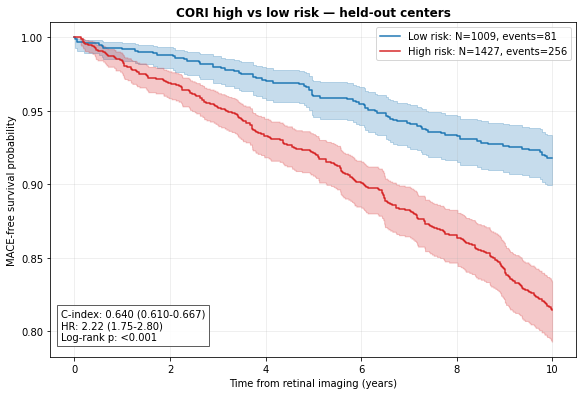

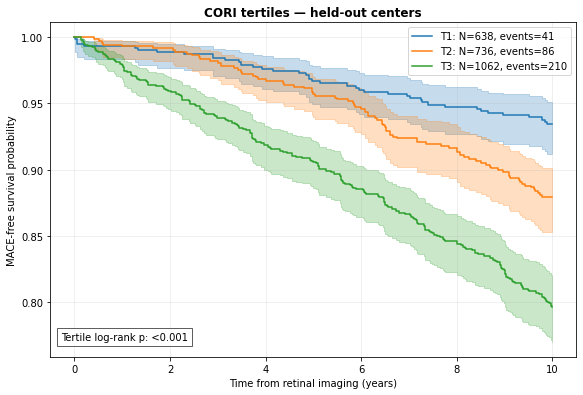


Horizon performance
          cohort  horizon_years    N  Events  C_index  C_index_low  C_index_high        C_index_95CI  HR_High_vs_Low  HR_CI_Low  HR_CI_High          HR_95CI    LogRank_p LogRank_p_fmt status
Held-out centers              3 2436      87 0.660417     0.604773      0.705432 0.660 (0.605-0.705)        1.904516   1.267906    2.860767 1.90 (1.27-2.86) 3.798537e-04        <0.001     ok
Held-out centers              5 2436     151 0.627369     0.585525      0.671685 0.627 (0.586-0.672)        1.799018   1.302711    2.484408 1.80 (1.30-2.48) 1.016104e-04        <0.001     ok
Held-out centers             10 2436     337 0.639822     0.610448      0.667017 0.640 (0.610-0.667)        2.215307   1.752070    2.801020 2.22 (1.75-2.80) 1.868830e-12        <0.001     ok
[shape=(3, 15)]


In [14]:
# ============================================================
# Primary pan-cancer CORI performance
# Robust version: avoids duplicate time/event columns in horizon analyses
# ============================================================

logger.section("Primary pan-cancer CORI performance")

# ----------------------------
# 1. Primary 10-year performance using canonical time/event
# ----------------------------
perf_rows = []

for cohort_label, df_ in [
    ("Development", cancer_train),
    ("Held-out centers", cancer_test),
]:
    d = df_.copy()
    d = d.loc[:, ~d.columns.duplicated()].copy()

    perf_rows.append(
        performance_row(
            d,
            cohort_label,
            "CORI_score",
            "CORI_high_risk",
        )
    )

perf = pd.DataFrame(perf_rows)
perf.to_csv(TABLEDIR / "H1_Table_02_primary_CORI_performance_10yr.csv", index=False)
logger.df("Primary CORI performance", perf)


# ----------------------------
# 2. Held-out Kaplan-Meier plots
# ----------------------------
plot_km_high_low(
    cancer_test.loc[:, ~cancer_test.columns.duplicated()].copy(),
    "CORI_score",
    "CORI_high_risk",
    "CORI high vs low risk — held-out centers",
    FIGDIR / "H1_Fig01_KM_CORI_high_low_heldout",
)

plot_km_tertiles(
    cancer_test.loc[:, ~cancer_test.columns.duplicated()].copy(),
    "CORI_score",
    "CORI_risk_tertile",
    "CORI tertiles — held-out centers",
    FIGDIR / "H1_Fig02_KM_CORI_tertiles_heldout",
)


# ----------------------------
# 3. 3/5/10-year horizon performance
# ----------------------------
hperf = safe_horizon_performance(
    cancer_test,
    score_col="CORI_score",
    group_col="CORI_high_risk",
    horizon_cols=HORIZON_COLS,
    label="Held-out centers",
    tabledir=TABLEDIR,
    prefix="H1_Table_03_CORI",
    n_boot=300,
)

logger.df("Horizon performance", hperf)

In [15]:
# ============================================================
# Merge final_df_HTN_DB_Status.csv into H1 train/test before clinical modeling
# ============================================================

logger.section("Merge final_df_HTN_DB_Status.csv into H1 train/test before clinical modeling")

htn_db_small = load_and_prepare_htn_db(HTN_DB_CSV)

cancer_train = merge_htn_diabetes_status(cancer_train, htn_db_small)
cancer_test = merge_htn_diabetes_status(cancer_test, htn_db_small)

print("Merged HTN/diabetes status:")
for name, df in [("cancer_train", cancer_train), ("cancer_test", cancer_test)]:
    print("\n", name, df.shape)
    for c in ["sex_clinical", "Diabetes_clinical", "HTN_clinical"]:
        if c in df.columns:
            print(c, "nonmissing=", df[c].notna().sum(), "unique=", df[c].nunique(dropna=True))


Merge final_df_HTN_DB_Status.csv into H1 train/test before clinical modeling
HTN/DB file columns:
['eid', 'Sex', 'Diabetes diagnosed by doctor', 'Age High BP diagnosed', 'Age diabetes diagnosed', 'HTN', 'Diabetes']
Merged HTN/diabetes status:

 cancer_train (2152, 1268)
sex_clinical nonmissing= 2152 unique= 2
Diabetes_clinical nonmissing= 2152 unique= 2
HTN_clinical nonmissing= 2152 unique= 2

 cancer_test (2436, 1268)
sex_clinical nonmissing= 2436 unique= 2
Diabetes_clinical nonmissing= 2436 unique= 2
HTN_clinical nonmissing= 2436 unique= 2


In [16]:
logger.section("Clinical benchmarking: one-age clinical model, CORI-only, clinical+CORI, stacked risk model")
clinical_covars, AGE_COL = one_age_covars(cancer_train, logger=logger)
fits, clinical_comp = train_clinical_and_stacked(cancer_train, cancer_test, "CORI_score", clinical_covars, logger, TABLEDIR)
clinical_comp.to_csv(TABLEDIR / "H1_Table_04_clinical_CORI_stacked_model_comparison.csv", index=False)

coef_tables = []
for name, fit in fits.items():
    try:
        s = fit["model"].summary.reset_index().rename(columns={"covariate": "predictor", "index": "predictor"})
        s.insert(0, "model", name)
        coef_tables.append(s)
    except Exception as e:
        logger.log(f"Could not extract coefficients for {name}: {e}")
if coef_tables:
    coefs = pd.concat(coef_tables, ignore_index=True)
    coefs.to_csv(TABLEDIR / "H1_Table_05_multivariable_model_coefficients.csv", index=False)
    logger.df("Model coefficients preview", coefs.head(30))


Clinical benchmarking: one-age clinical model, CORI-only, clinical+CORI, stacked risk model
One-age clinical policy: age variable=age_at_image_visit; covariates=['age_at_image_visit', 'sex_clinical', 'Diabetes_clinical', 'HTN_clinical', 'height']

Clinical/CORI/stacked model comparison
                            model  train_N  train_events  test_N  test_events  train_C_index  test_C_index                                                                        predictors  penalizer
                         Clinical     2152           300    2436          337       0.692373      0.708638         age_at_image_visit, sex_clinical, Diabetes_clinical, HTN_clinical, height       0.05
                             CORI     2152           300    2436          337       0.639162      0.639822                                                                            CORI_z       0.01
                  Clinical + CORI     2152           300    2436          337       0.699438      0.709131 age_a


Calibration, net benefit, and predicted-risk reclassification


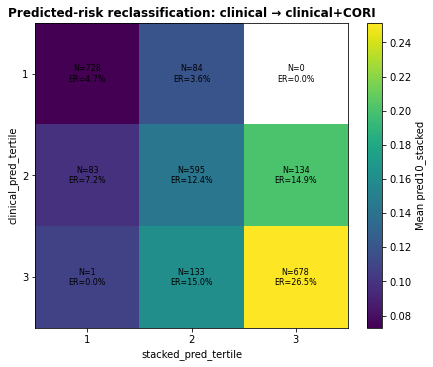

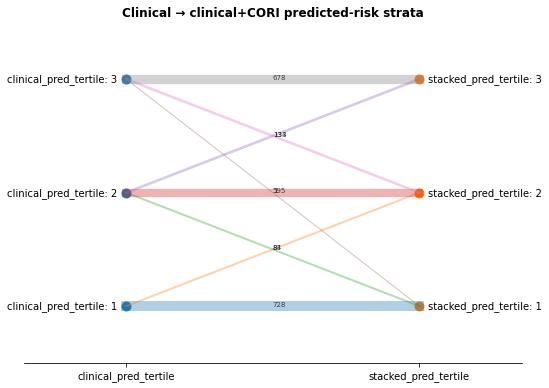


Calibration deciles
 decile   N  Events  Observed_rate  Mean_predicted_risk
      1 244       8       0.032787             0.052926
      2 244       9       0.036885             0.072683
      3 243      17       0.069959             0.091137
      4 244      17       0.069672             0.110725
      5 243      28       0.115226             0.132712
      6 244      33       0.135246             0.154045
      7 243      37       0.152263             0.176225
      8 244      37       0.151639             0.200549
      9 243      59       0.242798             0.233676
     10 244      92       0.377049             0.314122
[shape=(10, 5)]


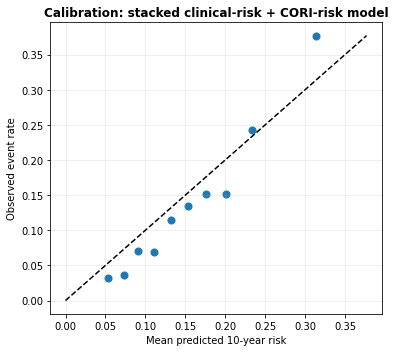

In [17]:
logger.section("Calibration, net benefit, and predicted-risk reclassification")
# Predicted risk reclassification uses model-predicted risk, not ground-truth risk.
clin_fit = fits["Clinical"]
stack_fit = fits["Stacked clinical-risk + CORI-risk"]

clin_te = clin_fit["test_matrix"].copy()
stack_te = stack_fit["test_matrix"].copy()
clin_te["pred10_clinical"] = predict_10yr(clin_fit["model"], clin_te)
stack_te["pred10_stacked"] = predict_10yr(stack_fit["model"], stack_te)

rec = pd.DataFrame({
    "event": stack_te["event"].values,
    "pred10_stacked": stack_te["pred10_stacked"].values,
    "pred10_clinical": pd.Series(clin_te["pred10_clinical"].values, index=clin_te.index).reindex(stack_te.index).values,
}).dropna()

rec["clinical_pred_tertile"] = risk_tertiles_from_pred(rec["pred10_clinical"])
rec["stacked_pred_tertile"] = risk_tertiles_from_pred(rec["pred10_stacked"])

cnt, er, mp = transition_heatmap(
    rec, "clinical_pred_tertile", "stacked_pred_tertile", "event", "pred10_stacked",
    "Predicted-risk reclassification: clinical → clinical+CORI",
    FIGDIR / "H1_Fig03_reclassification_matrix_predicted_risk"
)
cnt.to_csv(TABLEDIR / "H1_Table_06_reclassification_counts.csv")
er.to_csv(TABLEDIR / "H1_Table_07_reclassification_event_rates.csv")
mp.to_csv(TABLEDIR / "H1_Table_08_reclassification_mean_predicted_risk.csv")

alluvial_static(rec, "clinical_pred_tertile", "stacked_pred_tertile",
                "Clinical → clinical+CORI predicted-risk strata",
                FIGDIR / "H1_Fig04_alluvial_clinical_to_CORI")

# Calibration by predicted-risk decile for stacked model
rec["decile"] = pd.qcut(rec["pred10_stacked"].rank(method="first"), 10, labels=False) + 1
cal = rec.groupby("decile").agg(N=("event","size"), Events=("event","sum"), Observed_rate=("event","mean"), Mean_predicted_risk=("pred10_stacked","mean")).reset_index()
cal.to_csv(TABLEDIR / "H1_Table_09_stacked_model_calibration_deciles.csv", index=False)
logger.df("Calibration deciles", cal)
fig, ax = plt.subplots(figsize=(5.5,5))
ax.scatter(cal["Mean_predicted_risk"], cal["Observed_rate"], s=50)
ax.plot([0, max(cal["Mean_predicted_risk"].max(), cal["Observed_rate"].max())], [0, max(cal["Mean_predicted_risk"].max(), cal["Observed_rate"].max())], linestyle="--", color="black")
ax.set_xlabel("Mean predicted 10-year risk")
ax.set_ylabel("Observed event rate")
ax.set_title("Calibration: stacked clinical-risk + CORI-risk model", fontweight="bold")
ax.grid(alpha=0.25)
fig.tight_layout()
savefig(fig, FIGDIR / "H1_Fig05_calibration_stacked_deciles")
plt.show()


Cancer subtype/subgroup analysis using pan-cancer CORI model only — no subgroup retraining
Detected cancer subgroup columns: 40


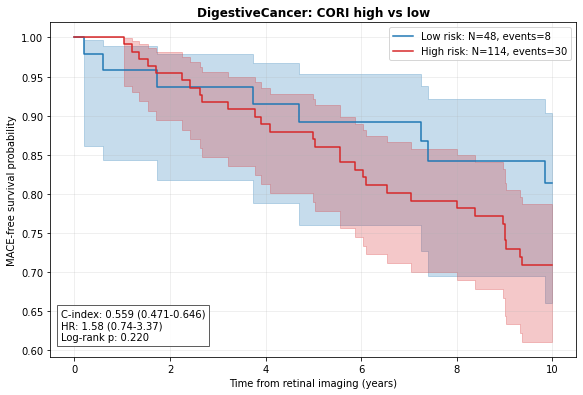

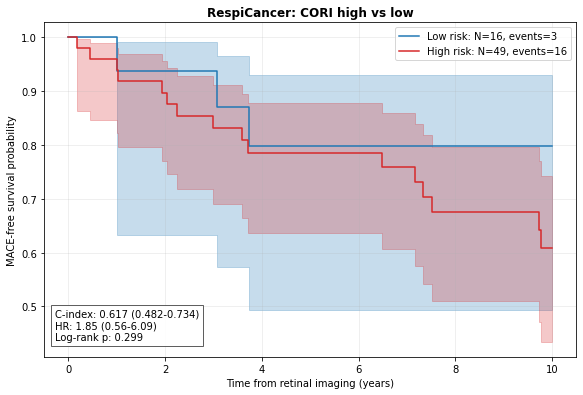

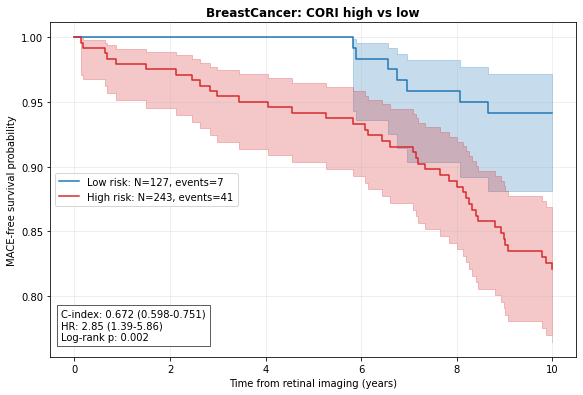

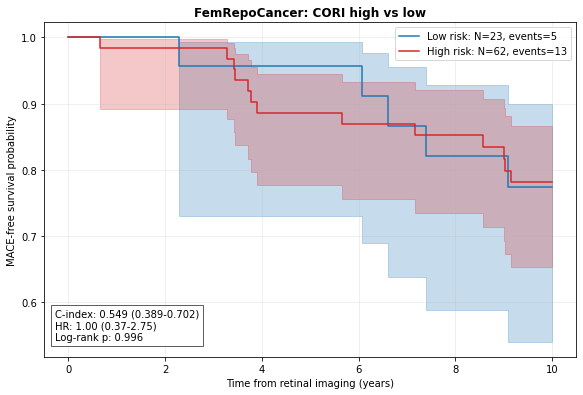

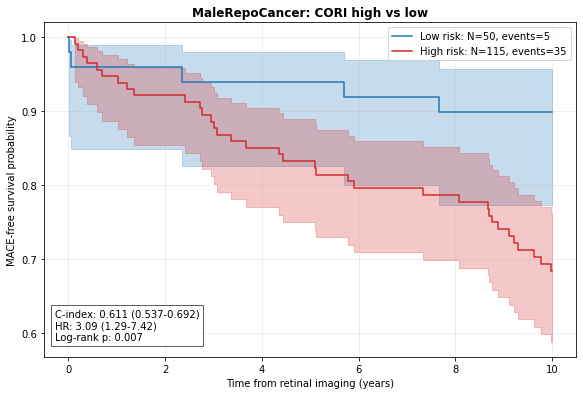

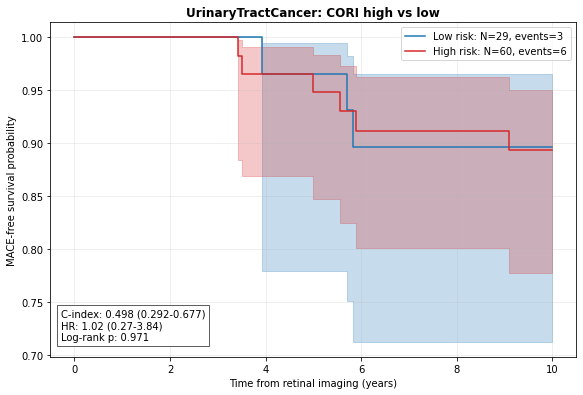

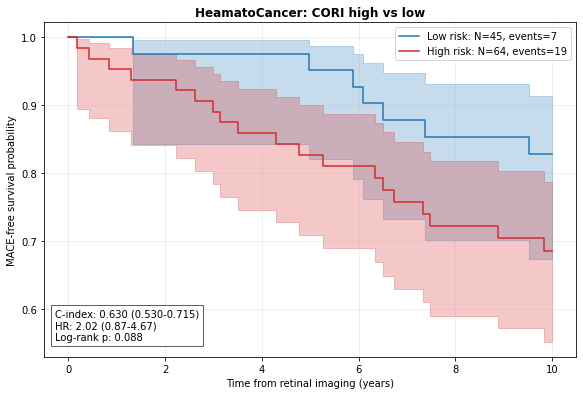

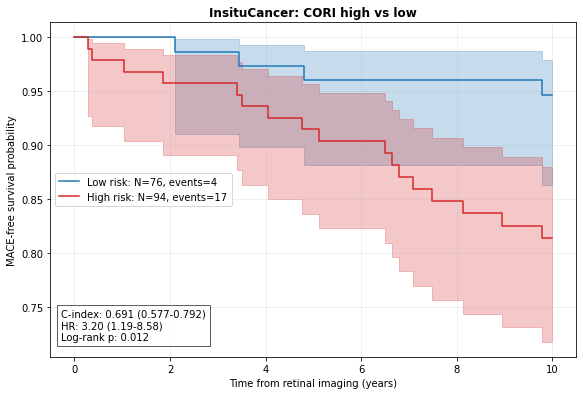

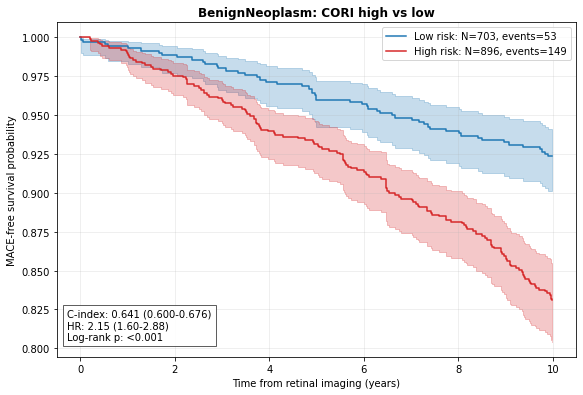

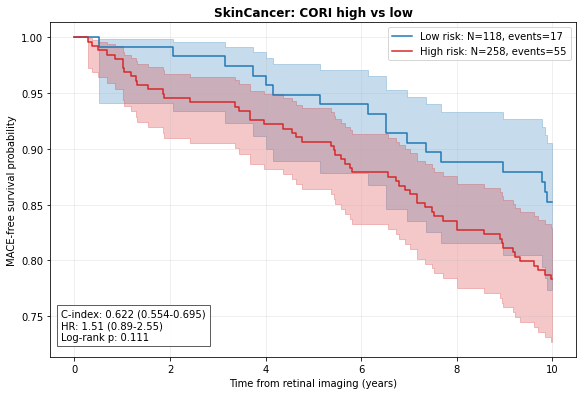

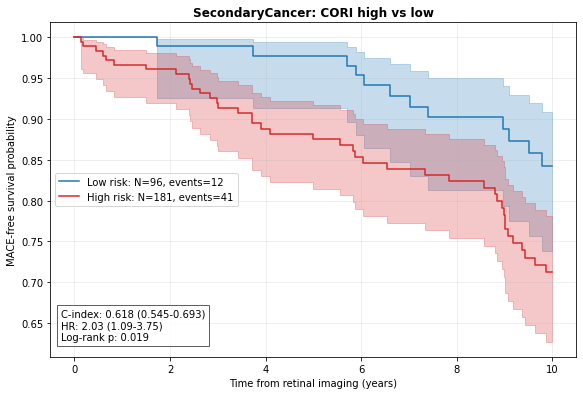

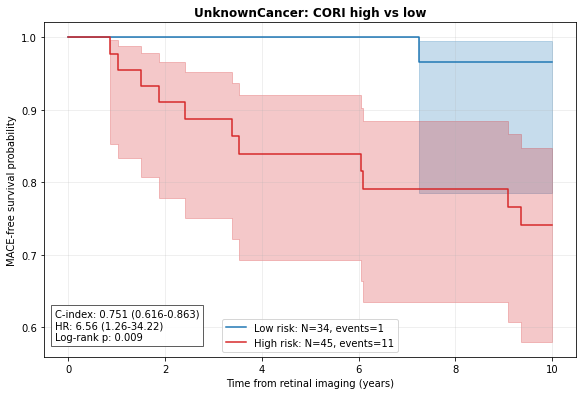

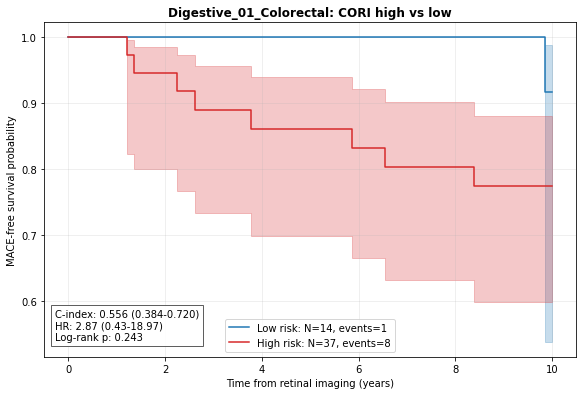

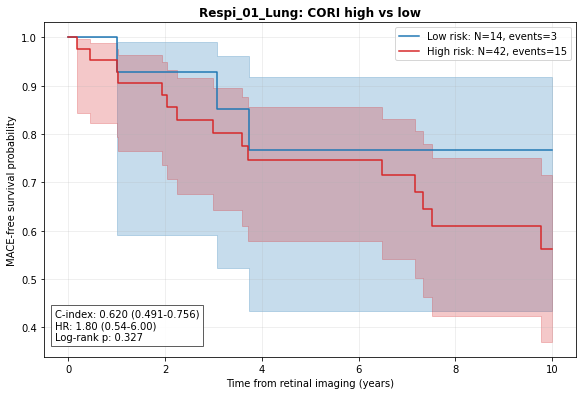

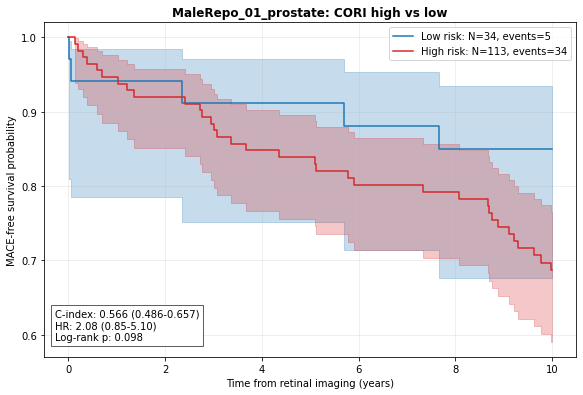

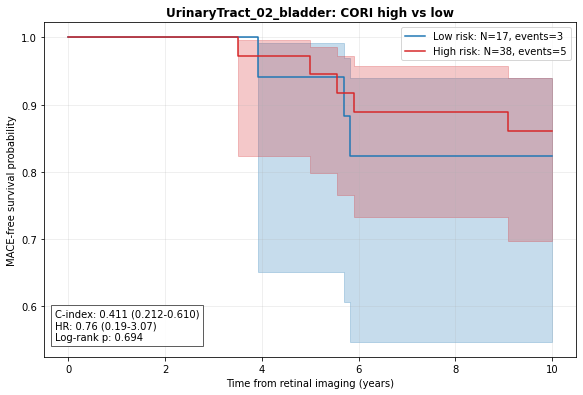

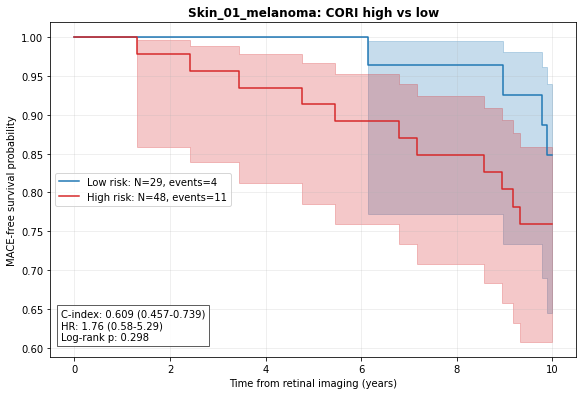

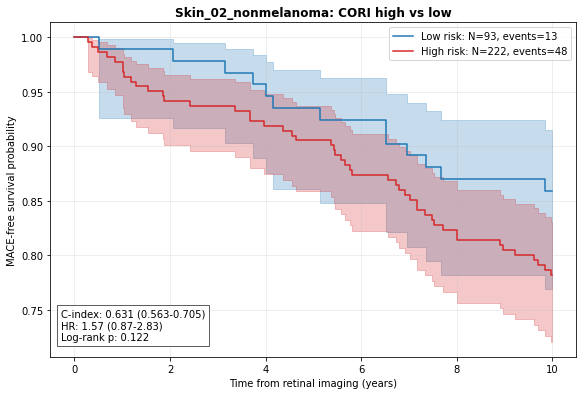

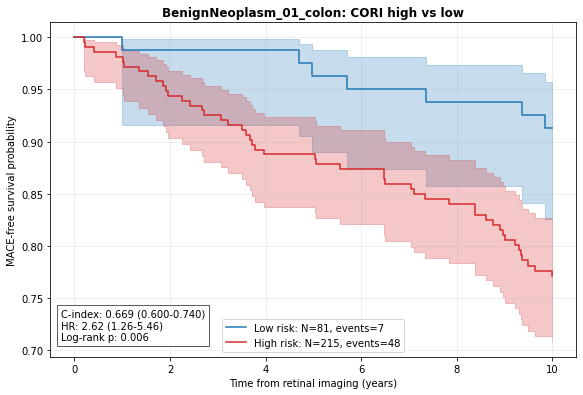

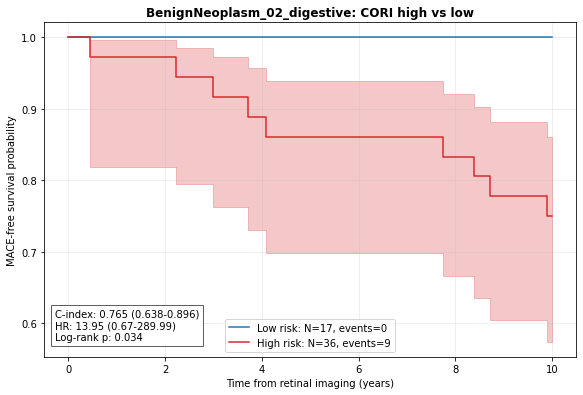

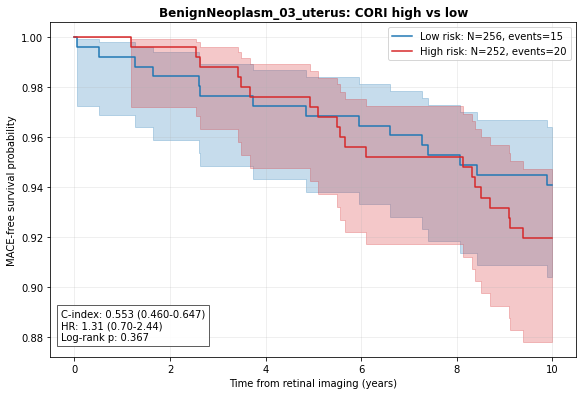

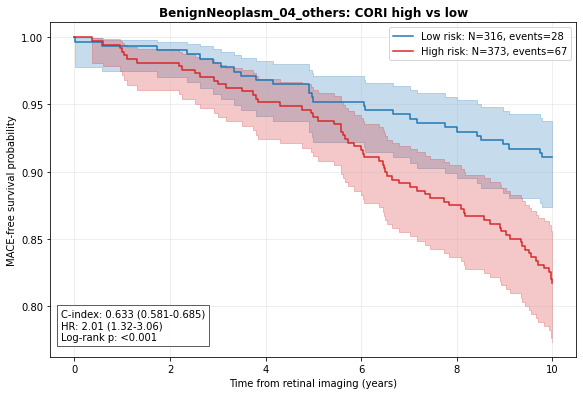

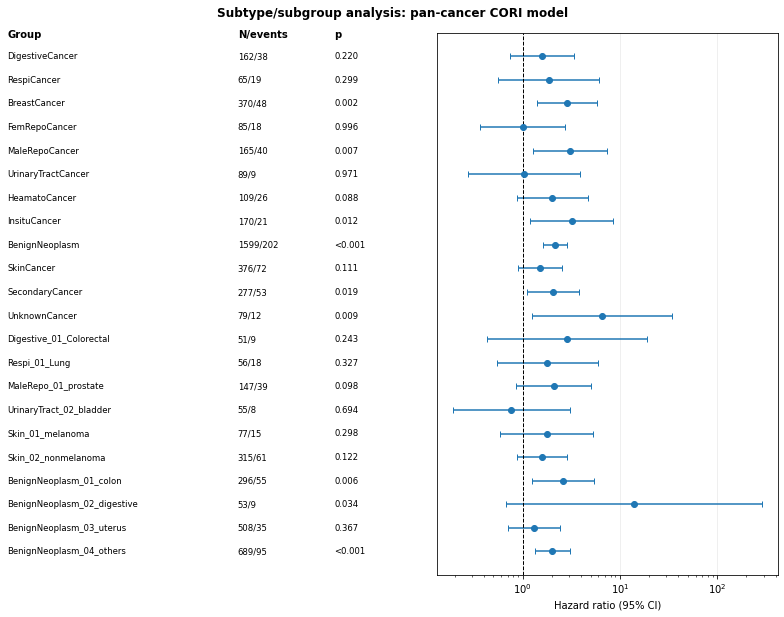


Subgroup performance
               subgroup                          column    N  Events                  cohort  C_index  C_index_low  C_index_high        C_index_95CI           HR_95CI                   label  HR_High_vs_Low  HR_CI_Low  HR_CI_High    LogRank_p       status
        DigestiveCancer         DigestiveCancer_present  162      38         DigestiveCancer 0.559336     0.470681      0.645555 0.559 (0.471-0.646)  1.58 (0.74-3.37)         DigestiveCancer        1.583354   0.744419    3.367744 2.195122e-01   analyzable
            RespiCancer             RespiCancer_present   65      19             RespiCancer 0.616648     0.482079      0.733881 0.617 (0.482-0.734)  1.85 (0.56-6.09)             RespiCancer        1.847179   0.559856    6.094545 2.987492e-01   analyzable
           BreastCancer            BreastCancer_present  370      48            BreastCancer 0.671502     0.597547      0.751446 0.672 (0.598-0.751)  2.85 (1.39-5.86)            BreastCancer        2.853497   1

In [18]:
logger.section("Cancer subtype/subgroup analysis using pan-cancer CORI model only — no subgroup retraining")
subgroup_cols = cancer_subtype_columns(cancer_test)
logger.log(f"Detected cancer subgroup columns: {len(subgroup_cols)}")
subgroup_perf = subgroup_analysis(
    cancer_test, subgroup_cols, "CORI_score", "CORI_high_risk",
    FIGDIR, TABLEDIR, min_n=50, min_events=5, prefix="H1_subgroup_pan_cancer_CORI"
)
logger.df("Subgroup performance", subgroup_perf)

# Explicit interpretation reminder saved to QC
logger.log("Subgroup analyses use the locked pan-cancer CORI model. Cases/events are MACE events within each cancer subtype; non-events are censored/event-free participants within the same subtype.")

In [19]:
logger.section("Final H1 manifest")
manifest = {
    "notebook": "H1",
    "purpose": "Train locked pan-cancer CORI model once; downstream H2-H4 should load this model without retraining CORI.",
    "center_col": CENTER_COL,
    "train_centers_requested": TRAIN_CENTER_PATTERNS,
    "development_N": len(cancer_train),
    "development_events": int(cancer_train.event.sum()),
    "heldout_N": len(cancer_test),
    "heldout_events": int(cancer_test.event.sum()),
    "feature_selection": cori_manifest,
    "clinical_covariates": clinical_covars,
    "age_variable": AGE_COL,
    "locked_model_bundle": str(MODELDIR / "CORI_locked_model_bundle.pkl"),
}
(OUTDIR / "H1_output_manifest.json").write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
logger.log(json.dumps(manifest, indent=2, default=str))


Final H1 manifest
{
  "notebook": "H1",
  "purpose": "Train locked pan-cancer CORI model once; downstream H2-H4 should load this model without retraining CORI.",
  "center_col": "UK Biobank assessment centre | Instance 0",
  "train_centers_requested": [
    "Birmingham",
    "Croydon"
  ],
  "development_N": 2152,
  "development_events": 300,
  "heldout_N": 2436,
  "heldout_events": 337,
  "feature_selection": {
    "prefix": "CORI",
    "n_initial_features": 1024,
    "n_after_variance_filter": 1024,
    "n_selected_features": 5,
    "selected_features": [
      "f260",
      "f98",
      "f989",
      "f728",
      "f319"
    ],
    "top5_features": [
      "f260",
      "f98",
      "f989",
      "f728",
      "f319"
    ],
    "top10_features": [
      "f260",
      "f98",
      "f989",
      "f728",
      "f319"
    ],
    "variance_threshold": 1e-08,
    "max_missing": 0.5,
    "cox_rank_penalizer": 0.01,
    "candidate_ks": [
      5,
      10,
      15,
      20,
      30,
   

In [20]:
# AUTO-HANDCRAFTED-FINAL-v3 — common handcrafted feature utilities
# This cell is self-contained and does not modify the RetFound CORI model.

set_handcrafted_logger(logger)

HANDCRAFTED_H1_OUTDIR = H1_HCORI_OUTDIR
HANDCRAFTED_H1_MODELDIR = HANDCRAFTED_H1_OUTDIR / "models"
HANDCRAFTED_H1_TABLEDIR = HANDCRAFTED_H1_OUTDIR / "tables"
HANDCRAFTED_H1_FIGDIR = HANDCRAFTED_H1_OUTDIR / "figures"
for _p in [HANDCRAFTED_H1_OUTDIR, HANDCRAFTED_H1_MODELDIR, HANDCRAFTED_H1_TABLEDIR, HANDCRAFTED_H1_FIGDIR]:
    _p.mkdir(parents=True, exist_ok=True)


H1 handcrafted retinal comparator: train cancer-trained HCORI
Loading cached handcrafted features from CSV: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/tables/H1_handcrafted_subject_level_features_cached.csv
Handcrafted feature table shape: (54060, 456)
Elapsed after feature loading: 0.09 min


,set,N,with_any_HC,n_HC_columns,id_col
0,development,2152,2003,453,eid
1,held_out,2436,2250,453,eid


Merge complete in 0.01 min

Fast handcrafted feature prefilter before Cox ranking
HC columns before prefilter: 453
HC columns after prefilter: 453
Using top 75 handcrafted features for Cox ranking/modeling out of 453 prefiltered features.
Fast HC train shape: (2152, 1345)
Fast HC test shape : (2436, 1345)
HCORI: candidate handcrafted columns after filters: 75
HCORI model training complete in 0.08 min


,cohort,model,N,Events,C_index,HR_high_vs_low,HR_low,HR_high,HR_95CI,p,p_fmt
0,Development,HCORI,2152,300,0.585703,1.384685,1.107664,1.730988,1.38 (1.11-1.73),4.265961e-03,0.004
1,Held-out centers,HCORI,2436,337,0.558060,1.217720,0.988597,1.499945,1.22 (0.99-1.50),6.400667e-02,0.064
2,Held-out centers,CORI,2436,337,0.639822,2.215307,1.752070,2.801020,2.22 (1.75-2.80),3.026253e-11,<0.001


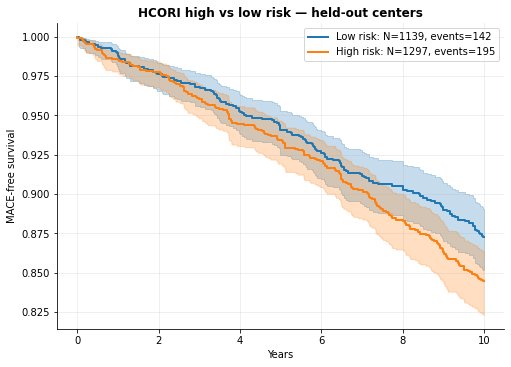

Saved locked HCORI bundle to: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/models/HCORI_locked_handcrafted_model_bundle.pkl
Total H1 handcrafted cell runtime: 0.20 min


In [21]:
# ============================================================
# AUTO-HANDCRAFTED-FINAL-v3 — H1 handcrafted HCORI comparator
# FAST / CACHE-SAFE VERSION
# ============================================================

import time

_hc_section("H1 handcrafted retinal comparator: train cancer-trained HCORI")

# ----------------------------
# Speed controls
# ----------------------------
REBUILD_HANDCRAFTED_CACHE = False

# Set this to a reasonable number first.
# You can increase to 100/200 later if the first run works.
MAX_HANDCRAFTED_FEATURES_FOR_RANKING = 75

# Basic filters before Cox ranking
HC_MAX_MISSING = 0.50
HC_MIN_VARIANCE = 1e-8
HC_MIN_NONMISSING_TRAIN = 50

cache_parquet = HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_subject_level_features_cached.parquet"
cache_csv = HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_subject_level_features_cached.csv"

t0 = time.time()

# ----------------------------
# 1. Load handcrafted features once, then cache
# ----------------------------
if (not REBUILD_HANDCRAFTED_CACHE) and cache_parquet.exists():
    _hc_log(f"Loading cached handcrafted features from parquet: {cache_parquet}")
    hc_features = pd.read_parquet(cache_parquet)
    hc_errors = pd.DataFrame()

elif (not REBUILD_HANDCRAFTED_CACHE) and cache_csv.exists():
    _hc_log(f"Loading cached handcrafted features from CSV: {cache_csv}")
    hc_features = pd.read_csv(cache_csv, low_memory=False)
    hc_errors = pd.DataFrame()

else:
    _hc_log(f"Reading raw handcrafted CSV files from: {HANDCRAFTED_FEATURE_DIR}")
    _hc_log("This can be slow the first time. The result will be cached.")

    t_load = time.time()
    hc_features, hc_errors = load_handcrafted_features(
        HANDCRAFTED_FEATURE_DIR,
        id_col_name="eid",
    )
    _hc_log(f"Raw handcrafted load complete in {(time.time() - t_load)/60:.2f} min")

    # Save cache
    try:
        hc_features.to_parquet(cache_parquet, index=False)
        _hc_log(f"Saved parquet cache: {cache_parquet}")
    except Exception as e:
        _hc_log(f"Could not save parquet cache: {e}")

    hc_features.to_csv(cache_csv, index=False)
    _hc_log(f"Saved CSV cache: {cache_csv}")

    if len(hc_errors):
        hc_errors.to_csv(
            HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_feature_read_errors.csv",
            index=False,
        )

_hc_log(f"Handcrafted feature table shape: {hc_features.shape}")
_hc_log(f"Elapsed after feature loading: {(time.time() - t0)/60:.2f} min")


# ----------------------------
# 2. Merge with H1 train/test
# ----------------------------
t_merge = time.time()

cancer_train_hc, hc_id_train = merge_handcrafted(cancer_train, hc_features)
cancer_test_hc, hc_id_test = merge_handcrafted(cancer_test, hc_features)

hc_cols_all = [c for c in cancer_train_hc.columns if str(c).startswith("HC_")]

merge_qc = pd.DataFrame([
    {
        "set": "development",
        "N": len(cancer_train_hc),
        "with_any_HC": int(cancer_train_hc[hc_cols_all].notna().any(axis=1).sum()) if hc_cols_all else 0,
        "n_HC_columns": len(hc_cols_all),
        "id_col": hc_id_train,
    },
    {
        "set": "held_out",
        "N": len(cancer_test_hc),
        "with_any_HC": int(cancer_test_hc[hc_cols_all].notna().any(axis=1).sum()) if hc_cols_all else 0,
        "n_HC_columns": len(hc_cols_all),
        "id_col": hc_id_test,
    },
])

merge_qc.to_csv(
    HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_merge_QC.csv",
    index=False,
)
display(merge_qc)

_hc_log(f"Merge complete in {(time.time() - t_merge)/60:.2f} min")


# ----------------------------
# 3. Fast prefilter handcrafted columns before Cox ranking
# ----------------------------
_hc_section("Fast handcrafted feature prefilter before Cox ranking")

prefilter_rows = []
candidate_hc_cols = []

for c in hc_cols_all:
    x = pd.to_numeric(cancer_train_hc[c], errors="coerce")
    n_nonmiss = int(x.notna().sum())
    miss = float(x.isna().mean())
    var = float(x.var(skipna=True)) if n_nonmiss > 1 else np.nan

    keep = (
        n_nonmiss >= HC_MIN_NONMISSING_TRAIN
        and miss <= HC_MAX_MISSING
        and np.isfinite(var)
        and var > HC_MIN_VARIANCE
    )

    prefilter_rows.append({
        "feature": c,
        "n_nonmissing_train": n_nonmiss,
        "missing_fraction_train": miss,
        "variance_train": var,
        "status": "keep" if keep else "drop",
    })

    if keep:
        candidate_hc_cols.append(c)

prefilter_df = pd.DataFrame(prefilter_rows)
prefilter_df.to_csv(
    HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_prefilter_QC.csv",
    index=False,
)

_hc_log(f"HC columns before prefilter: {len(hc_cols_all)}")
_hc_log(f"HC columns after prefilter: {len(candidate_hc_cols)}")

# Optional fast ranking by simple univariate event/non-event mean difference
# to avoid Cox-fitting thousands of variables.
rank_rows = []
for c in candidate_hc_cols:
    x = pd.to_numeric(cancer_train_hc[c], errors="coerce")
    e = pd.to_numeric(cancer_train_hc["event"], errors="coerce").fillna(0).astype(int)

    x0 = x[e.eq(0)].dropna()
    x1 = x[e.eq(1)].dropna()

    if len(x0) < 20 or len(x1) < 5:
        score = np.nan
    else:
        pooled = np.sqrt((x0.var(ddof=1) + x1.var(ddof=1)) / 2)
        score = abs((x1.mean() - x0.mean()) / pooled) if pooled and np.isfinite(pooled) else np.nan

    rank_rows.append({"feature": c, "fast_abs_standardized_difference": score})

fast_rank = (
    pd.DataFrame(rank_rows)
    .sort_values("fast_abs_standardized_difference", ascending=False, na_position="last")
)

fast_rank.to_csv(
    HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_fast_univariate_prefilter_rank.csv",
    index=False,
)

selected_for_modeling = (
    fast_rank["feature"]
    .dropna()
    .head(MAX_HANDCRAFTED_FEATURES_FOR_RANKING)
    .tolist()
)

_hc_log(
    f"Using top {len(selected_for_modeling)} handcrafted features for Cox ranking/modeling "
    f"out of {len(candidate_hc_cols)} prefiltered features."
)

pd.DataFrame({"HC_feature_used_for_modeling": selected_for_modeling}).to_csv(
    HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_features_passed_to_survival_model.csv",
    index=False,
)


# ----------------------------
# 4. Train HCORI on the reduced handcrafted feature set
# ----------------------------
# Temporarily restrict train/test to the selected handcrafted columns + required survival columns.
required_cols = ["eid", "time", "event"]
optional_cols = [
    c for c in cancer_train_hc.columns
    if c not in selected_for_modeling and not str(c).startswith("HC_")
]

# Keep original metadata plus selected HC columns.
cancer_train_hc_fast = cancer_train_hc[
    [c for c in cancer_train_hc.columns if not str(c).startswith("HC_")] + selected_for_modeling
].copy()

cancer_test_hc_fast = cancer_test_hc[
    [c for c in cancer_test_hc.columns if not str(c).startswith("HC_")] + selected_for_modeling
].copy()

_hc_log(f"Fast HC train shape: {cancer_train_hc_fast.shape}")
_hc_log(f"Fast HC test shape : {cancer_test_hc_fast.shape}")

t_train = time.time()

cancer_train_hc_fast, cancer_test_hc_fast, hcori_features, hcori_rank, hcori_bundle, hcori_cv = train_handcrafted_survival_model(
    cancer_train_hc_fast,
    cancer_test_hc_fast,
    prefix="HCORI",
    outdir=HANDCRAFTED_H1_OUTDIR,
)

_hc_log(f"HCORI model training complete in {(time.time() - t_train)/60:.2f} min")


# ----------------------------
# 5. Copy HCORI outputs back to main H1 train/test
# ----------------------------
for col in ["HCORI_score", "HCORI_high_risk", "HCORI_risk_tertile"]:
    cancer_train[col] = cancer_train_hc_fast[col].values
    cancer_test[col] = cancer_test_hc_fast[col].values


# ----------------------------
# 6. Performance table and KM
# ----------------------------
perf_rows = [
    hc_performance_row(cancer_train, "Development", "HCORI_score", "HCORI_high_risk"),
    hc_performance_row(cancer_test, "Held-out centers", "HCORI_score", "HCORI_high_risk"),
]

if "CORI_score" in cancer_test.columns:
    perf_rows.append(
        hc_performance_row(
            cancer_test,
            "Held-out centers",
            "CORI_score",
            "CORI_high_risk" if "CORI_high_risk" in cancer_test.columns else None,
        )
    )

hc_perf = pd.DataFrame(perf_rows)
hc_perf.to_csv(
    HANDCRAFTED_H1_TABLEDIR / "H1_handcrafted_vs_retfound_performance.csv",
    index=False,
)
display(hc_perf)

plot_hc_km(
    cancer_test,
    "HCORI_high_risk",
    "HCORI high vs low risk — held-out centers",
    HANDCRAFTED_H1_FIGDIR / "H1_HCORI_KM_high_low_heldout",
)

_hc_log(f"Saved locked HCORI bundle to: {HANDCRAFTED_H1_MODELDIR / 'HCORI_locked_handcrafted_model_bundle.pkl'}")
_hc_log(f"Total H1 handcrafted cell runtime: {(time.time() - t0)/60:.2f} min")

# H2 — H1 CORI vs non-cancer M-MACE comparison

Loads locked H1 CORI and trains only M-MACE.

In [22]:
# ============================================================
# H2 setup — reuses the paths/constants declared in the shared CONFIGURATION cell above
# ============================================================
RUN_NAME = "H2_MCORI_MMACE_locked_CORI_v13"
OUTDIR, FIGDIR, TABLEDIR, MODELDIR, QCDIR = ensure_dirs(BASE_OUTDIR / RUN_NAME)
logger = QCLogger(QCDIR / "H2_QC_log.txt")
logger.section("H2 initialized")
if not H1_CORI_BUNDLE.exists():
    raise FileNotFoundError(f"Missing H1 locked CORI bundle: {H1_CORI_BUNDLE}. Run H1 first.")


H2 initialized


In [23]:
logger.section("Reuse shared cancer/non-cancer cohorts and apply locked H1 CORI")

cancer_train, cancer_test = cancer_train.copy(), cancer_test.copy()
nc_train, nc_test = nc_train.copy(), nc_test.copy()

# Re-save the shared cohort audit/split tables under H2's own output folder.
cohort_audit.to_csv(TABLEDIR / "H2_Table_00A_cancer_audit.csv", index=False)
noncancer_audit.to_csv(TABLEDIR / "H2_Table_00B_noncancer_audit.csv", index=False)
split_table.to_csv(TABLEDIR / "H2_Table_01A_cancer_center_split.csv", index=False)
nc_split_table.to_csv(TABLEDIR / "H2_Table_01B_noncancer_center_split.csv", index=False)

logger.log(f"Cancer features: {len(feature_cols)}; non-cancer features available: {len(feature_cols_nc)}")

# Load H1 CORI and apply to all H2 cohorts. Do NOT retrain CORI here.
cori_bundle = load_model_bundle(H1_CORI_BUNDLE)
cancer_train = apply_model_bundle(cori_bundle, cancer_train, score_col="CORI_score", prefix="CORI", logger=logger)
cancer_test = apply_model_bundle(cori_bundle, cancer_test, score_col="CORI_score", prefix="CORI", logger=logger)
nc_train = apply_model_bundle(cori_bundle, nc_train, score_col="CORI_score", prefix="CORI", logger=logger)
nc_test = apply_model_bundle(cori_bundle, nc_test, score_col="CORI_score", prefix="CORI", logger=logger)

logger.log("Locked H1 CORI applied successfully to cancer and non-cancer cohorts.")


Reuse shared cancer/non-cancer cohorts and apply locked H1 CORI
Cancer features: 1024; non-cancer features available: 1024
Applied locked CORI model to N=2152; score_col=CORI_score
Applied locked CORI model to N=2436; score_col=CORI_score
Applied locked CORI model to N=1408; score_col=CORI_score
Applied locked CORI model to N=1933; score_col=CORI_score
Locked H1 CORI applied successfully to cancer and non-cancer cohorts.


In [24]:
logger.section("Train non-cancer M-MACE model only")
# M-MACE is the only new retinal model trained in H2.
nc_train, nc_test, mmace_features, mmace_rank, mmace_bundle, mmace_manifest, mmace_cv = train_locked_model(
    nc_train, nc_test, feature_cols_nc, prefix="MMACE", outdir=TABLEDIR, modeldir=MODELDIR,
    logger=logger, variance_threshold=VARIANCE_THRESHOLD, max_missing=MAX_FEATURE_MISSING,
    candidate_ks=CANDIDATE_FEATURE_COUNTS, cox_rank_penalizer=UNIVARIATE_COX_PENALIZER
)
# Apply M-MACE to cancer cohorts for cross-prediction
cancer_train = apply_model_bundle(mmace_bundle, cancer_train, score_col="MMACE_score", prefix="MMACE", logger=logger)
cancer_test = apply_model_bundle(mmace_bundle, cancer_test, score_col="MMACE_score", prefix="MMACE", logger=logger)

logger.log(f"M-MACE selected features ({len(mmace_features)}): {mmace_features[:20]}")


Train non-cancer M-MACE model only

MMACE: feature selection and locked model training
MMACE: initial features=1024; retained after variance/missingness=1024
Univariate Cox ranking: 1024 usable features out of 1024

Internal development-only CV for feature count
  k  mean_c_index  sd_c_index                                               fold_c_indices                                        selection_rule
  5      0.622791    0.019103 [0.6172769378659443, 0.6484524938783613, 0.6026443828682391] smallest k within 1 SD of best CV C-index; chosen_k=5
 10      0.620519    0.019029 [0.6155291444551254, 0.6459155985969867, 0.6001134553705845] smallest k within 1 SD of best CV C-index; chosen_k=5
 15      0.623152    0.020277 [0.6206632875994057, 0.6491363526063841, 0.5996552702201471] smallest k within 1 SD of best CV C-index; chosen_k=5
 20      0.615957    0.017621 [0.6164030411605348, 0.6373122145992809, 0.5941570484148976] smallest k within 1 SD of best CV C-index; chosen_k=5
 30      0.


Cross-prediction performance, KM curves, and forest

Cross-prediction performance
                cohort    N  Events  C_index  C_index_low  C_index_high        C_index_95CI          HR_95CI                                              label  HR_High_vs_Low  HR_CI_Low  HR_CI_High    LogRank_p                     model
    Cancer development 2152     300 0.639162     0.608687      0.670983 0.639 (0.609-0.671) 1.94 (1.54-2.43)        Cancer development | H1 CORI cancer-trained        1.935715   1.541476    2.430783 2.169057e-09    H1 CORI cancer-trained
    Cancer development 2152     300 0.620677     0.592312      0.648693 0.621 (0.592-0.649) 2.00 (1.58-2.53)     Cancer development | M-MACE non-cancer-trained        2.001734   1.580957    2.534503 1.225668e-09 M-MACE non-cancer-trained
       Cancer held-out 2436     337 0.639822     0.610448      0.667017 0.640 (0.610-0.667) 2.22 (1.75-2.80)           Cancer held-out | H1 CORI cancer-trained        2.215307   1.752070    2.801020 1.86

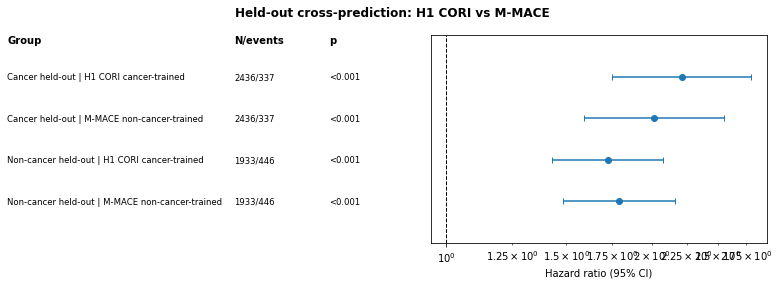

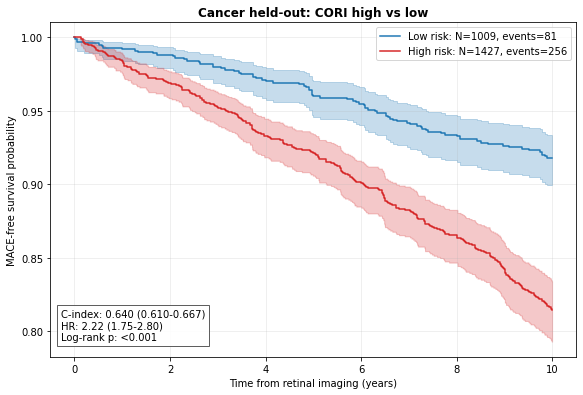

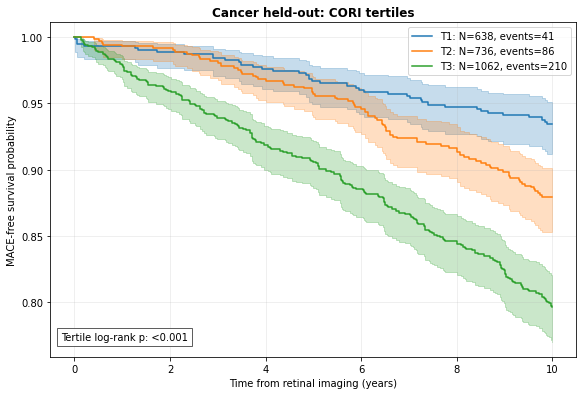

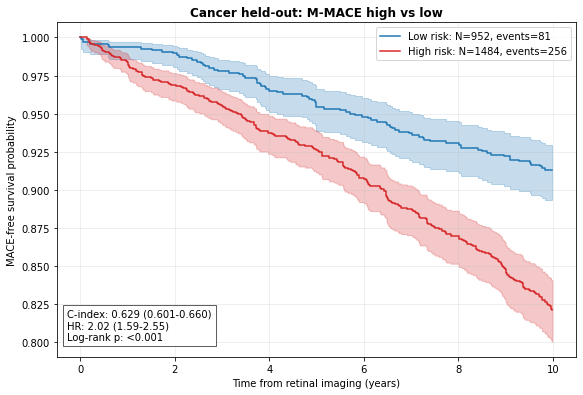

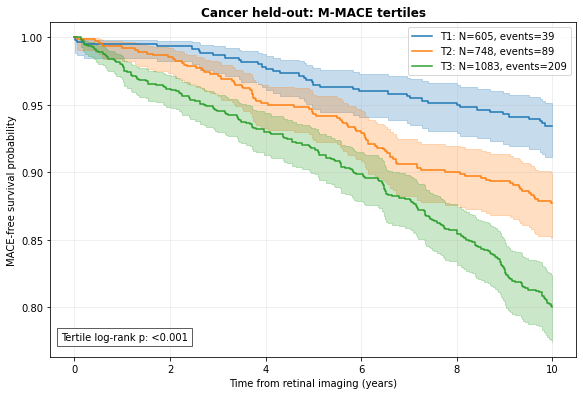

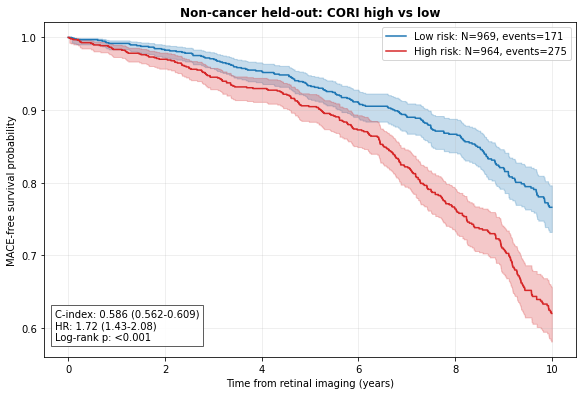

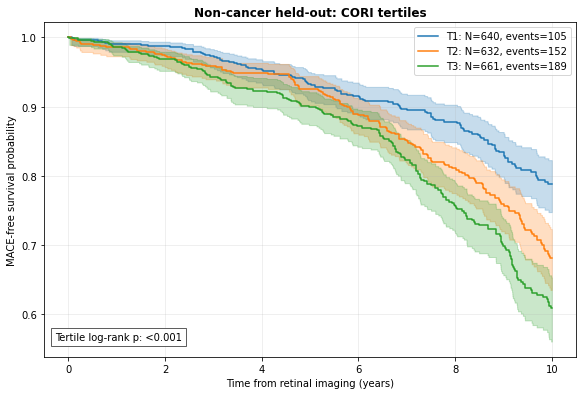

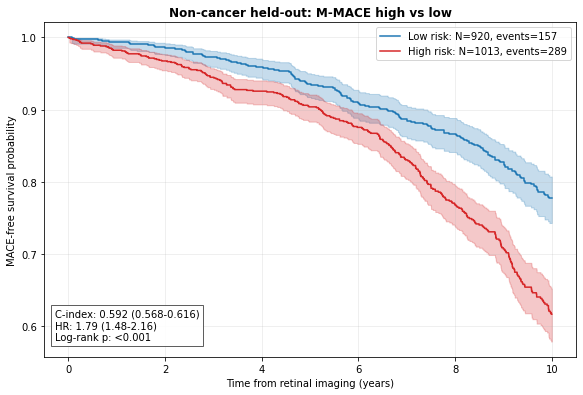

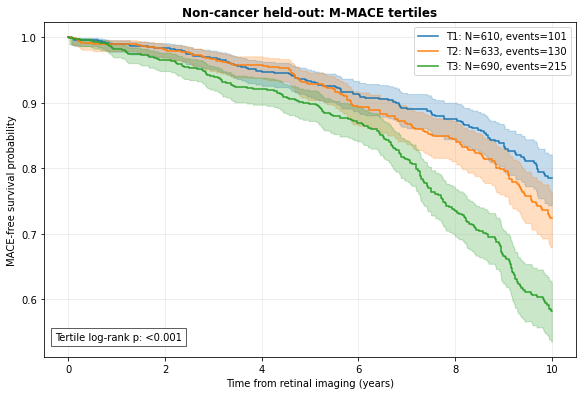

In [25]:
logger.section("Cross-prediction performance, KM curves, and forest")
rows = []
for cohort, df in [
    ("Cancer development", cancer_train),
    ("Cancer held-out", cancer_test),
    ("Non-cancer development", nc_train),
    ("Non-cancer held-out", nc_test),
]:
    for model, score, grp in [
        ("H1 CORI cancer-trained", "CORI_score", "CORI_high_risk"),
        ("M-MACE non-cancer-trained", "MMACE_score", "MMACE_high_risk"),
    ]:
        if score in df.columns and grp in df.columns and df[score].notna().sum() > 20:
            row = performance_row(df, cohort + " | " + model, score, grp)
            row.update({"cohort": cohort, "model": model})
            rows.append(row)
perf = pd.DataFrame(rows)
perf.to_csv(TABLEDIR / "H2_Table_02_cross_prediction_performance.csv", index=False)
logger.df("Cross-prediction performance", perf)

fp = perf[perf["cohort"].str.contains("held-out", case=False, na=False)].copy()
fp["label"] = fp["cohort"] + " | " + fp["model"]
forest_plot(fp, "label", "HR_High_vs_Low", "HR_CI_Low", "HR_CI_High", "LogRank_p", "N", "Events",
            "Held-out cross-prediction: H1 CORI vs M-MACE",
            FIGDIR / "H2_Fig01_cross_prediction_forest")

for cohort, df in [("Cancer held-out", cancer_test), ("Non-cancer held-out", nc_test)]:
    for model, score, grp, ter in [
        ("CORI", "CORI_score", "CORI_high_risk", "CORI_risk_tertile"),
        ("M-MACE", "MMACE_score", "MMACE_high_risk", "MMACE_risk_tertile"),
    ]:
        plot_km_high_low(df, score, grp, f"{cohort}: {model} high vs low", FIGDIR / f"H2_KM_{safe_name(cohort)}_{model}_highlow")
        plot_km_tertiles(df, score, ter, f"{cohort}: {model} tertiles", FIGDIR / f"H2_KM_{safe_name(cohort)}_{model}_tertiles")

In [26]:
logger.section("Cancer-status interaction likelihood-ratio tests")
pooled = pd.concat([
    cancer_test.assign(cancer_status=1, cohort="Cancer"),
    nc_test.assign(cancer_status=0, cohort="Non-cancer")
], ignore_index=True)
clinical_covars, AGE_COL = one_age_covars(pooled, logger=logger)
rows = []
for score, label in [
    ("CORI_score", "H1 CORI x cancer status"),
    ("MMACE_score", "M-MACE x cancer status"),
]:
    rows.append(lrt_interaction(pooled, score, "cancer_status", covars=[], label=label + " unadjusted"))
    rows.append(lrt_interaction(pooled, score, "cancer_status", covars=clinical_covars, label=label + " adjusted"))
interaction = pd.DataFrame(rows)
interaction.to_csv(TABLEDIR / "H2_Table_03_cancer_status_interaction_LRT.csv", index=False)
logger.df("Cancer-status interaction LRT", interaction)


Cancer-status interaction likelihood-ratio tests
One-age clinical policy: age variable=age_at_image_visit; covariates=['age_at_image_visit', 'sex_clinical', 'Diabetes_clinical', 'HTN_clinical', 'height']

Cancer-status interaction LRT
                          analysis    N  Events  LRT_chi_square  df        p  base_c_index  interaction_c_index                                                                covariates
H1 CORI x cancer status unadjusted 4369     783        9.620054   1 0.001925      0.646522             0.646241                                                                          
  H1 CORI x cancer status adjusted 4369     783        0.261185   1 0.609307      0.683693             0.683428 age_at_image_visit, sex_clinical, Diabetes_clinical, HTN_clinical, height
 M-MACE x cancer status unadjusted 4369     783        7.650620   1 0.005675      0.645282             0.645723                                                                          
   M-MACE x cancer s


Predicted-risk reclassification matrices, alluvial plots, and feature-rank transition


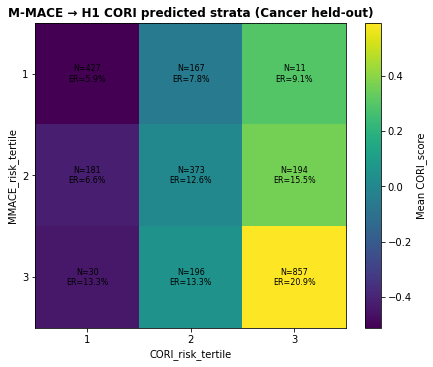

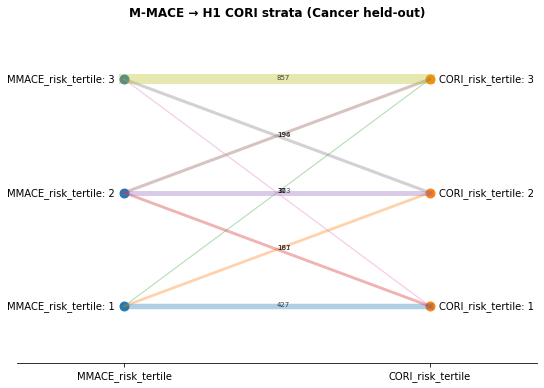

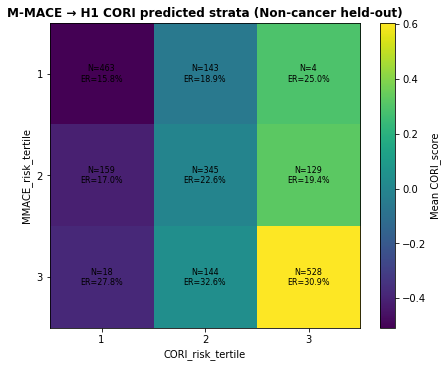

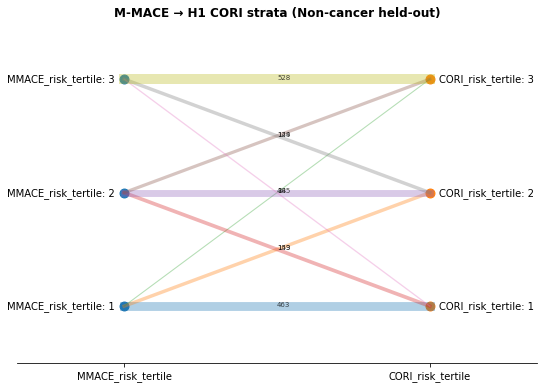

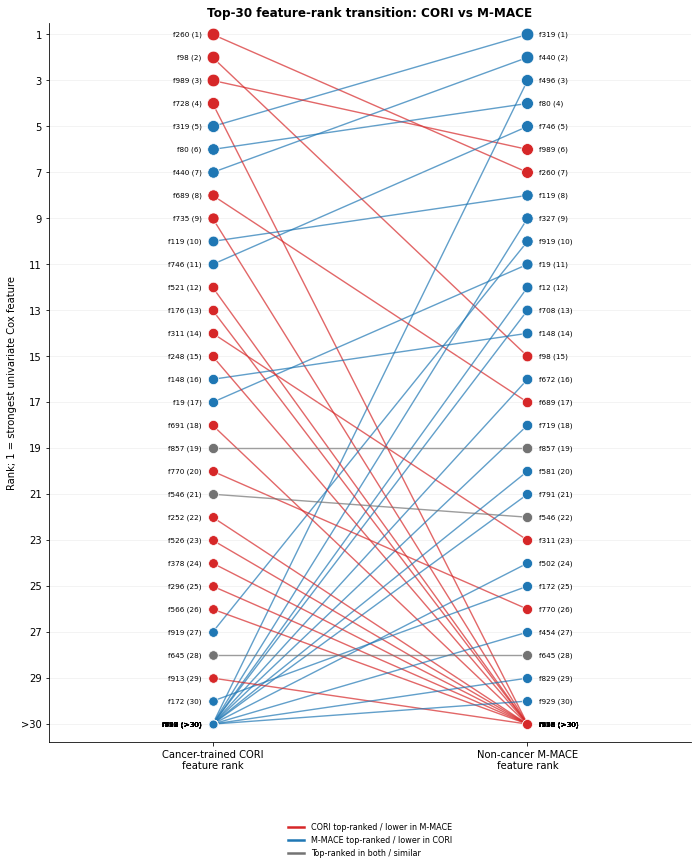

Saved fixed feature-rank plot to: figures/H2_MCORI_MMACE_locked_CORI_v13/figures/H2_feature_rank_transition_FIXED_COMPACT.png
Y-axis capped at >30. If you still see huge whitespace, you are viewing the old file.

Feature-rank transition table
feature  CORI_rank  CORI_importance  CORI_hr  MMACE_rank  MMACE_importance  MMACE_hr  best_rank  CORI_plot_rank  MMACE_plot_rank  plot_rank_shift_MMACE_minus_CORI  full_rank_shift_MMACE_minus_CORI      membership
   f260          1         8.959088 0.715192           7          6.757544  0.777872          1               1                7                                 6                                 6     Top in both
   f319          5         7.333123 0.735978           1         10.606570  0.708452          1               5                1                                -4                                -4     Top in both
    f98          2         8.465373 1.382607          15          5.165103  1.244729          2               2       

In [27]:
logger.section("Predicted-risk reclassification matrices, alluvial plots, and feature-rank transition")
# Reclassification compares locked CORI tertiles vs M-MACE tertiles.
for cohort, df in [("Cancer held-out", cancer_test), ("Non-cancer held-out", nc_test)]:
    rec = df[["event", "MMACE_risk_tertile", "CORI_risk_tertile", "MMACE_score", "CORI_score"]].dropna().copy()
    if len(rec) == 0:
        logger.log(f"Skipping reclassification for {cohort}: no complete rows.")
        continue
    cnt, er, mp = transition_heatmap(
        rec, "MMACE_risk_tertile", "CORI_risk_tertile", "event", "CORI_score",
        f"M-MACE → H1 CORI predicted strata ({cohort})",
        FIGDIR / f"H2_reclassification_{safe_name(cohort)}"
    )
    cnt.to_csv(TABLEDIR / f"H2_reclassification_counts_{safe_name(cohort)}.csv")
    er.to_csv(TABLEDIR / f"H2_reclassification_event_rates_{safe_name(cohort)}.csv")
    mp.to_csv(TABLEDIR / f"H2_reclassification_mean_CORI_score_{safe_name(cohort)}.csv")
    alluvial_static(rec, "MMACE_risk_tertile", "CORI_risk_tertile",
                    f"M-MACE → H1 CORI strata ({cohort})",
                    FIGDIR / f"H2_alluvial_{safe_name(cohort)}")

# Feature-rank transition: H1 CORI feature ranking vs M-MACE ranking
cori_rank = (
    cori_bundle["feature_ranking"]
    if isinstance(cori_bundle.get("feature_ranking"), pd.DataFrame)
    else pd.read_csv(H1_LOCKED_OUTDIR / "tables" / "CORI_feature_univariate_cox_ranking.csv")
)

rank_shift = feature_rank_shift_bump_FIXED(
    cori_rank,
    mmace_rank,
    FIGDIR,
    TABLEDIR,
    top_n=30,
    prefix="H2",
)

logger.df("Feature-rank transition table", rank_shift)

In [28]:
logger.section("Final H2 manifest")
manifest = {
    "notebook": "H2",
    "purpose": "Load H1 locked CORI; train only M-MACE; compare cancer-trained vs non-cancer-trained retinal signatures.",
    "H1_CORI_bundle": str(H1_CORI_BUNDLE),
    "center_col": CENTER_COL,
    "cancer_development_N": len(cancer_train),
    "cancer_heldout_N": len(cancer_test),
    "noncancer_development_N": len(nc_train),
    "noncancer_heldout_N": len(nc_test),
    "MMACE_manifest": mmace_manifest,
    "clinical_covariates_for_LRT": clinical_covars,
    "age_variable": AGE_COL,
}
(OUTDIR / "H2_output_manifest.json").write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
logger.log(json.dumps(manifest, indent=2, default=str))


Final H2 manifest
{
  "notebook": "H2",
  "purpose": "Load H1 locked CORI; train only M-MACE; compare cancer-trained vs non-cancer-trained retinal signatures.",
  "H1_CORI_bundle": "figures/H1_CORI_LOCKED_MODEL_v13/models/CORI_locked_model_bundle.pkl",
  "center_col": "UK Biobank assessment centre | Instance 0",
  "cancer_development_N": 2152,
  "cancer_heldout_N": 2436,
  "noncancer_development_N": 1408,
  "noncancer_heldout_N": 1933,
  "MMACE_manifest": {
    "prefix": "MMACE",
    "n_initial_features": 1024,
    "n_after_variance_filter": 1024,
    "n_selected_features": 5,
    "selected_features": [
      "f319",
      "f440",
      "f496",
      "f80",
      "f746"
    ],
    "top5_features": [
      "f319",
      "f440",
      "f496",
      "f80",
      "f746"
    ],
    "top10_features": [
      "f319",
      "f440",
      "f496",
      "f80",
      "f746"
    ],
    "variance_threshold": 1e-08,
    "max_missing": 0.5,
    "cox_rank_penalizer": 0.01,
    "candidate_ks": [
     

In [29]:
# Handcrafted-feature comparator below reuses H1's locked HCORI bundle.
set_handcrafted_logger(logger)


H2 handcrafted comparison: locked HCORI vs non-cancer H-M-MACE using cached features
Loading cached handcrafted features from: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/tables/H1_handcrafted_subject_level_features_cached.csv
Cached handcrafted rows before duplicate removal: 54060
Cached handcrafted unique subjects: 54060
Usable numeric handcrafted feature columns: 454


,cache_path,n_rows_raw,n_unique_subjects,n_numeric_features,numeric_feature_examples
0,figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_H...,54060,54060,454,"[HC_vessel_All_pixel_degree_1, HC_vessel_All_p..."


,cohort,cohort_rows_raw,cohort_unique_eids,handcrafted_rows_raw,handcrafted_unique_eids,merged_rows,matched_rows_any_handcrafted_feature,unmatched_rows,match_rate,n_numeric_handcrafted_features_available,n_handcrafted_features_added,feature_examples,status
0,cancer_train,2152,2152,54060,54060,2152,2003,149,0.930762,454,454,"['HC_vessel_All_pixel_degree_1', 'HC_vessel_Al...",ok
1,cancer_test,2436,2436,54060,54060,2436,2250,186,0.923645,454,454,"['HC_vessel_All_pixel_degree_1', 'HC_vessel_Al...",ok
2,noncancer_train,1408,1408,54060,54060,1408,1408,0,1.000000,454,454,"['HC_vessel_All_pixel_degree_1', 'HC_vessel_Al...",ok
3,noncancer_test,1933,1933,54060,54060,1933,1933,0,1.000000,454,454,"['HC_vessel_All_pixel_degree_1', 'HC_vessel_Al...",ok


Merged handcrafted cohort shapes:
  cancer_train_hc: (2152, 1728)
  cancer_test_hc : (2436, 1728)
  nc_train_hc    : (1408, 2083)
  nc_test_hc     : (1933, 2083)

Handcrafted merge QC:
         cohort  cohort_rows_raw  cohort_unique_eids  handcrafted_rows_raw  handcrafted_unique_eids  merged_rows  matched_rows_any_handcrafted_feature  unmatched_rows  match_rate  n_numeric_handcrafted_features_available  n_handcrafted_features_added                                                                                                                                                                                                                                                                                                                                                           feature_examples status
   cancer_train             2152                2152                 54060                    54060         2152                                  2003             149    0.930762                

,cohort,model,N,Events,C_index,HR_high_vs_low,HR_low,HR_high,HR_95CI,p,p_fmt,score_col,group_col
0,Cancer held-out,HCORI cancer-trained handcrafted,2436,337,0.558060,1.217720,0.988597,1.499945,1.22 (0.99-1.50),0.064007,0.064,HCORI_score,HCORI_high_risk
1,Cancer held-out,H-M-MACE non-cancer-trained handcrafted,2436,337,0.572849,1.462990,1.178427,1.816268,1.46 (1.18-1.82),0.000565,<0.001,HMMACE_score,HMMACE_high_risk
2,Non-cancer held-out,HCORI cancer-trained handcrafted,1933,446,0.555202,1.333805,1.112068,1.599755,1.33 (1.11-1.60),0.001903,0.002,HCORI_score,HCORI_high_risk
3,Non-cancer held-out,H-M-MACE non-cancer-trained handcrafted,1933,446,0.563429,1.464720,1.220357,1.758014,1.46 (1.22-1.76),0.000042,<0.001,HMMACE_score,HMMACE_high_risk


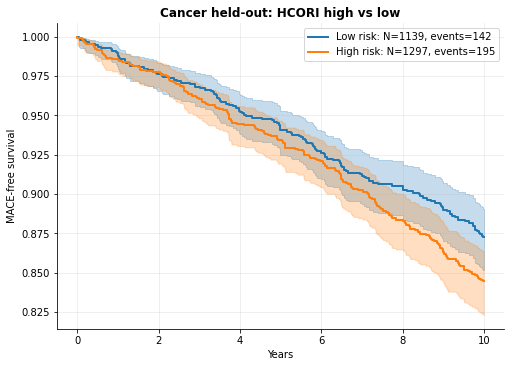

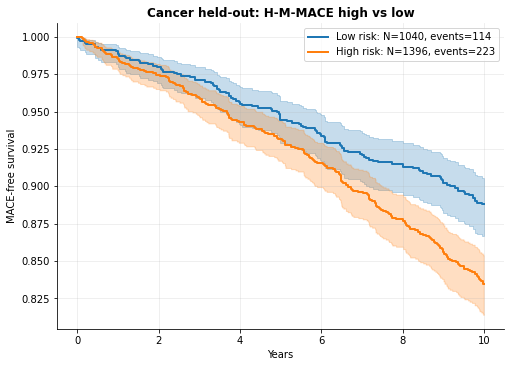

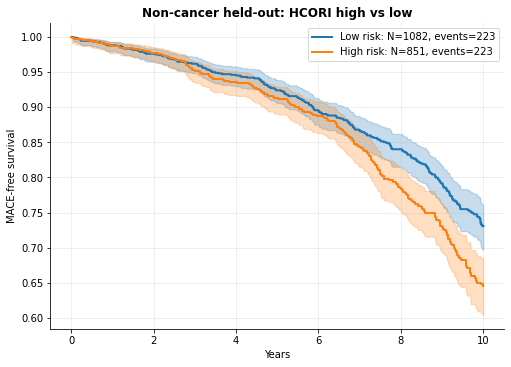

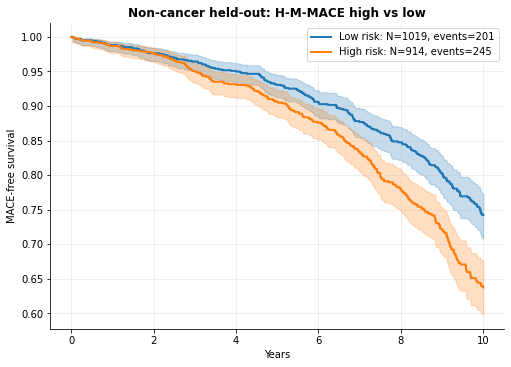

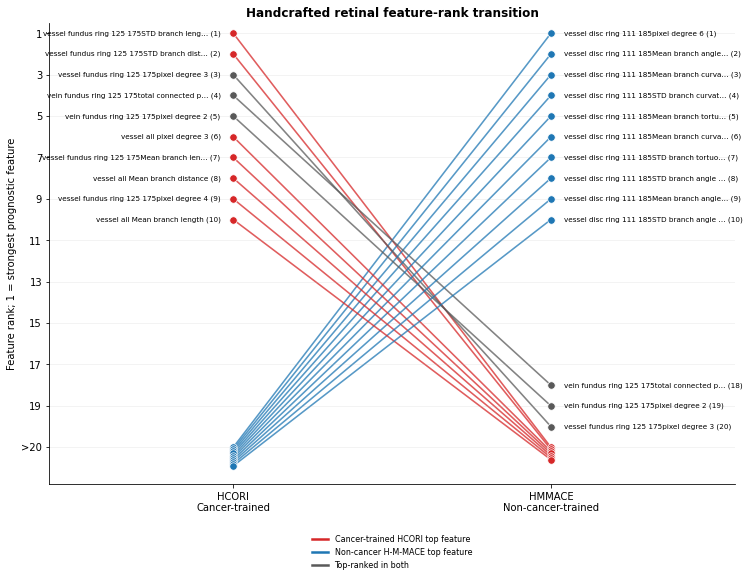

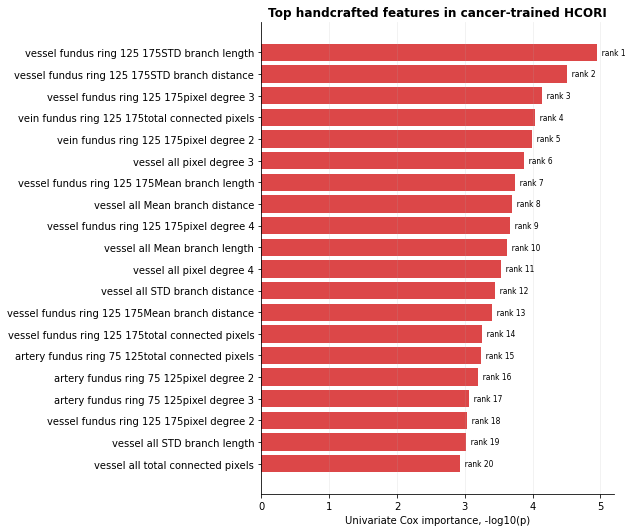

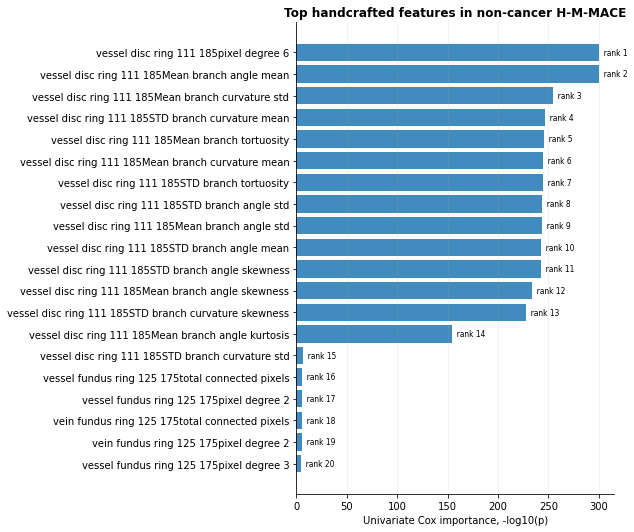

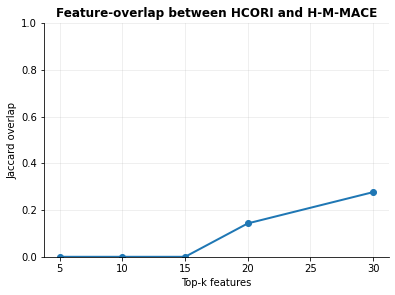

,feature,HCORI_rank,HCORI_importance,HCORI_hr,HMMACE_rank,HMMACE_importance,HMMACE_hr,rank_shift_HMMACE_minus_HCORI,best_rank,membership,feature_short,HCORI_plot_rank,HMMACE_plot_rank,HCORI_y,HMMACE_y
415,HC_vessel_fundus_ring_125_175STD_branch_length,1.0,4.952134,1.230200,151,0.628313,1.059031,150.0,1.0,HCORI top only,vessel fundus ring 125 175STD branch leng…,1.0,21,1.0,21.0
364,HC_vessel_disc_ring_111_185pixel_degree_6,NaN,NaN,NaN,1,300.000000,1378.542611,NaN,1.0,H-M-MACE top only,vessel disc ring 111 185pixel degree 6,21.0,1,21.0,1.0
414,HC_vessel_fundus_ring_125_175STD_branch_distance,2.0,4.506977,1.223794,139,0.719147,1.064846,137.0,2.0,HCORI top only,vessel fundus ring 125 175STD branch dist…,2.0,21,2.0,21.1
338,HC_vessel_disc_ring_111_185Mean_branch_angle_mean,NaN,NaN,NaN,2,300.000000,7098.414380,NaN,2.0,H-M-MACE top only,vessel disc ring 111 185Mean branch angle…,21.0,2,21.1,2.0
419,HC_vessel_fundus_ring_125_175pixel_degree_3,3.0,4.140780,0.790724,20,5.080040,0.790685,17.0,3.0,Top in both,vessel fundus ring 125 175pixel degree 3,3.0,20,3.0,20.0
344,HC_vessel_disc_ring_111_185Mean_branch_curvatu...,NaN,NaN,NaN,3,254.968884,5080.713363,NaN,3.0,H-M-MACE top only,vessel disc ring 111 185Mean branch curva…,21.0,3,21.2,3.0
272,HC_vein_fundus_ring_125_175total_connected_pixels,4.0,4.036567,0.806552,18,5.393129,0.797179,14.0,4.0,Top in both,vein fundus ring 125 175total connected p…,4.0,18,4.0,18.0
353,HC_vessel_disc_ring_111_185STD_branch_curvatur...,NaN,NaN,NaN,4,246.610479,4884.423991,NaN,4.0,H-M-MACE top only,vessel disc ring 111 185STD branch curvat…,21.0,4,21.3,4.0
267,HC_vein_fundus_ring_125_175pixel_degree_2,5.0,3.996034,0.807708,19,5.372846,0.797771,14.0,5.0,Top in both,vein fundus ring 125 175pixel degree 2,5.0,19,5.0,19.0
347,HC_vessel_disc_ring_111_185Mean_branch_tortuosity,NaN,NaN,NaN,5,245.290819,7490.345637,NaN,5.0,H-M-MACE top only,vessel disc ring 111 185Mean branch tortu…,21.0,5,21.4,5.0


,top_k,HCORI_top_k,HMMACE_top_k,overlap_n,jaccard
0,5,5,5,0,0.000000
1,10,10,10,0,0.000000
2,15,15,15,0,0.000000
3,20,20,20,5,0.142857
4,30,30,30,13,0.276596


H2 cached handcrafted analysis complete.
Outputs saved to: figures/H2_MCORI_MMACE_locked_CORI_v13/handcrafted_HMMACE


In [30]:
# ============================================================
# AUTO-HANDCRAFTED-FINAL-v3 — H2 handcrafted HCORI vs H-M-MACE comparison
# CACHE-BASED VERSION: does NOT read one-CSV-per-subject from OneDrive
# ============================================================

_hc_section("H2 handcrafted comparison: locked HCORI vs non-cancer H-M-MACE using cached features")

# ------------------------------------------------------------
# 0. Locate cached handcrafted feature matrix
# ------------------------------------------------------------
# Preferred: H1 should have already created one of these cache files.
# Edit this list if your H1 cache has a different filename.

HANDCRAFTED_CACHE_CANDIDATES = [
    # H1 output cache locations
    H1_HCORI_OUTDIR / "tables" / "handcrafted_features_cache.pkl",
    H1_LOCKED_OUTDIR / "tables" / "handcrafted_features_cache.parquet",
    H1_HCORI_CACHED_FEATURES,

    # Generic manuscript output cache locations
    BASE_OUTDIR / "handcrafted_features_cache.pkl",
    BASE_OUTDIR / "handcrafted_features_cache.parquet",
    BASE_OUTDIR / "handcrafted_features_cache.csv",

    # Current notebook (H2) output cache locations
    Path(OUTDIR) / "tables" / "handcrafted_features_cache.pkl",
    Path(OUTDIR) / "tables" / "handcrafted_features_cache.parquet",
    Path(OUTDIR) / "tables" / "handcrafted_features_cache.csv",
]

hc_features, hc_cache_info = load_cached_handcrafted_features(
    HANDCRAFTED_CACHE_CANDIDATES,
    id_col_name="eid",
)

# Save cache QC
HMMACE_OUTDIR = Path(OUTDIR) / "handcrafted_HMMACE"
HMMACE_TABLEDIR = HMMACE_OUTDIR / "tables"
HMMACE_MODELDIR = HMMACE_OUTDIR / "models"
HMMACE_FIGDIR = HMMACE_OUTDIR / "figures"

for p in [HMMACE_OUTDIR, HMMACE_TABLEDIR, HMMACE_MODELDIR, HMMACE_FIGDIR]:
    p.mkdir(parents=True, exist_ok=True)

pd.DataFrame([hc_cache_info]).to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_cache_loading_QC.csv",
    index=False,
)

display(pd.DataFrame([hc_cache_info]))


# ------------------------------------------------------------
# 1. Merge cached handcrafted features into H2 cohorts
# ------------------------------------------------------------

# Use robust merge instead of older merge_handcrafted()
cancer_train_hc, cancer_train_hc_merge = merge_handcrafted_cached_safe(
    cancer_train,
    hc_features,
    cohort_name="cancer_train",
)

cancer_test_hc, cancer_test_hc_merge = merge_handcrafted_cached_safe(
    cancer_test,
    hc_features,
    cohort_name="cancer_test",
)

nc_train_hc, nc_train_hc_merge = merge_handcrafted_cached_safe(
    nc_train,
    hc_features,
    cohort_name="noncancer_train",
)

nc_test_hc, nc_test_hc_merge = merge_handcrafted_cached_safe(
    nc_test,
    hc_features,
    cohort_name="noncancer_test",
)

merge_qc = pd.concat(
    [
        cancer_train_hc_merge,
        cancer_test_hc_merge,
        nc_train_hc_merge,
        nc_test_hc_merge,
    ],
    ignore_index=True,
)

merge_qc.to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_cache_merge_QC.csv",
    index=False,
)

display(merge_qc)

# Optional but useful sanity checks
print("Merged handcrafted cohort shapes:")
print("  cancer_train_hc:", cancer_train_hc.shape)
print("  cancer_test_hc :", cancer_test_hc.shape)
print("  nc_train_hc    :", nc_train_hc.shape)
print("  nc_test_hc     :", nc_test_hc.shape)

print("\nHandcrafted merge QC:")
print(merge_qc.to_string(index=False))



# ------------------------------------------------------------
# 2. Load locked H1 HCORI bundle and apply to cancer/non-cancer held-out cohorts
# ------------------------------------------------------------
if not H1_HCORI_BUNDLE.exists():
    raise FileNotFoundError(
        f"Cannot find H1 HCORI bundle: {H1_HCORI_BUNDLE}. "
        "Run patched H1 first so HCORI is trained/saved using the cached handcrafted matrix."
    )

cancer_test_hc = apply_handcrafted_bundle(
    H1_HCORI_BUNDLE,
    cancer_test_hc,
    prefix="HCORI",
)

nc_test_hc = apply_handcrafted_bundle(
    H1_HCORI_BUNDLE,
    nc_test_hc,
    prefix="HCORI",
)


# ------------------------------------------------------------
# 3. Train handcrafted H-M-MACE in non-cancer development cohort only
# ------------------------------------------------------------
nc_train_hc, nc_test_hc, hmmace_features, hmmace_rank, hmmace_bundle, hmmace_cv = train_handcrafted_survival_model(
    nc_train_hc,
    nc_test_hc,
    prefix="HMMACE",
    outdir=HMMACE_OUTDIR,
)

# Apply H-M-MACE to cancer held-out cohort
hmmace_bundle_path = HMMACE_MODELDIR / "HMMACE_locked_handcrafted_model_bundle.pkl"

if not hmmace_bundle_path.exists():
    raise FileNotFoundError(f"Expected H-M-MACE bundle not found: {hmmace_bundle_path}")

cancer_test_hc = apply_handcrafted_bundle(
    hmmace_bundle_path,
    cancer_test_hc,
    prefix="HMMACE",
)


# ------------------------------------------------------------
# 4. Cross-prediction performance table
# ------------------------------------------------------------
rows = []

for cohort, d in [
    ("Cancer held-out", cancer_test_hc),
    ("Non-cancer held-out", nc_test_hc),
]:
    for model_label, score, group in [
        ("HCORI cancer-trained handcrafted", "HCORI_score", "HCORI_high_risk"),
        ("H-M-MACE non-cancer-trained handcrafted", "HMMACE_score", "HMMACE_high_risk"),
    ]:
        if score not in d.columns:
            continue

        row = hc_performance_row(
            d,
            cohort,
            score,
            group if group in d.columns else None,
        )
        row["model"] = model_label
        row["score_col"] = score
        row["group_col"] = group if group in d.columns else None
        rows.append(row)

hc_h2_perf = pd.DataFrame(rows)

hc_h2_perf.to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_HCORI_vs_HMMACE_cross_prediction.csv",
    index=False,
)

display(hc_h2_perf)


# ------------------------------------------------------------
# 5. KM plots
# ------------------------------------------------------------
plot_hc_km(
    cancer_test_hc,
    "HCORI_high_risk",
    "Cancer held-out: HCORI high vs low",
    HMMACE_FIGDIR / "H2_KM_cancer_HCORI",
)

plot_hc_km(
    cancer_test_hc,
    "HMMACE_high_risk",
    "Cancer held-out: H-M-MACE high vs low",
    HMMACE_FIGDIR / "H2_KM_cancer_HMMACE",
)

plot_hc_km(
    nc_test_hc,
    "HCORI_high_risk",
    "Non-cancer held-out: HCORI high vs low",
    HMMACE_FIGDIR / "H2_KM_noncancer_HCORI",
)

plot_hc_km(
    nc_test_hc,
    "HMMACE_high_risk",
    "Non-cancer held-out: H-M-MACE high vs low",
    HMMACE_FIGDIR / "H2_KM_noncancer_HMMACE",
)


# ------------------------------------------------------------
# 6. Interpretable handcrafted feature-transition plot
# ------------------------------------------------------------
with open(H1_HCORI_BUNDLE, "rb") as f:
    hcori_bundle_loaded = pickle.load(f)

transition_clean, transition_full, transition_overlap = plot_handcrafted_feature_transition_clean(
    hcori_bundle_loaded.get("feature_ranking"),
    hmmace_rank,
    figdir=HMMACE_FIGDIR,
    tabledir=HMMACE_TABLEDIR,
    left_label="HCORI",
    right_label="HMMACE",
    top_n=20,
    top_each_side=10,
    prefix="H2_HC",
)

transition_clean.to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_feature_transition_CLEAN_selected.csv",
    index=False,
)

transition_full.to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_feature_transition_FULL.csv",
    index=False,
)

transition_overlap.to_csv(
    HMMACE_TABLEDIR / "H2_handcrafted_feature_overlap_by_topk.csv",
    index=False,
)

display(transition_clean)
display(transition_overlap)



# ------------------------------------------------------------
# 7. Save H2 handcrafted manifest
# ------------------------------------------------------------
h2_hc_manifest = {
    "analysis": "H2 handcrafted HCORI vs H-M-MACE",
    "feature_source": "cached handcrafted feature matrix",
    "cache_info": hc_cache_info,
    "HCORI_bundle_path": str(H1_HCORI_BUNDLE),
    "HMMACE_bundle_path": str(hmmace_bundle_path),
    "n_HMMACE_selected_features": len(hmmace_features),
    "HMMACE_selected_features": list(hmmace_features),
    "outputs": {
        "performance": str(HMMACE_TABLEDIR / "H2_handcrafted_HCORI_vs_HMMACE_cross_prediction.csv"),
        "feature_transition": str(HMMACE_TABLEDIR / "H2_handcrafted_feature_transition_HCORI_vs_HMMACE.csv"),
        "merge_qc": str(HMMACE_TABLEDIR / "H2_handcrafted_cache_merge_QC.csv"),
    },
}

with open(HMMACE_TABLEDIR / "H2_handcrafted_cache_based_manifest.json", "w") as f:
    json.dump(h2_hc_manifest, f, indent=2, default=str)

print("H2 cached handcrafted analysis complete.")
print(f"Outputs saved to: {HMMACE_OUTDIR}")

# H3 — Treatment-stratified analysis using locked H1 CORI

Loads locked H1 CORI and merges treatment labels.

In [31]:
# ============================================================
# H3 setup — reuses the paths/constants declared in the shared CONFIGURATION cell above
# ============================================================
RUN_NAME = "H3_treatment_locked_CORI_v13"
OUTDIR, FIGDIR, TABLEDIR, MODELDIR, QCDIR = ensure_dirs(BASE_OUTDIR / RUN_NAME)
logger = QCLogger(QCDIR / "H3_QC_log.txt")
logger.section("H3 initialized")
if not H1_CORI_BUNDLE.exists():
    raise FileNotFoundError(f"Missing H1 locked CORI bundle: {H1_CORI_BUNDLE}. Run H1 first.")


H3 initialized


In [32]:
logger.section("Reuse shared cancer cohort, merge treatment labels, and apply locked H1 CORI")

cancer_train, cancer_test = cancer_train.copy(), cancer_test.copy()
cohort_audit.to_csv(TABLEDIR / "H3_Table_00A_cohort_audit.csv", index=False)

cancer_train = merge_treatment_labels(cancer_train, treatment_csv=TREATMENT_CSV, chemo_csv=CHEMO_CSV, logger=logger)
cancer_test = merge_treatment_labels(cancer_test, treatment_csv=TREATMENT_CSV, chemo_csv=CHEMO_CSV, logger=logger)
treat_counts = pd.DataFrame([
    {"label": "Any systemic treatment", "N": int(cancer_train["treatment_any"].sum() + cancer_test["treatment_any"].sum())},
    {"label": "Treatment naive", "N": int(cancer_train["treatment_naive"].sum() + cancer_test["treatment_naive"].sum())},
    {"label": "Chemotherapy", "N": int(cancer_train["chemo_any"].sum() + cancer_test["chemo_any"].sum())},
    {"label": "Immunotherapy", "N": int(cancer_train["io_any"].sum() + cancer_test["io_any"].sum())},
])
treat_counts.to_csv(TABLEDIR / "H3_Table_00B_treatment_label_counts_overall.csv", index=False)
logger.df("Overall treatment counts", treat_counts)

split_table.to_csv(TABLEDIR / "H3_Table_01_center_split.csv", index=False)

# Load H1 locked CORI and apply. No CORI retraining in H3.
cori_bundle = load_model_bundle(H1_CORI_BUNDLE)
cancer_train = apply_model_bundle(cori_bundle, cancer_train, score_col="CORI_score", prefix="CORI", logger=logger)
cancer_test = apply_model_bundle(cori_bundle, cancer_test, score_col="CORI_score", prefix="CORI", logger=logger)

score_cols = [c for c in ["eid", CENTER_COL, "time", "event", "CORI_score", "CORI_high_risk", "CORI_risk_tertile", "treatment_any", "treatment_naive", "chemo_any", "io_any"] if c in cancer_test.columns]
pd.concat([
    cancer_train[score_cols].assign(split="development"),
    cancer_test[score_cols].assign(split="held_out"),
]).to_csv(TABLEDIR / "H3_Table_02_CORI_scores_with_treatment.csv", index=False)


Reuse shared cancer cohort, merge treatment labels, and apply locked H1 CORI
Merged treatment file: data/risk_score_df_final_shared_22April_2026.csv; added columns=15
Merged treatment file: data/chemo_status.csv; added columns=1
Treatment columns used: any=has_target_drug, chemo=has_chemo, io=has_io

Treatment counts
                 label    N
Any systemic treatment  171
       Treatment naive 1981
          Chemotherapy   14
         Immunotherapy  158
[shape=(4, 2)]
Merged treatment file: data/risk_score_df_final_shared_22April_2026.csv; added columns=15
Merged treatment file: data/chemo_status.csv; added columns=1
Treatment columns used: any=has_target_drug, chemo=has_chemo, io=has_io

Treatment counts
                 label    N
Any systemic treatment  165
       Treatment naive 2271
          Chemotherapy   22
         Immunotherapy  144
[shape=(4, 2)]

Overall treatment counts
                 label    N
Any systemic treatment  336
       Treatment naive 4252
          Chemothe


Treatment-stratified performance and KM curves


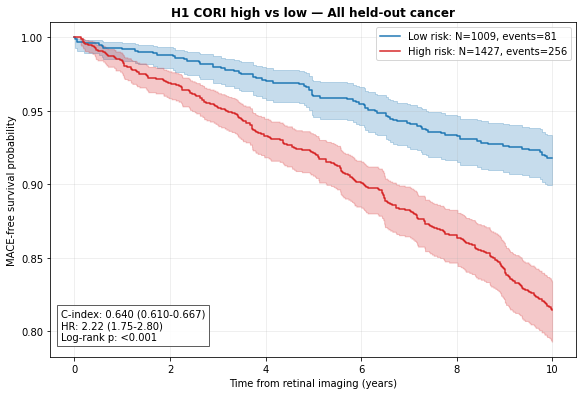

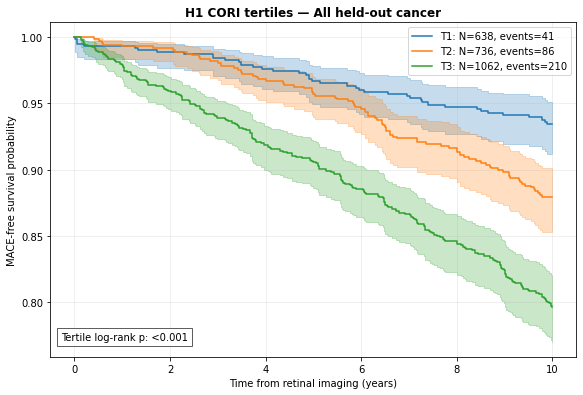

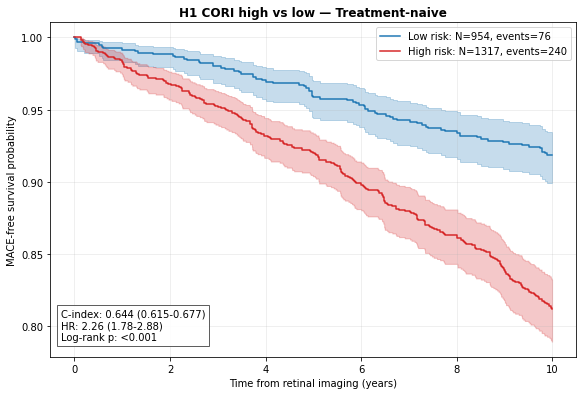

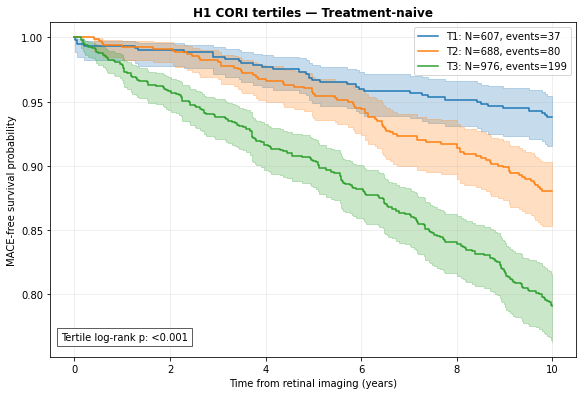

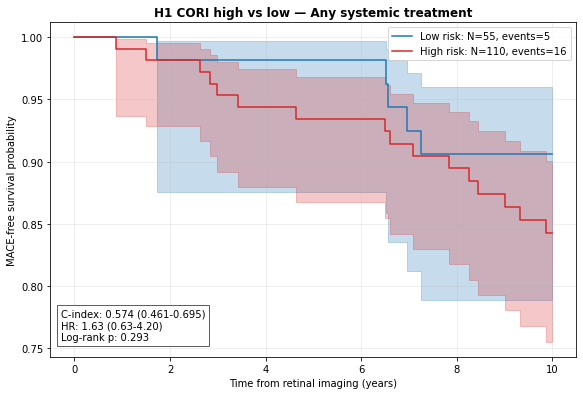

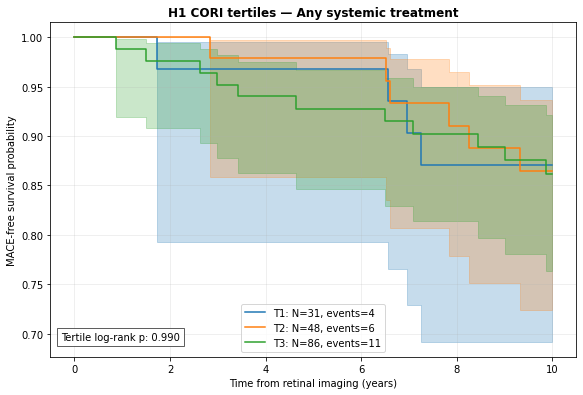

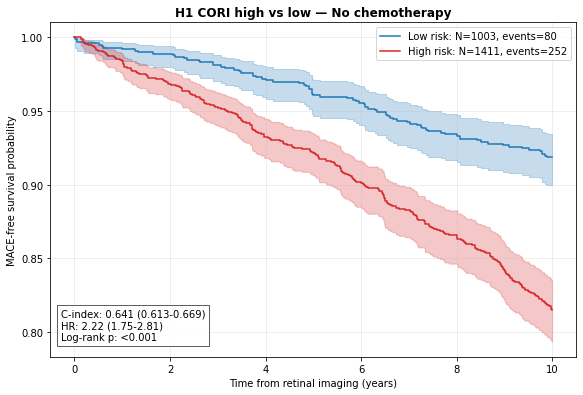

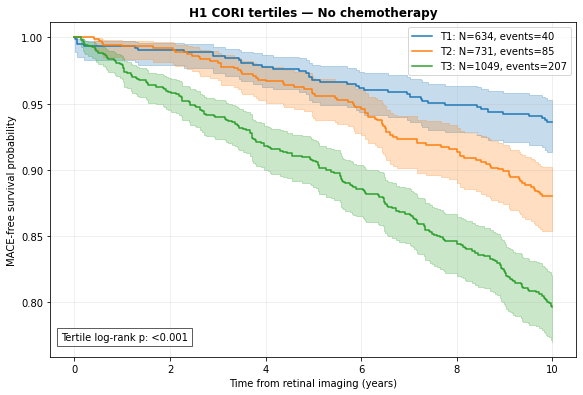

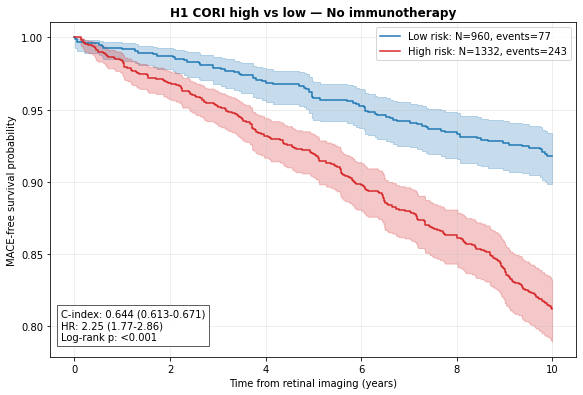

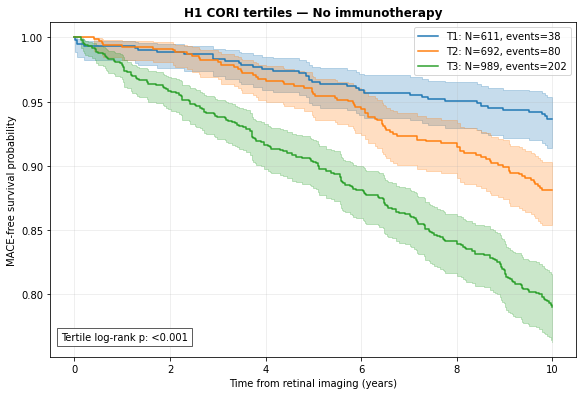

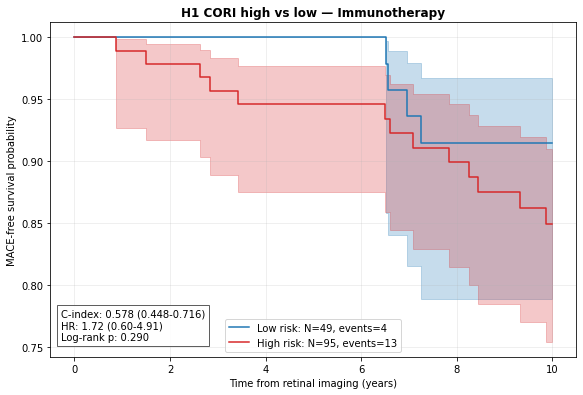

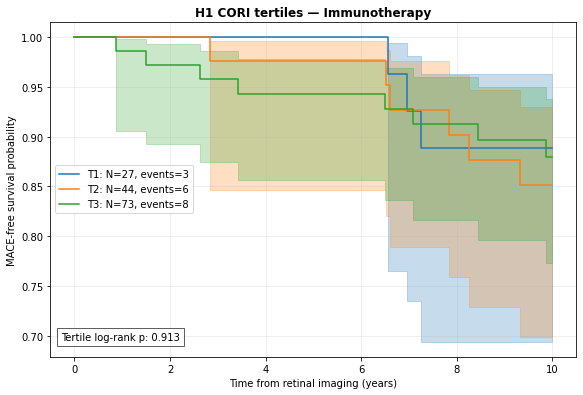


Treatment-stratified performance
                cohort    N  Events  C_index  C_index_low  C_index_high        C_index_95CI           HR_95CI                  label  HR_High_vs_Low  HR_CI_Low  HR_CI_High    LogRank_p                stratum       status
   All held-out cancer 2436     337 0.639822     0.610448      0.667017 0.640 (0.610-0.667)  2.22 (1.75-2.80)    All held-out cancer        2.215307   1.752070    2.801020 1.868830e-12    All held-out cancer   analyzable
       Treatment-naive 2271     316 0.644368     0.614809      0.677146 0.644 (0.615-0.677)  2.26 (1.78-2.88)        Treatment-naive        2.261891   1.775463    2.881587 2.369914e-12        Treatment-naive   analyzable
Any systemic treatment  165      21 0.574454     0.461169      0.695004 0.574 (0.461-0.695)  1.63 (0.63-4.20) Any systemic treatment        1.625198   0.629450    4.196157 2.933934e-01 Any systemic treatment   analyzable
       No chemotherapy 2414     332 0.640722     0.612628      0.669156 0.641 (0.6

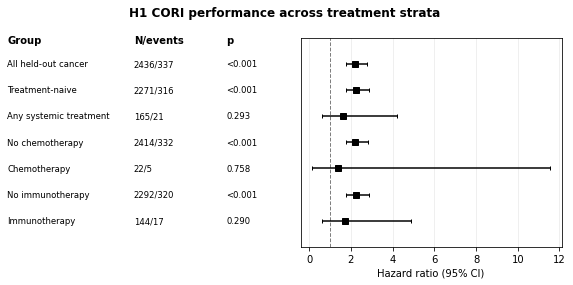

In [74]:
logger.section("Treatment-stratified performance and KM curves")
strata = [
    ("All held-out cancer", cancer_test),
    ("Treatment-naive", cancer_test[cancer_test["treatment_naive"].eq(1)]),
    ("Any systemic treatment", cancer_test[cancer_test["treatment_any"].eq(1)]),
    ("No chemotherapy", cancer_test[cancer_test["chemo_any"].eq(0)]),
    ("Chemotherapy", cancer_test[cancer_test["chemo_any"].eq(1)]),
    ("No immunotherapy", cancer_test[cancer_test["io_any"].eq(0)]),
    ("Immunotherapy", cancer_test[cancer_test["io_any"].eq(1)]),
]
rows = []
km_dir = FIGDIR / "H3_treatment_KM_curves"
km_dir.mkdir(parents=True, exist_ok=True)
for label, sub in strata:
    row = performance_row(sub, label, "CORI_score", "CORI_high_risk") if len(sub) else {"cohort": label, "N": 0, "Events": 0}
    row["stratum"] = label
    row["status"] = "analyzable" if row.get("N",0) >= 30 and row.get("Events",0) >= 5 else "underpowered"
    rows.append(row)
    if row["status"] == "analyzable":
        plot_km_high_low(sub, "CORI_score", "CORI_high_risk", f"H1 CORI high vs low — {label}", km_dir / f"H3_KM_{safe_name(label)}_high_low")
        if sub["CORI_risk_tertile"].nunique(dropna=True) >= 2:
            plot_km_tertiles(sub, "CORI_score", "CORI_risk_tertile", f"H1 CORI tertiles — {label}", km_dir / f"H3_KM_{safe_name(label)}_tertiles")
treat_perf = pd.DataFrame(rows)
treat_perf.to_csv(TABLEDIR / "H3_Table_03_treatment_stratified_performance.csv", index=False)
logger.df("Treatment-stratified performance", treat_perf)

fp = treat_perf.copy()
fp["label"] = fp["stratum"]
forest_plot(fp.dropna(subset=["HR_High_vs_Low"]), "label", "HR_High_vs_Low", "HR_CI_Low", "HR_CI_High", "LogRank_p", "N", "Events",
            "H1 CORI performance across treatment strata",
            FIGDIR / "H3_Fig01_treatment_forest")

In [75]:
logger.section("3/5/10-year horizon performance in key treatment strata")

all_horizon = []

for label, sub in strata:
    hp = safe_horizon_performance(
        sub,
        score_col="CORI_score",
        group_col="CORI_high_risk",
        horizon_cols=HORIZON_COLS,
        label=label,
        tabledir=TABLEDIR,
        prefix=f"H3_{safe_name(label)}",
        n_boot=300,
    )

    if len(hp):
        all_horizon.append(hp)

if all_horizon:
    horizon_all = pd.concat(all_horizon, ignore_index=True)
    horizon_all.to_csv(
        TABLEDIR / "H3_Table_04_treatment_horizon_performance_all.csv",
        index=False,
    )
    logger.df("Treatment horizon performance", horizon_all)
else:
    horizon_all = pd.DataFrame()
    logger.log("No treatment horizon performance rows generated.")


3/5/10-year horizon performance in key treatment strata

Treatment horizon performance
                cohort  horizon_years    N  Events  C_index  C_index_low  C_index_high        C_index_95CI  HR_High_vs_Low  HR_CI_Low  HR_CI_High           HR_95CI    LogRank_p LogRank_p_fmt status
   All held-out cancer              3 2436      87 0.660417     0.604773      0.705432 0.660 (0.605-0.705)        1.904516   1.267906    2.860767  1.90 (1.27-2.86) 3.798537e-04        <0.001     ok
   All held-out cancer              5 2436     151 0.627369     0.585525      0.671685 0.627 (0.586-0.672)        1.799018   1.302711    2.484408  1.80 (1.30-2.48) 1.016104e-04        <0.001     ok
   All held-out cancer             10 2436     337 0.639822     0.610448      0.667017 0.640 (0.610-0.667)        2.215307   1.752070    2.801020  2.22 (1.75-2.80) 1.868830e-12        <0.001     ok
       Treatment-naive              3 2271      81 0.664290     0.606370      0.725017 0.664 (0.606-0.725)        1.9031


Treatment-adjusted Cox models: locked CORI vs treatment exposure

Treatment-adjusted CORI models
                                 analysis       variable    N  Events       HR   HR_low  HR_high          HR_95CI            p  p_fmt  model_C_index status
            CORI adjusted \n Any systemic         CORI_z 2436     337 1.446459 1.315422 1.590550 1.45 (1.32-1.59) 2.567158e-14 <0.001       0.640411     ok
            CORI adjusted \n Any systemic  treatment_any 2436     337 0.895547 0.618667 1.296343 0.90 (0.62-1.30) 5.588184e-01  0.559       0.640411     ok
          CORI adjusted \n Chemo & immuno         CORI_z 2436     337 1.445364 1.314416 1.589357 1.45 (1.31-1.59) 2.909848e-14 <0.001       0.641780     ok
          CORI adjusted \n Chemo & immuno      chemo_any 2436     337 1.391207 0.610462 3.170480 1.39 (0.61-3.17) 4.320897e-01  0.432       0.641780     ok
          CORI adjusted \n Chemo & immuno         io_any 2436     337 0.854224 0.571828 1.276082 0.85 (0.57-1.28) 4.416384

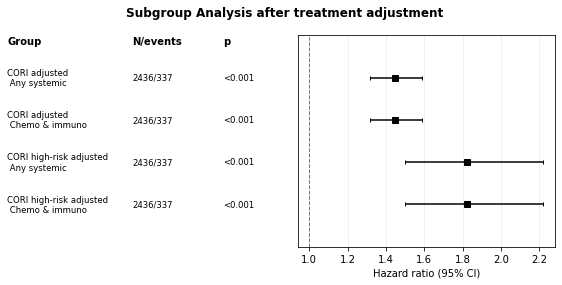

In [78]:
# ============================================================
# H3 — Treatment-adjusted Cox models using locked H1 CORI
# Purpose: test whether CORI is independent of systemic therapy exposure
# ============================================================

logger.section("Treatment-adjusted Cox models: locked CORI vs treatment exposure")

# ----------------------------
# 1. Z-score locked CORI using development set only
# ----------------------------
cancer_train, cancer_test, cori_z_params = zscore_from_train_apply(
    cancer_train,
    cancer_test,
    col="CORI_score",
    out_col="CORI_z",
)

pd.DataFrame([{
    "score": "CORI_score",
    "z_mean_from_development": cori_z_params["mean"],
    "z_sd_from_development": cori_z_params["sd"],
    "note": "Held-out CORI_z uses development-set mean/SD only; CORI model itself is locked.",
}]).to_csv(TABLEDIR / "H3_Table_treatment_adjustment_CORI_z_params.csv", index=False)


# ----------------------------
# 2. Treatment-adjusted models in held-out cancer cohort
# ----------------------------
treatment_covars_core = [
    "treatment_any",
    "chemo_any",
    "io_any",
]

treatment_covars_chemo_io = [
    "chemo_any",
    "io_any",
]

adjusted_tables = []

models_to_run = [
    (
        "CORI adjusted \n Any systemic",
        "CORI_z",
        ["treatment_any"],
    ),
    (
        "CORI adjusted \n Chemo & immuno",
        "CORI_z",
        treatment_covars_chemo_io,
    ),
    (
        "CORI high-risk adjusted \n Any systemic",
        "CORI_high_risk",
        ["treatment_any"],
    ),
    (
        "CORI high-risk adjusted \n Chemo & immuno",
        "CORI_high_risk",
        treatment_covars_chemo_io,
    ),
]

for label, score_col, covars in models_to_run:
    tab, model = fit_treatment_adjusted_cox(
        cancer_test,
        score_col=score_col,
        covars=covars,
        label=label,
        tabledir=TABLEDIR,
        prefix="H3",
        penalizer=0.05,
    )
    adjusted_tables.append(tab)

h3_treatment_adjusted_all = pd.concat(adjusted_tables, ignore_index=True)
h3_treatment_adjusted_all.to_csv(
    TABLEDIR / "H3_Table_treatment_adjusted_CORI_models_all.csv",
    index=False,
)

logger.df("Treatment-adjusted CORI models", h3_treatment_adjusted_all)


# ----------------------------
# 3. Forest plot for CORI terms only
# ----------------------------
cori_terms = h3_treatment_adjusted_all[
    h3_treatment_adjusted_all["variable"].isin(["CORI_z", "CORI_high_risk"])
].copy()

if len(cori_terms):
    cori_terms["label"] = cori_terms["analysis"]
    forest_plot(
        cori_terms,
        label_col="label",
        hr_col="HR",
        lo_col="HR_low",
        hi_col="HR_high",
        p_col="p",
        n_col="N",
        event_col="Events",
        title="Subgroup Analysis after treatment adjustment",
        save_base=FIGDIR / "H3_Fig_treatment_adjusted_CORI_forest",
    )
else:
    logger.log("No CORI terms available for treatment-adjusted forest plot.")

In [79]:
logger.section("Treatment interaction likelihood-ratio tests")
clinical_covars, AGE_COL = one_age_covars(cancer_test, logger=logger)
rows = []
for flag, label in [
    ("treatment_any", "H1 CORI x any systemic treatment"),
    ("chemo_any", "H1 CORI x chemotherapy"),
    ("io_any", "H1 CORI x immunotherapy"),
]:
    if flag in cancer_test.columns:
        try:
            rows.append(lrt_interaction(cancer_test, "CORI_score", flag, covars=[], label=label + " unadjusted"))
        except Exception as e:
            rows.append({"analysis": label + " unadjusted", "status": str(e)})
        try:
            rows.append(lrt_interaction(cancer_test, "CORI_score", flag, covars=clinical_covars, label=label + " adjusted"))
        except Exception as e:
            rows.append({"analysis": label + " adjusted", "status": str(e)})
interactions = pd.DataFrame(rows)
interactions.to_csv(TABLEDIR / "H3_Table_05_treatment_interaction_LRT.csv", index=False)
logger.df("Treatment interaction LRT", interactions)

manifest = {
    "notebook": "H3",
    "purpose": "Load H1 locked CORI and evaluate treatment strata; no CORI retraining.",
    "H1_CORI_bundle": str(H1_CORI_BUNDLE),
    "treatment_files": [str(TREATMENT_CSV), str(CHEMO_CSV)],
    "clinical_covariates_for_adjusted_LRT": clinical_covars,
    "age_variable": AGE_COL,
}
(OUTDIR / "H3_output_manifest.json").write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
logger.log(json.dumps(manifest, indent=2, default=str))


Treatment interaction likelihood-ratio tests
One-age clinical policy: age variable=age_at_image_visit; covariates=['age_at_image_visit', 'sex_clinical', 'Diabetes_clinical', 'HTN_clinical', 'height']

Treatment interaction LRT
                                   analysis    N  Events  LRT_chi_square  df        p  base_c_index  interaction_c_index                                                                covariates
H1 CORI x any systemic treatment unadjusted 2436     337        0.138696   1 0.709580      0.640411             0.640894                                                                          
  H1 CORI x any systemic treatment adjusted 2436     337        0.134003   1 0.714318      0.710833             0.710722 age_at_image_visit, sex_clinical, Diabetes_clinical, HTN_clinical, height
          H1 CORI x chemotherapy unadjusted 2436     337        0.069282   1 0.792386      0.640700             0.640816                                                                   

In [80]:
# Handcrafted-feature comparator below reuses H1's locked HCORI bundle.
set_handcrafted_logger(logger)


H3 handcrafted HCORI treatment-stratified analysis using cached H1 features
Using cached handcrafted features: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/tables/H1_handcrafted_subject_level_features_cached.csv
Using locked H1 HCORI bundle: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/models/HCORI_locked_handcrafted_model_bundle.pkl
Cached handcrafted subjects loaded: 54060 | numeric feature columns: 455
Dropping stale HC/HCORI columns before remerge: 3


,source,N_before_merge,Events_before_merge,N_after_merge,Events_after_merge,N_with_any_cached_handcrafted_feature,N_without_cached_handcrafted_feature,n_HC_columns_available,cached_feature_path,locked_HCORI_bundle
0,H3 cancer_test,2436,337,2436,337,2250,186,453,figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_H...,figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_H...


,has_hc_feature,N,Events,HCORI_score_nonmissing,HCORI_score_mean,HCORI_score_sd,HCORI_high_risk_N
0,False,186,9,186,-0.019700,0.000000,186
1,True,2250,328,2250,-0.006602,0.240411,1111


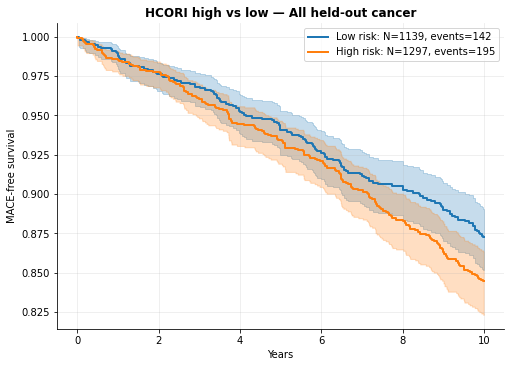

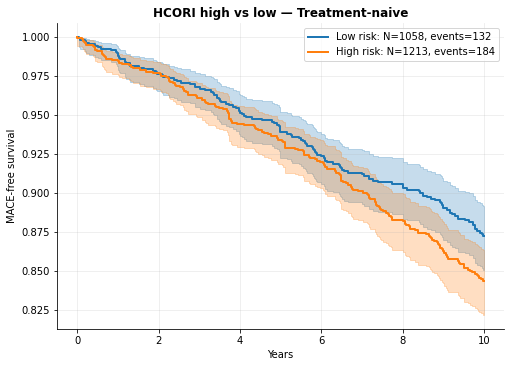

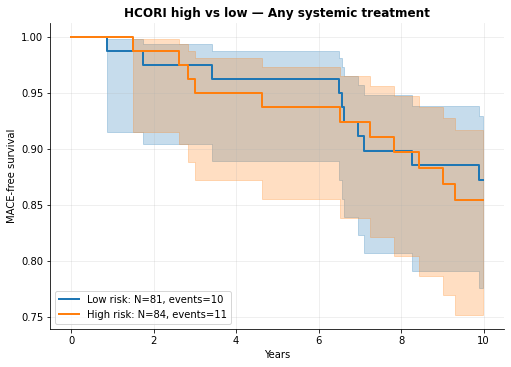

Skipping HCORI KM for Chemotherapy: N=22, Events=5, risk_groups=2


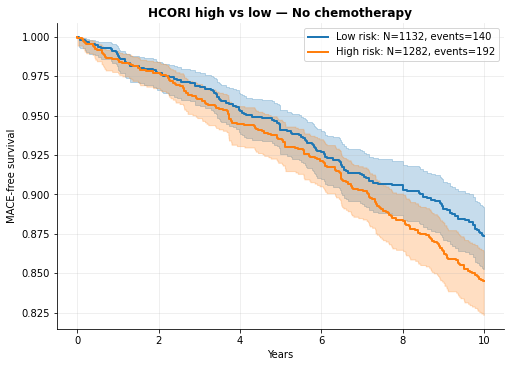

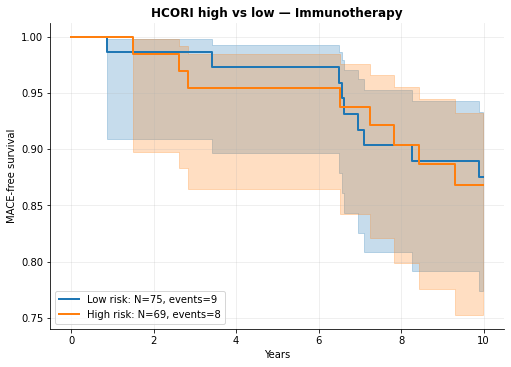

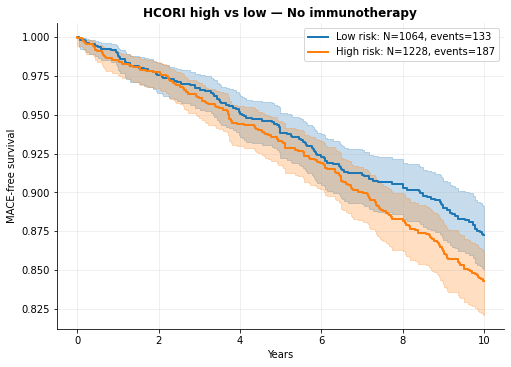

,cohort,model,N,Events,C_index,HR_high_vs_low,HR_low,HR_high,HR_95CI,p,p_fmt,stratum,status
0,All held-out cancer,HCORI,2436,337,0.558060,1.217720,0.988597,1.499945,1.22 (0.99-1.50),0.064007,0.064,All held-out cancer,ok
1,Treatment-naive,HCORI,2271,316,0.558059,1.222721,0.985648,1.516816,1.22 (0.99-1.52),0.067473,0.067,Treatment-naive,ok
2,Any systemic treatment,HCORI,165,21,0.561218,1.135440,0.497901,2.589317,1.14 (0.50-2.59),0.762657,0.763,Any systemic treatment,ok
3,Chemotherapy,HCORI,22,5,0.431579,0.652473,0.112560,3.782168,0.65 (0.11-3.78),0.633908,0.634,Chemotherapy,event_limited_or_single_risk_group
4,No chemotherapy,HCORI,2414,332,0.559473,1.222928,0.991344,1.508612,1.22 (0.99-1.51),0.060272,0.060,No chemotherapy,ok
5,Immunotherapy,HCORI,144,17,0.575614,1.060089,0.424765,2.645672,1.06 (0.42-2.65),0.900482,0.900,Immunotherapy,ok
6,No immunotherapy,HCORI,2292,320,0.557471,1.224533,0.988281,1.517261,1.22 (0.99-1.52),0.064001,0.064,No immunotherapy,ok


Completed H3 cached-feature HCORI treatment analysis. Outputs saved under: figures/H4_CMR_locked_CORI_v13/handcrafted_HCORI_treatment_cached


In [81]:
# ============================================================
# AUTO-HANDCRAFTED-FINAL-v3 — H3 treatment-stratified handcrafted HCORI analysis
# UPDATED: use cached H1 handcrafted features + locked H1 HCORI bundle
# ============================================================

_hc_section("H3 handcrafted HCORI treatment-stratified analysis using cached H1 features")

# ----------------------------
# 0. Cached features / locked bundle from H1 (shared H1_HCORI_* constants)
# ----------------------------
if not H1_HCORI_CACHED_FEATURES.exists():
    raise FileNotFoundError(
        f"Cannot find cached handcrafted features:\n{H1_HCORI_CACHED_FEATURES}\n"
        "Run patched H1 first and ensure it saved H1_handcrafted_subject_level_features_cached.csv."
    )

if not H1_HCORI_BUNDLE.exists():
    raise FileNotFoundError(
        f"Cannot find locked H1 HCORI bundle:\n{H1_HCORI_BUNDLE}\n"
        "Run patched H1 first and ensure it saved HCORI_locked_handcrafted_model_bundle.pkl."
    )

_hc_log(f"Using cached handcrafted features: {H1_HCORI_CACHED_FEATURES}")
_hc_log(f"Using locked H1 HCORI bundle: {H1_HCORI_BUNDLE}")


# ----------------------------
# 1. Load cached subject-level handcrafted features
# ----------------------------
hc_features_cached = load_cached_handcrafted_features_exact(H1_HCORI_CACHED_FEATURES, id_col_name="eid")


# ----------------------------
# 2. Merge cached features into H3 held-out cancer cohort
# ----------------------------
if "cancer_test" not in globals():
    raise NameError("cancer_test is not defined. Run the earlier H3 cells first.")

cancer_test_hc = cancer_test.copy()

if "eid" not in cancer_test_hc.columns:
    raise ValueError("cancer_test must contain an 'eid' column for handcrafted feature merge.")

cancer_test_hc["eid"] = (
    cancer_test_hc["eid"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
)

before_n = len(cancer_test_hc)
before_events = int(pd.to_numeric(cancer_test_hc["event"], errors="coerce").fillna(0).sum())

# Drop stale HC columns if rerunning this cell
stale_hc_cols = [
    c for c in cancer_test_hc.columns
    if str(c).startswith("HC_") or str(c).startswith("HCORI_")
]
if stale_hc_cols:
    _hc_log(f"Dropping stale HC/HCORI columns before remerge: {len(stale_hc_cols)}")
    cancer_test_hc = cancer_test_hc.drop(columns=stale_hc_cols)

cancer_test_hc = cancer_test_hc.merge(
    hc_features_cached,
    on="eid",
    how="left",
    validate="many_to_one",
)

hc_cols_available = [c for c in cancer_test_hc.columns if str(c).startswith("HC_")]
has_any_hc = cancer_test_hc[hc_cols_available].notna().any(axis=1) if hc_cols_available else pd.Series(False, index=cancer_test_hc.index)

merge_qc = pd.DataFrame([{
    "source": "H3 cancer_test",
    "N_before_merge": before_n,
    "Events_before_merge": before_events,
    "N_after_merge": len(cancer_test_hc),
    "Events_after_merge": int(pd.to_numeric(cancer_test_hc["event"], errors="coerce").fillna(0).sum()),
    "N_with_any_cached_handcrafted_feature": int(has_any_hc.sum()),
    "N_without_cached_handcrafted_feature": int((~has_any_hc).sum()),
    "n_HC_columns_available": len(hc_cols_available),
    "cached_feature_path": str(H1_HCORI_CACHED_FEATURES),
    "locked_HCORI_bundle": str(H1_HCORI_BUNDLE),
}])

H3_HC_OUTDIR = Path(OUTDIR) / "handcrafted_HCORI_treatment_cached"
H3_HC_TABLEDIR = H3_HC_OUTDIR / "tables"
H3_HC_FIGDIR = H3_HC_OUTDIR / "figures"

for p in [H3_HC_OUTDIR, H3_HC_TABLEDIR, H3_HC_FIGDIR]:
    p.mkdir(parents=True, exist_ok=True)

merge_qc.to_csv(
    H3_HC_TABLEDIR / "H3_handcrafted_cached_feature_merge_QC.csv",
    index=False,
)

display(merge_qc)


# ----------------------------
# 3. Apply locked H1 HCORI model to H3 held-out cancer cohort
# ----------------------------
# IMPORTANT: This does not retrain HCORI.
# It uses H1 handcrafted medians, means/SDs, coefficients, and thresholds.
cancer_test_hc = apply_handcrafted_bundle(
    H1_HCORI_BUNDLE,
    cancer_test_hc,
    prefix="HCORI",
)

score_qc = (
    cancer_test_hc
    .assign(has_hc_feature=has_any_hc.values)
    .groupby("has_hc_feature")
    .agg(
        N=("eid", "count"),
        Events=("event", "sum"),
        HCORI_score_nonmissing=("HCORI_score", lambda x: pd.to_numeric(x, errors="coerce").notna().sum()),
        HCORI_score_mean=("HCORI_score", "mean"),
        HCORI_score_sd=("HCORI_score", "std"),
        HCORI_high_risk_N=("HCORI_high_risk", "sum"),
    )
    .reset_index()
)

score_qc.to_csv(
    H3_HC_TABLEDIR / "H3_handcrafted_HCORI_scoring_QC.csv",
    index=False,
)

display(score_qc)


# ----------------------------
# 4. Build H3 treatment strata on the HCORI-scored dataframe
# ----------------------------
# Safer to reconstruct strata directly from cancer_test_hc so all treatment labels
# remain attached after merge/scoring.
hc_strata = [("All held-out cancer", cancer_test_hc)]

for col, pos_label, neg_label in [
    ("treatment_naive", "Treatment-naive", None),
    ("treatment_any", "Any systemic treatment", None),
    ("chemo_any", "Chemotherapy", "No chemotherapy"),
    ("io_any", "Immunotherapy", "No immunotherapy"),
]:
    if col in cancer_test_hc.columns:
        x = pd.to_numeric(cancer_test_hc[col], errors="coerce").fillna(0).astype(int)
        hc_strata.append((pos_label, cancer_test_hc.loc[x.eq(1)].copy()))
        if neg_label is not None:
            hc_strata.append((neg_label, cancer_test_hc.loc[x.eq(0)].copy()))
    else:
        _hc_log(f"Treatment column not found in cancer_test_hc, skipping stratum: {col}")


# ----------------------------
# 5. Treatment-stratified HCORI performance and KM plots
# ----------------------------
rows = []

for label, sub in hc_strata:
    if len(sub) == 0:
        rows.append({
            "stratum": label,
            "cohort": label,
            "model": "HCORI",
            "N": 0,
            "Events": 0,
            "status": "empty",
        })
        continue

    # Keep only rows with valid HCORI score/time/event
    sub_valid = sub[["time", "event", "HCORI_score", "HCORI_high_risk"]].replace(
        [np.inf, -np.inf],
        np.nan,
    ).dropna().copy()

    r = hc_performance_row(
        sub_valid,
        label,
        "HCORI_score",
        "HCORI_high_risk",
    )

    r["stratum"] = label
    r["status"] = (
        "ok"
        if r.get("N", 0) >= 30
        and r.get("Events", 0) >= 5
        and sub_valid["HCORI_high_risk"].nunique(dropna=True) >= 2
        else "event_limited_or_single_risk_group"
    )

    rows.append(r)

    if r["status"] == "ok":
        plot_hc_km(
            sub_valid,
            "HCORI_high_risk",
            f"HCORI high vs low — {label}",
            H3_HC_FIGDIR / f"H3_HCORI_KM_cached_{_hc_safe_name(label)}",
        )
    else:
        _hc_log(
            f"Skipping HCORI KM for {label}: "
            f"N={r.get('N', 0)}, Events={r.get('Events', 0)}, "
            f"risk_groups={sub_valid['HCORI_high_risk'].nunique(dropna=True) if len(sub_valid) else 0}"
        )

h3_hc_perf = pd.DataFrame(rows)

# Format optional columns if present
if {"HR_high_vs_low", "HR_low", "HR_high"}.issubset(h3_hc_perf.columns):
    h3_hc_perf["HR_95CI"] = h3_hc_perf.apply(
        lambda r: _hc_fmt_ci(
            r.get("HR_high_vs_low", np.nan),
            r.get("HR_low", np.nan),
            r.get("HR_high", np.nan),
            2,
        ),
        axis=1,
    )

if "p" in h3_hc_perf.columns:
    h3_hc_perf["p_fmt"] = h3_hc_perf["p"].map(_hc_pformat)

h3_hc_perf.to_csv(
    H3_HC_TABLEDIR / "H3_handcrafted_HCORI_treatment_strata_performance_cached_features.csv",
    index=False,
)

display(h3_hc_perf)


# ----------------------------
# 6. Save scored held-out file for inspection/reuse
# ----------------------------
keep_cols = [
    c for c in [
        "eid",
        "time",
        "event",
        "HCORI_score",
        "HCORI_high_risk",
        "HCORI_risk_tertile",
        "treatment_naive",
        "treatment_any",
        "chemo_any",
        "io_any",
    ]
    if c in cancer_test_hc.columns
]

cancer_test_hc[keep_cols].to_csv(
    H3_HC_TABLEDIR / "H3_handcrafted_HCORI_scored_heldout_cancer_cached_features.csv",
    index=False,
)

_hc_log(
    "Completed H3 cached-feature HCORI treatment analysis. "
    f"Outputs saved under: {H3_HC_OUTDIR}"
)

# H4 — CMR phenotyping

In [82]:
# ============================================================
# H4 setup — reuses the paths/constants declared in the shared CONFIGURATION cell above
# ============================================================
RUN_NAME = "H4_CMR_locked_CORI_v13"
OUTDIR, FIGDIR, TABLEDIR, MODELDIR, QCDIR = ensure_dirs(BASE_OUTDIR / RUN_NAME)
logger = QCLogger(QCDIR / "H4_QC_log.txt")
logger.section("H4 initialized")
if not H1_CORI_BUNDLE.exists():
    raise FileNotFoundError(f"Missing H1 locked CORI bundle: {H1_CORI_BUNDLE}. Run H1 first.")


H4 initialized


In [83]:
# ============================================================
# CURATED CMR VARIABLE SPECIFICATION
# Edit this cell to control exactly which CMR phenotypes are analyzed.
# ============================================================

# 1) Optional exact CMR variable names.
# Put full cleaned CMR labels here if you want to force-include specific phenotypes.
# These names should match columns AFTER visit reshaping, i.e., without "| Instance 2/3".
# Example:
# EXACT_CMR_VARIABLES = [
#     "Left ventricular ejection fraction",
#     "Left ventricular end-diastolic volume",
#     "Descending aorta maximum area",
#     "Descending aorta distensibility",
# ]
EXACT_CMR_VARIABLES = []

# 2) Optional keywords to force-include any phenotype containing these terms.
# Keep empty unless you want a targeted analysis.
USER_CMR_KEYWORDS = []



# 4) Families to use in the primary analysis. CMR_FEATURE_FAMILIES itself (the
# family -> include/exclude regex map) is declared once in src/cmr_helper.py.
# Use "ALL_CURATED" to include every family there.
PRIMARY_CMR_FAMILIES = "ALL_CURATED"
# Or specify a focused subset, e.g.:
# PRIMARY_CMR_FAMILIES = ["LV_structure_function", "Aortic_geometry", "Aortic_stiffness_function", "Blood_pressure_PWA"]

# 5) CMR QC thresholds.
MIN_CMR_NONMISSING = 30
MIN_CMR_UNIQUE_VALUES = 5

# 6) Plot limits.
TOP_FEATURES_PER_FAMILY_FOR_TABLES = 8
TOP_FEATURES_FOR_OVERALL_PLOTS = 20

In [84]:
logger.section("Reuse shared cancer cohort and apply locked H1 CORI")

cancer_train, cancer_test = cancer_train.copy(), cancer_test.copy()
cohort_audit.to_csv(TABLEDIR / "H4_Table_00_cohort_audit.csv", index=False)
split_table.to_csv(TABLEDIR / "H4_Table_01_center_split.csv", index=False)

# Load H1 locked CORI and apply. No CORI retraining in H4.
cori_bundle = load_model_bundle(H1_CORI_BUNDLE)
cancer_train = apply_model_bundle(cori_bundle, cancer_train, score_col="CORI_score", prefix="CORI", logger=logger)
cancer_test = apply_model_bundle(cori_bundle, cancer_test, score_col="CORI_score", prefix="CORI", logger=logger)
score_df = pd.concat([cancer_train.assign(split="development"), cancer_test.assign(split="held_out")], ignore_index=True)


Reuse shared cancer cohort and apply locked H1 CORI
Applied locked CORI model to N=2152; score_col=CORI_score
Applied locked CORI model to N=2436; score_col=CORI_score


In [85]:
logger.section("Load and reshape visit-aware CMR table")
if not Path(CARDIAC_MRI_CSV).exists():
    raise FileNotFoundError(f"CARDIAC_MRI_CSV not found: {CARDIAC_MRI_CSV}")
cmr = load_csv(CARDIAC_MRI_CSV, logger)
if "eid" not in cmr.columns:
    raise ValueError("CMR file must contain eid column.")
cmr["eid"] = clean_id(cmr["eid"])
cmr_long = reshape_cmr_long(cmr, instances=(2,3))
cmr_long.to_csv(TABLEDIR / "H4_Table_02_CMR_long_visit_aware.csv", index=False)
logger.log(f"CMR long shape: {cmr_long.shape}")

merge_cols = [c for c in ["eid", "time", "event", "CORI_score", "CORI_high_risk", "CORI_risk_tertile", "split"] if c in score_df.columns]
cmr_merged = cmr_long.merge(score_df[merge_cols], on="eid", how="inner")
cmr_merged.to_csv(TABLEDIR / "H4_Table_03_CORI_CMR_merged.csv", index=False)
merge_summary = cmr_merged.groupby(["split","cmr_instance"], dropna=False).agg(N=("eid","nunique"), Rows=("eid","size"), Events=("event","sum")).reset_index()
merge_summary.to_csv(TABLEDIR / "H4_Table_04_CMR_merge_summary.csv", index=False)
logger.df("CMR merge summary", merge_summary)

primary_cmr_df = cmr_merged[cmr_merged["split"].eq("held_out")].copy()
if len(primary_cmr_df) < 30:
    logger.log("Held-out CMR sample too small; using all scored CMR participants.")
    primary_cmr_df = cmr_merged.copy()
logger.log(f"Primary CMR analysis rows={len(primary_cmr_df)}, unique eids={primary_cmr_df.eid.nunique()}, events={int(primary_cmr_df.event.sum())}")


Load and reshape visit-aware CMR table
Loading CSV: data/cardiac_mri.csv
CMR long shape: (167516, 243)

CMR merge summary
      split  cmr_instance   N  Rows  Events
development             2 252   252      23
development             3 252   252      23
   held_out             2 410   410      35
   held_out             3 410   410      35
[shape=(4, 5)]
Primary CMR analysis rows=820, unique eids=410, events=70


In [86]:
logger.section("CMR variable inventory and curated family selection")


cmr_inventory = build_cmr_variable_inventory(
    primary_cmr_df,
    CMR_FEATURE_FAMILIES,
    exact_variables=EXACT_CMR_VARIABLES,
    user_keywords=USER_CMR_KEYWORDS,
    min_nonmissing=MIN_CMR_NONMISSING,
    min_unique=MIN_CMR_UNIQUE_VALUES,
    primary_cmr_families=PRIMARY_CMR_FAMILIES,
)

cmr_inventory.to_csv(TABLEDIR / "H4_Table_05_CMR_variable_inventory_curated.csv", index=False)

selected_cmr_cols = cmr_inventory.loc[cmr_inventory["selected"], "column"].tolist()
selected_family_table = (
    cmr_inventory[cmr_inventory["selected"]]
    .groupby("family")
    .agg(
        n_features=("column", "count"),
        median_nonmissing=("nonmissing", "median"),
        min_nonmissing=("nonmissing", "min"),
        max_nonmissing=("nonmissing", "max"),
    )
    .reset_index()
    .sort_values("n_features", ascending=False)
)

selected_family_table.to_csv(TABLEDIR / "H4_Table_06_selected_CMR_feature_families.csv", index=False)

logger.df("Selected CMR feature families", selected_family_table)
logger.log(f"Selected CMR phenotypes: {len(selected_cmr_cols)}")
logger.log("Selected CMR columns:")
logger.log("\n".join(selected_cmr_cols[:100]))

if len(selected_cmr_cols) == 0:
    raise ValueError(
        "No CMR variables selected. Edit EXACT_CMR_VARIABLES, USER_CMR_KEYWORDS, "
        "CMR_FEATURE_FAMILIES, PRIMARY_CMR_FAMILIES, or lower MIN_CMR_NONMISSING."
    )


CMR variable inventory and curated family selection

Selected CMR feature families
                   family  n_features  median_nonmissing  min_nonmissing  max_nonmissing
    LV_structure_function          80              230.0             226             359
       Blood_pressure_PWA          28              368.5              33             380
          Aortic_geometry          14              184.0             164             219
         Atrial_structure           4              229.0             229             229
Aortic_stiffness_function           2              199.0             199             199
[shape=(5, 5)]
Selected CMR phenotypes: 128
Selected CMR columns:
LV ejection fraction
LV end diastolic volume
LV end systolic volume
LV stroke volume
LV end diastolic volume.1
LV end systolic volume.1
LV stroke volume.1
LV ejection fraction.1
LV cardiac output
LV myocardial mass
LV mean myocardial wall thickness AHA 1
LV mean myocardial wall thickness AHA 2
LV mean myocardial wa

In [88]:
logger.section("Curated CMR phenotype correlations and group differences")

cmr_assoc = cmr_analysis_table(
    primary_cmr_df,
    "CORI_score",
    "CORI_high_risk",
    selected_cmr_cols,
    TABLEDIR,
    prefix="H4_curated",
)

# Add family labels to association table
if len(cmr_assoc):
    family_map_df = cmr_inventory[["column", "clean_label", "family"]].rename(columns={"column": "feature"})
    cmr_assoc = cmr_assoc.merge(family_map_df, on="feature", how="left")
    cmr_assoc = cmr_assoc.sort_values(["Spearman_p", "Welch_p"], na_position="last")
    cmr_assoc.to_csv(TABLEDIR / "H4_Table_07_curated_CMR_associations_with_family.csv", index=False)

logger.df("Curated CMR association table", cmr_assoc.head(40) if len(cmr_assoc) else cmr_assoc)



Curated CMR phenotype correlations and group differences

Curated CMR association table
                                                    feature   N  N_low  N_high  Pearson_r    Pearson_p  Spearman_r   Spearman_p  Cohen_d_high_minus_low  Welch_p  Pearson_q  Spearman_q  Welch_q                                        clean_label                    family
                              Descending aorta minimum area 219     96     123   0.327247 7.340718e-07    0.368316 1.930249e-08                0.655861 0.000001   0.000047    0.000002 0.000191                      Descending aorta minimum area           Aortic_geometry
                            Descending aorta distensibility 199     86     113  -0.215037 2.287503e-03   -0.365212 1.133863e-07               -0.204296 0.125494   0.013943    0.000007 0.341772                    Descending aorta distensibility Aortic_stiffness_function
           Mean arterial pressure during PWA - PVR| Array 0 380    179     201   0.254556 4.931934e-0

In [89]:

# Family-level summary: how many features in each family, and strongest feature by Spearman p
family_summary_rows = []
if len(cmr_assoc):
    for fam, g in cmr_assoc.groupby("family", dropna=False):
        g2 = g.sort_values("Spearman_p", na_position="last")
        top = g2.iloc[0]
        family_summary_rows.append({
            "family": fam,
            "n_tested": len(g),
            "top_feature": top["feature"],
            "top_feature_clean_label": top.get("clean_label", top["feature"]),
            "top_N": top["N"],
            "top_Spearman_r": top["Spearman_r"],
            "top_Spearman_p": top["Spearman_p"],
            "top_Spearman_q": top.get("Spearman_q", np.nan),
            "top_Cohen_d_high_minus_low": top.get("Cohen_d_high_minus_low", np.nan),
        })

family_summary = pd.DataFrame(family_summary_rows).sort_values("top_Spearman_p", na_position="last") if family_summary_rows else pd.DataFrame()
family_summary.to_csv(TABLEDIR / "H4_Table_08_CMR_family_summary.csv", index=False)
logger.df("CMR family summary", family_summary)


CMR family summary
                   family  n_tested                                      top_feature                 top_feature_clean_label  top_N  top_Spearman_r  top_Spearman_p  top_Spearman_q  top_Cohen_d_high_minus_low
          Aortic_geometry        14                    Descending aorta minimum area           Descending aorta minimum area    219        0.368316    1.930249e-08        0.000002                    0.655861
Aortic_stiffness_function         2                  Descending aorta distensibility         Descending aorta distensibility    199       -0.365212    1.133863e-07        0.000007                   -0.204296
       Blood_pressure_PWA        28 Mean arterial pressure during PWA - PVR| Array 0 Mean arterial pressure during PWA - PVR    380        0.257974    3.417604e-07        0.000015                    0.378749
    LV_structure_function        80         Cardiac output during PWA - PVR| Array 0         Cardiac output during PWA - PVR    359        0.181437 

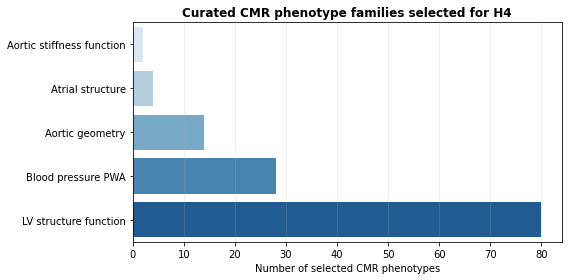

In [124]:


# Plot family counts
if len(selected_family_table):
    fig, ax = plt.subplots(figsize=(8, max(4, 0.45 * len(selected_family_table) + 1)))
    tmp = selected_family_table.sort_values("n_features", ascending=True)
    # remove "_" from family names for cleaner plotting
    tmp["family"] = tmp["family"].str.replace("_", " ")
    # seaborn barplot
    sns.barplot(
        x="n_features",
        y="family",
        data=tmp,
        ax=ax,
        palette=sns.color_palette("Blues", n_colors=len(tmp)),
    )
    ax.set_xlabel("Number of selected CMR phenotypes")
    ax.set_title("Curated CMR phenotype families selected for H4", fontweight="bold")
    ax.grid(axis="x", alpha=0.25)
    # no y label
    ax.set_ylabel("")
    fig.tight_layout()
    savefig(fig, FIGDIR / "H4_Fig01_CMR_selected_family_counts")
    plt.show()

### Violin plots : CORI high vs low MRI comparison

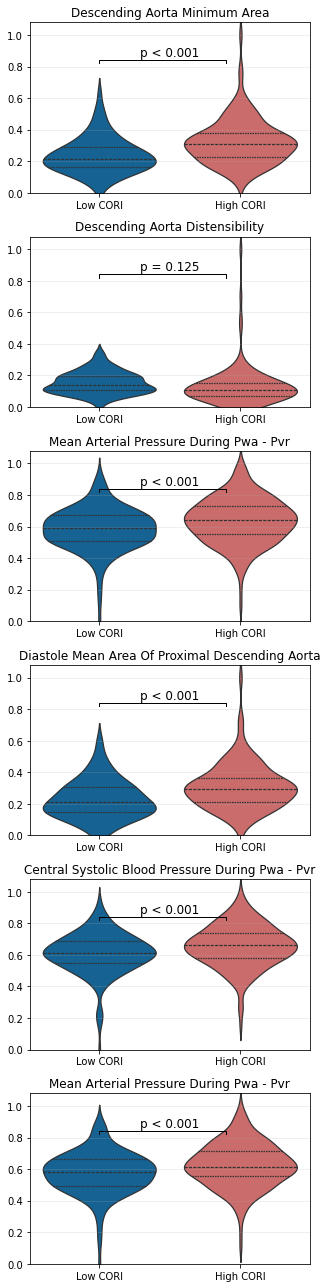

In [144]:
# Violin plots: top features overall and by family

from scipy.stats import ttest_ind

def cmr_violin_grid(df, features, score_col, group_col, figdir, prefix="H4"):

    df = df.copy()
    feats = [f for f in features if f in df.columns][:6]

    if not feats:
        return

    n = len(feats)
    fig, axes = plt.subplots(n, 1, figsize=(4.5, 3*n), squeeze=False)

    for ax, feat in zip(axes.ravel(), feats):
        d = (
            df[[feat, group_col]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .copy()
        )

        # Scale to [0,1]
        d[feat] = (d[feat] - d[feat].min()) / (d[feat].max() - d[feat].min())

        g0 = pd.to_numeric(
            d.loc[d[group_col] == 0, feat], errors="coerce"
        ).dropna().values
        g1 = pd.to_numeric(
            d.loc[d[group_col] == 1, feat], errors="coerce"
        ).dropna().values

        sns.violinplot(
            data=[g0, g1],
            ax=ax,
            inner="quartile",
            palette=[color_dict["dark_blue1"], color_dict["dark_red2"]],
        )

        # Welch's t-test
        if len(g0) > 1 and len(g1) > 1:
            _, p = ttest_ind(g0, g1, equal_var=False)
            p_label = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
            y = 0.82
            h = 0.02
            # significance bar
            ax.plot([0, 0, 0.9, 0.9], [y, y+h, y+h, y], c="black", lw=1)

            # p-value
            ax.text(0.5, y+h+0.005, p_label, ha="center", va="bottom", fontsize=12,)

        ax.set_ylim(0, 1.08)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Low CORI", "High CORI"])
        ax.set_title(feat.split("|")[0].title(), fontsize=12)
        ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()
    savefig(fig, Path(figdir) / f"{prefix}_CMR_top_violin_grid")
    plt.show()
    
top_overall = cmr_assoc.sort_values(["Spearman_p", "Welch_p"], na_position="last").head(TOP_FEATURES_FOR_OVERALL_PLOTS)["feature"].tolist()
cmr_violin_grid(primary_cmr_df, top_overall, "CORI_score", "CORI_high_risk", FIGDIR, prefix="H4_curated_overall")


## Corr heatmap: MRI to MRI 

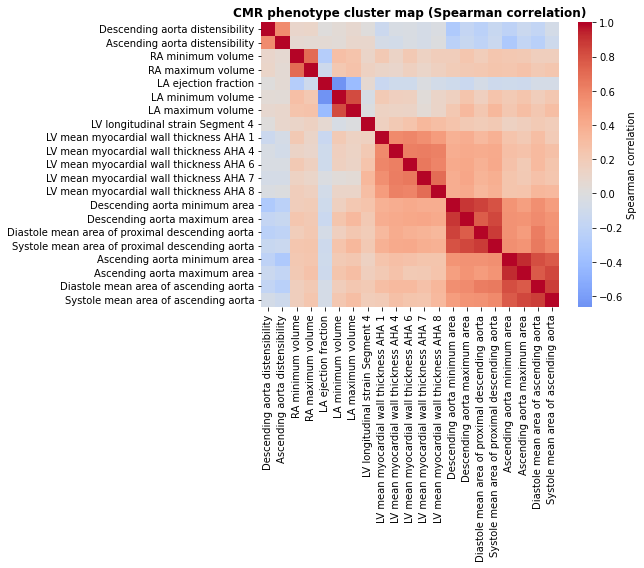

In [135]:

def cmr_cluster_map(df, features, figdir, prefix="H4"):
    
    # df[features].info()
    # remove features with "| Array 1" or "| Array 2" in the name
    features = [f for f in features if "| Array" not in f]
    
    # split "|" from feature names for cleaner plotting
    df = df.copy()
    df.columns = [c.split("|")[0].strip() for c in df.columns]
    features = [f.split("|")[0].strip() for f in features]
    
    feats = [f for f in features if f in df.columns][:30]
    if len(feats) < 3:
        return
    X = df[feats].apply(pd.to_numeric, errors="coerce")
    X = X.fillna(X.median())
    corr = X.corr(method="spearman")
    try:
        dist = 1 - np.abs(corr.values)
        Z = linkage(dist[np.triu_indices_from(dist, k=1)], method="average")
        order = leaves_list(Z)
    except Exception:
        order = np.arange(len(feats))
    corr2 = corr.iloc[order, order]
    
    fig, ax = plt.subplots(figsize=(9,8))
    # use seaborn
    sns.heatmap(corr2, ax=ax, cmap="coolwarm", center=0, cbar_kws={"label": "Spearman correlation"},
                # reotate x tick labels
                xticklabels=True, yticklabels=True)

    # ax.tick_params(axis="x", labelrotation=15)

    # ax.set_xticks(range(len(corr2))); ax.set_xticklabels(corr2.columns, rotation=45, fontsize=8)
    # ax.set_yticks(range(len(corr2))); ax.set_yticklabels(corr2.index, fontsize=8)
    ax.set_title("CMR phenotype cluster map (Spearman correlation)", fontweight="bold")
    fig.tight_layout()
    savefig(fig, Path(figdir)/f"{prefix}_CMR_cluster_map")
    plt.show()
    

# Top features per family for supplemental inspection
top_by_family = []
for fam, g in cmr_assoc.groupby("family", dropna=False):
    top_by_family.extend(g.sort_values("Spearman_p", na_position="last").head(TOP_FEATURES_PER_FAMILY_FOR_TABLES)["feature"].tolist())
top_by_family = list(dict.fromkeys(top_by_family))
pd.DataFrame({"feature": top_by_family}).to_csv(TABLEDIR / "H4_Table_09_top_CMR_features_by_family_for_plots.csv", index=False)

# Cluster map on top curated features only
cmr_cluster_map(primary_cmr_df, top_by_family[:30], FIGDIR, prefix="H4_curated_family_selected")


## Volcano-style plot with family coloring

In [145]:
 
# plot_df = cmr_assoc.copy()
# plot_df["minus_log10_p"] = -np.log10(plot_df["Spearman_p"].replace(0, np.nan))

# families = sorted(plot_df["family"].fillna("Unclassified").unique())
# fam_to_num = {f: i for i, f in enumerate(families)}
# plot_df["_fam_num"] = plot_df["family"].fillna("Unclassified").map(fam_to_num)

# fig, ax = plt.subplots(figsize=(8.2, 5.6))
# sc = ax.scatter(
#     plot_df["Spearman_r"],
#     plot_df["minus_log10_p"],
#     c=plot_df["_fam_num"],
#     alpha=0.78,
#     s=42,
# )

# for _, r in plot_df.sort_values("Spearman_p").head(10).iterrows():
#     label = str(r.get("clean_label", r["feature"]))[:38]
#     ax.text(r["Spearman_r"], r["minus_log10_p"], label, fontsize=7)

# ax.axvline(0, color="black", linewidth=1)
# ax.set_xlabel("Spearman correlation with CORI")
# ax.set_ylabel("-log10(p)")
# ax.set_title("Curated CMR phenotypes associated with locked H1 CORI", fontweight="bold")
# ax.grid(alpha=0.25)

# # Compact legend by family
# handles = []
# for fam, num in fam_to_num.items():
#     handles.append(plt.Line2D([0], [0], marker='o', linestyle='', label=fam, markersize=6))
# ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, frameon=False)

# fig.tight_layout()
# savefig(fig, FIGDIR / "H4_Fig02_CMR_volcano_curated_by_family")
# plt.show()


Adjusted CMR regressions on curated feature set
One-age clinical policy: age variable=None; covariates=[]

Adjusted CMR regressions on curated features
                                                    feature   N  beta_per_1SD_CORI       se    ci_low   ci_high            p        q                                        clean_label                    family
           Mean arterial pressure during PWA - PVR| Array 0 380           0.254556 0.049740  0.157065  0.352047 3.092499e-07 0.000003            Mean arterial pressure during PWA - PVR        Blood_pressure_PWA
                              Descending aorta minimum area 219           0.327247 0.064147  0.201519  0.452974 3.368973e-07 0.000003                      Descending aorta minimum area           Aortic_geometry
  Central systolic blood pressure during PWA - PVR| Array 0 380           0.244068 0.049879  0.146305  0.341831 9.920452e-07 0.000007   Central systolic blood pressure during PWA - PVR        Blood_pressure_PWA
   

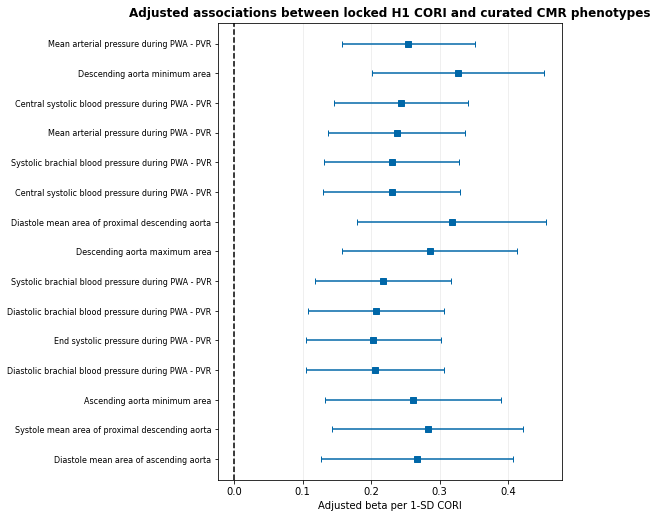

{
  "notebook": "H4",
  "purpose": "Load H1 locked CORI and evaluate explicitly curated visit-aware CMR phenotype families; no CORI retraining.",
  "H1_CORI_bundle": "figures/H1_CORI_LOCKED_MODEL_v13/models/CORI_locked_model_bundle.pkl",
  "CARDIAC_MRI_CSV": "data/cardiac_mri.csv",
  "primary_CMR_rows": 820,
  "primary_CMR_unique_eids": 410,
  "CMR_feature_families": {
    "LV_structure_function": {
      "include": [
        "\\bleft ventricular\\b",
        "\\bLV\\b",
        "end[- ]diastolic volume",
        "end[- ]systolic volume",
        "stroke volume",
        "ejection fraction",
        "cardiac output",
        "myocardial mass",
        "left ventricle"
      ],
      "exclude": [
        "image",
        "date",
        "quality",
        "path"
      ]
    },
    "RV_structure_function": {
      "include": [
        "\\bright ventricular\\b",
        "\\bRV\\b",
        "right ventricle",
        "end[- ]diastolic volume",
        "end[- ]systolic volume",
        "str

In [147]:
logger.section("Adjusted CMR regressions on curated feature set")

clinical_covars, AGE_COL = one_age_covars(primary_cmr_df, logger=logger)

# Do adjusted regressions on top curated features, not random numeric columns.
if len(cmr_assoc):
    features_for_reg = (
        cmr_assoc.sort_values(["Spearman_p", "Welch_p"], na_position="last")
        .head(TOP_FEATURES_FOR_OVERALL_PLOTS)["feature"]
        .tolist()
    )
else:
    features_for_reg = []

pd.DataFrame({"feature_for_adjusted_regression": features_for_reg}).to_csv(
    TABLEDIR / "H4_Table_10_features_entering_adjusted_CMR_regressions.csv",
    index=False,
)

reg_table = adjusted_linear_regressions(
    primary_cmr_df,
    "CORI_score",
    features_for_reg,
    clinical_covars,
    TABLEDIR,
    prefix="H4_curated",
)

if len(reg_table):
    reg_table = reg_table.merge(
        cmr_inventory[["column", "clean_label", "family"]].rename(columns={"column": "feature"}),
        on="feature",
        how="left",
    )
    reg_table = reg_table.sort_values("p", na_position="last")
    reg_table.to_csv(TABLEDIR / "H4_Table_11_adjusted_CMR_regressions_curated_with_family.csv", index=False)

logger.df("Adjusted CMR regressions on curated features", reg_table.head(30) if len(reg_table) else reg_table)

# Forest-style adjusted beta plot
if len(reg_table):
    fp = (
        reg_table.dropna(subset=["beta_per_1SD_CORI", "ci_low", "ci_high"])
        .sort_values("p")
        .head(15)
        .iloc[::-1]
        .copy()
    )
    if len(fp):
        labels = fp["clean_label"].fillna(fp["feature"]).astype(str).str.slice(0, 55)
        fig, ax = plt.subplots(figsize=(8.0, max(4, 0.42 * len(fp) + 1)))
        y = np.arange(len(fp))
        ax.errorbar(
            fp["beta_per_1SD_CORI"],
            y,
            xerr=[
                fp["beta_per_1SD_CORI"] - fp["ci_low"],
                fp["ci_high"] - fp["beta_per_1SD_CORI"],
            ],
            fmt="s",
            capsize=3,
            color=color_dict["dark_blue1"]
        )
        ax.axvline(0, color="black", linestyle="--")
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel("Adjusted beta per 1-SD CORI")
        ax.set_title("Adjusted associations between locked H1 CORI and curated CMR phenotypes", fontweight="bold")
        ax.grid(axis="x", alpha=0.25)
        fig.tight_layout()
        savefig(fig, FIGDIR / "H4_Fig03_adjusted_CMR_beta_forest_curated")
        plt.show()

manifest = {
    "notebook": "H4",
    "purpose": "Load H1 locked CORI and evaluate explicitly curated visit-aware CMR phenotype families; no CORI retraining.",
    "H1_CORI_bundle": str(H1_CORI_BUNDLE),
    "CARDIAC_MRI_CSV": str(CARDIAC_MRI_CSV),
    "primary_CMR_rows": len(primary_cmr_df),
    "primary_CMR_unique_eids": int(primary_cmr_df.eid.nunique()) if "eid" in primary_cmr_df.columns else None,
    "CMR_feature_families": CMR_FEATURE_FAMILIES,
    "PRIMARY_CMR_FAMILIES": PRIMARY_CMR_FAMILIES,
    "EXACT_CMR_VARIABLES": EXACT_CMR_VARIABLES,
    "USER_CMR_KEYWORDS": USER_CMR_KEYWORDS,
    "MIN_CMR_NONMISSING": MIN_CMR_NONMISSING,
    "MIN_CMR_UNIQUE_VALUES": MIN_CMR_UNIQUE_VALUES,
    "n_selected_CMR_features": len(selected_cmr_cols),
    "selected_CMR_features": selected_cmr_cols,
    "clinical_covariates_for_adjusted_regression": clinical_covars,
    "age_variable": AGE_COL,
}

(OUTDIR / "H4_output_manifest.json").write_text(json.dumps(manifest, indent=2, default=str), encoding="utf-8")
logger.log(json.dumps(manifest, indent=2, default=str))

# Handcrafted Retinal features

In [148]:
# ============================================================
# H4 PRE-CELL — Merge locked H1 handcrafted HCORI features into cmr_merged
# ============================================================

logger.section("Merging locked H1 handcrafted HCORI features into H4 CMR dataframe")

# ------------------------------------------------------------
# 1. Required locked HCORI features from the H1 model
# ------------------------------------------------------------
HCORI_LOCKED_FEATURES = [
    "HC_vessel_fundus_ring_125_175STD_branch_length",
    "HC_vessel_fundus_ring_125_175STD_branch_distance",
    "HC_vessel_fundus_ring_125_175pixel_degree_3",
    "HC_vein_fundus_ring_125_175total_connected_pixels",
    "HC_vein_fundus_ring_125_175pixel_degree_2",
]


# ------------------------------------------------------------
# 2. Check H4 dataframe
# ------------------------------------------------------------
if "cmr_merged" not in globals():
    raise ValueError("cmr_merged is not defined. Run the earlier H4 CMR merge cells first.")

if "eid" not in cmr_merged.columns:
    raise ValueError("cmr_merged does not contain an eid column.")

cmr_merged = cmr_merged.copy()
cmr_merged["eid"] = _clean_id(cmr_merged["eid"])

already_present = [c for c in HCORI_LOCKED_FEATURES if c in cmr_merged.columns]
missing_now = [c for c in HCORI_LOCKED_FEATURES if c not in cmr_merged.columns]

logger.log(f"HCORI locked features already present in cmr_merged: {len(already_present)} / {len(HCORI_LOCKED_FEATURES)}")

if len(missing_now) == 0:
    logger.log("All locked HCORI handcrafted features are already present. No merge needed.")

else:
    logger.log("Missing HCORI features before merge:")
    for c in missing_now:
        logger.log(f"  - {c}")

    # ------------------------------------------------------------
    # 3. Search likely H1 handcrafted feature files
    # ------------------------------------------------------------
    h1_roots = [
        H1_LOCKED_OUTDIR,
        H1_HCORI_OUTDIR,
        BASE_OUTDIR,
    ]

    candidate_files = []

    # Explicit likely files first
    explicit_candidates = [
        H1_HCORI_OUTDIR / "tables" / "H1_HCORI_handcrafted_features.csv",
        H1_HCORI_OUTDIR / "tables" / "HCORI_handcrafted_features.csv",
        H1_HCORI_OUTDIR / "tables" / "handcrafted_features.csv",
        H1_LOCKED_OUTDIR / "tables" / "H1_HCORI_handcrafted_features.csv",
        H1_LOCKED_OUTDIR / "tables" / "handcrafted_features.csv",
    ]

    candidate_files.extend([p for p in explicit_candidates if p.exists()])

    # Broad recursive search for CSV/parquet files that may contain handcrafted features
    search_patterns = [
        "*handcrafted*.csv",
        "*HCORI*.csv",
        "*feature*.csv",
        "*handcrafted*.parquet",
        "*HCORI*.parquet",
        "*feature*.parquet",
    ]

    for root in h1_roots:
        if root.exists():
            for pat in search_patterns:
                candidate_files.extend(list(root.rglob(pat)))

    # Deduplicate while preserving order
    seen = set()
    candidate_files_unique = []
    for p in candidate_files:
        ps = str(p).lower()
        if ps not in seen:
            seen.add(ps)
            candidate_files_unique.append(p)

    logger.log(f"Candidate handcrafted feature files found: {len(candidate_files_unique)}")

    # ------------------------------------------------------------
    # 4. Identify file containing the locked HCORI features
    # ------------------------------------------------------------
    feature_file = None
    feature_df = None
    best_match = None

    for p in candidate_files_unique:
        try:
            if p.suffix.lower() == ".csv":
                # Read header first
                cols = pd.read_csv(p, nrows=0).columns.tolist()
            elif p.suffix.lower() == ".parquet":
                cols = pd.read_parquet(p).columns.tolist()
            else:
                continue

            if "eid" not in cols:
                continue

            n_match = sum(c in cols for c in HCORI_LOCKED_FEATURES)

            if best_match is None or n_match > best_match[0]:
                best_match = (n_match, p, cols)

            if n_match == len(HCORI_LOCKED_FEATURES):
                feature_file = p
                break

        except Exception:
            continue

    if feature_file is None:
        msg = (
            "Could not find a handcrafted retinal feature file containing all locked HCORI features.\n\n"
        )

        if best_match is not None:
            msg += (
                f"Best partial match had {best_match[0]} / {len(HCORI_LOCKED_FEATURES)} features:\n"
                f"{best_match[1]}\n\n"
            )

        msg += (
            "You need to locate the H1 handcrafted feature table that has these columns:\n"
            + "\n".join([f"  - {c}" for c in HCORI_LOCKED_FEATURES])
            + "\n\n"
            "Once you find it, set feature_file manually like:\n"
            r'feature_file = Path(r"F:\path\to\your\handcrafted_features.csv")'
        )

        raise FileNotFoundError(msg)

    logger.log(f"Using handcrafted feature file: {feature_file}")

    # ------------------------------------------------------------
    # 5. Load the feature file
    # ------------------------------------------------------------
    if feature_file.suffix.lower() == ".csv":
        feature_df = pd.read_csv(feature_file, low_memory=False)
    elif feature_file.suffix.lower() == ".parquet":
        feature_df = pd.read_parquet(feature_file)
    else:
        raise ValueError(f"Unsupported feature file type: {feature_file}")

    if "eid" not in feature_df.columns:
        raise ValueError(f"Feature file does not contain eid column: {feature_file}")

    feature_df = feature_df.copy()
    feature_df["eid"] = _clean_id(feature_df["eid"])

    missing_in_feature_file = [c for c in HCORI_LOCKED_FEATURES if c not in feature_df.columns]
    if missing_in_feature_file:
        raise ValueError(
            "Feature file was selected but still lacks required HCORI features:\n"
            + "\n".join(missing_in_feature_file)
        )

    keep_cols = ["eid"] + HCORI_LOCKED_FEATURES

    # If multiple rows per eid exist, average numeric feature values.
    feature_keep = feature_df[keep_cols].copy()
    for c in HCORI_LOCKED_FEATURES:
        feature_keep[c] = pd.to_numeric(feature_keep[c], errors="coerce")

    feature_keep = (
        feature_keep
        .groupby("eid", as_index=False)[HCORI_LOCKED_FEATURES]
        .mean()
    )

    logger.log(f"Handcrafted feature table shape after eid aggregation: {feature_keep.shape}")

    # ------------------------------------------------------------
    # 6. Merge into cmr_merged
    # ------------------------------------------------------------
    n_before = len(cmr_merged)

    # Avoid duplicate columns if rerun
    cmr_merged = cmr_merged.drop(
        columns=[c for c in HCORI_LOCKED_FEATURES if c in cmr_merged.columns],
        errors="ignore"
    )

    cmr_merged = cmr_merged.merge(feature_keep, on="eid", how="left")

    n_after = len(cmr_merged)

    logger.log(f"cmr_merged rows before merge: {n_before}")
    logger.log(f"cmr_merged rows after merge:  {n_after}")

    # ------------------------------------------------------------
    # 7. QC after merge
    # ------------------------------------------------------------
    qc_rows = []
    for c in HCORI_LOCKED_FEATURES:
        qc_rows.append({
            "feature": c,
            "present_after_merge": c in cmr_merged.columns,
            "nonmissing_after_merge": int(cmr_merged[c].notna().sum()) if c in cmr_merged.columns else 0,
            "missing_after_merge": int(cmr_merged[c].isna().sum()) if c in cmr_merged.columns else len(cmr_merged),
        })

    hcori_feature_merge_qc = pd.DataFrame(qc_rows)

    logger.df("HCORI handcrafted feature merge QC", hcori_feature_merge_qc)

    try:
        hcori_feature_merge_qc.to_csv(TABLEDIR / "H4_HCORI_handcrafted_feature_merge_QC.csv", index=False)
    except Exception:
        pass

    still_missing_cols = [c for c in HCORI_LOCKED_FEATURES if c not in cmr_merged.columns]
    if still_missing_cols:
        raise ValueError(
            "After merge, these locked HCORI feature columns are still missing:\n"
            + "\n".join(still_missing_cols)
        )

    nonmissing_any = cmr_merged[HCORI_LOCKED_FEATURES].notna().any(axis=1).sum()
    nonmissing_all = cmr_merged[HCORI_LOCKED_FEATURES].notna().all(axis=1).sum()

    logger.log(f"H4 rows with at least one HCORI feature non-missing: {nonmissing_any}")
    logger.log(f"H4 rows with all HCORI features non-missing:          {nonmissing_all}")

    if nonmissing_any == 0:
        raise ValueError(
            "The handcrafted feature columns were merged, but all values are missing.\n"
            "This usually means eid values do not overlap between cmr_merged and the H1 handcrafted feature table."
        )

logger.log("HCORI handcrafted feature merge pre-cell complete. Now rerun the H4 HCORI analysis cell.")


Merging locked H1 handcrafted HCORI features into H4 CMR dataframe
HCORI locked features already present in cmr_merged: 0 / 5
Missing HCORI features before merge:
  - HC_vessel_fundus_ring_125_175STD_branch_length
  - HC_vessel_fundus_ring_125_175STD_branch_distance
  - HC_vessel_fundus_ring_125_175pixel_degree_3
  - HC_vein_fundus_ring_125_175total_connected_pixels
  - HC_vein_fundus_ring_125_175pixel_degree_2
Candidate handcrafted feature files found: 57
Using handcrafted feature file: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/tables/H1_handcrafted_subject_level_features_cached.csv
Handcrafted feature table shape after eid aggregation: (54060, 6)
cmr_merged rows before merge: 1324
cmr_merged rows after merge:  1324

HCORI handcrafted feature merge QC
                                          feature  present_after_merge  nonmissing_after_merge  missing_after_merge
   HC_vessel_fundus_ring_125_175STD_branch_length                 True                    1224                 

In [ ]:
# Violin plots: top features overall and by family

from scipy.stats import ttest_ind

def cmr_violin_grid(df, features, score_col, group_col, figdir, prefix="H4"):

    df = df.copy()
    feats = [f for f in features if f in df.columns][:6]

    if not feats:
        return

    n = len(feats)
    fig, axes = plt.subplots(n, 1, figsize=(4.5, 3*n), squeeze=False)

    for ax, feat in zip(axes.ravel(), feats):
        d = (
            df[[feat, group_col]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .copy()
        )

        # Scale to [0,1]
        d[feat] = (d[feat] - d[feat].min()) / (d[feat].max() - d[feat].min())

        g0 = pd.to_numeric(
            d.loc[d[group_col] == 0, feat], errors="coerce"
        ).dropna().values
        g1 = pd.to_numeric(
            d.loc[d[group_col] == 1, feat], errors="coerce"
        ).dropna().values

        sns.violinplot(
            data=[g0, g1],
            ax=ax,
            inner="quartile",
            palette=[color_dict["dark_blue1"], color_dict["dark_red2"]],
        )

        # Welch's t-test
        if len(g0) > 1 and len(g1) > 1:
            _, p = ttest_ind(g0, g1, equal_var=False)
            p_label = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
            y = 0.82
            h = 0.02
            # significance bar
            ax.plot([0, 0, 0.9, 0.9], [y, y+h, y+h, y], c="black", lw=1)

            # p-value
            ax.text(0.5, y+h+0.005, p_label, ha="center", va="bottom", fontsize=12,)

        ax.set_ylim(0, 1.08)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Low CORI", "High CORI"])
        ax.set_title(feat.split("|")[0].title(), fontsize=12)
        ax.grid(axis="y", alpha=0.25)

    fig.tight_layout()
    savefig(fig, Path(figdir) / f"{prefix}_CMR_top_violin_grid")
    plt.show()
    
top_overall = cmr_assoc.sort_values(["Spearman_p", "Welch_p"], na_position="last").head(TOP_FEATURES_FOR_OVERALL_PLOTS)["feature"].tolist()
cmr_violin_grid(primary_cmr_df, top_overall, "CORI_score", "CORI_high_risk", FIGDIR, prefix="H4_curated_overall")


In [150]:
# ============================================================
# H4 PRE-CELL — Merge locked H1 handcrafted HCORI features into cmr_merged
# ============================================================

HCORI_LOCKED_FEATURES = [
    "HC_vessel_fundus_ring_125_175STD_branch_length",
    "HC_vessel_fundus_ring_125_175STD_branch_distance",
    "HC_vessel_fundus_ring_125_175pixel_degree_3",
    "HC_vein_fundus_ring_125_175total_connected_pixels",
    "HC_vein_fundus_ring_125_175pixel_degree_2",
]

hc_features_cached = load_cached_handcrafted_features_exact(H1_HCORI_CACHED_FEATURES, id_col_name="eid")

cmr_merged = cmr_merged.copy()
cmr_merged["eid"] = _clean_id(cmr_merged["eid"])
cmr_merged = cmr_merged.drop(columns=HCORI_LOCKED_FEATURES, errors="ignore").merge(
    hc_features_cached[["eid"] + HCORI_LOCKED_FEATURES], on="eid", how="left"
)

logger.log(f"HCORI features merged: {cmr_merged[HCORI_LOCKED_FEATURES].notna().any(axis=1).sum()} / {len(cmr_merged)} rows matched")


Cached handcrafted subjects loaded: 54060 | numeric feature columns: 455
HCORI features merged: 1224 / 1324 rows matched



H4 handcrafted retinal model: locked HCORI vs curated CMR phenotypes
Using H4 dataframe: cmr_merged, shape=(1324, 254)
HCORI risk-score CSV not found. Loading locked model bundle from: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/models/HCORI_locked_handcrafted_model_bundle.pkl
Locked HCORI feature columns expected: 5
Locked HCORI feature columns present in H4: 5
Locked HCORI feature columns missing in H4: 0
Generated HCORI scores using locked H1 model bundle: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/models/HCORI_locked_handcrafted_model_bundle.pkl
HCORI high-risk threshold used: 2.51603e-32 [H4 median because no locked threshold found in bundle]
Saved generated H4 HCORI scores to: figures/H4_CMR_locked_CORI_v13/tables/H4_generated_HCORI_scores_from_locked_H1_bundle.csv
HCORI source used: figures/H1_CORI_LOCKED_MODEL_v13/handcrafted_HCORI/models/HCORI_locked_handcrafted_model_bundle.pkl
H4 rows before HCORI merge: 1324
H4 rows after HCORI merge:  1324
Number of curated

NameError: name 'Path' is not defined

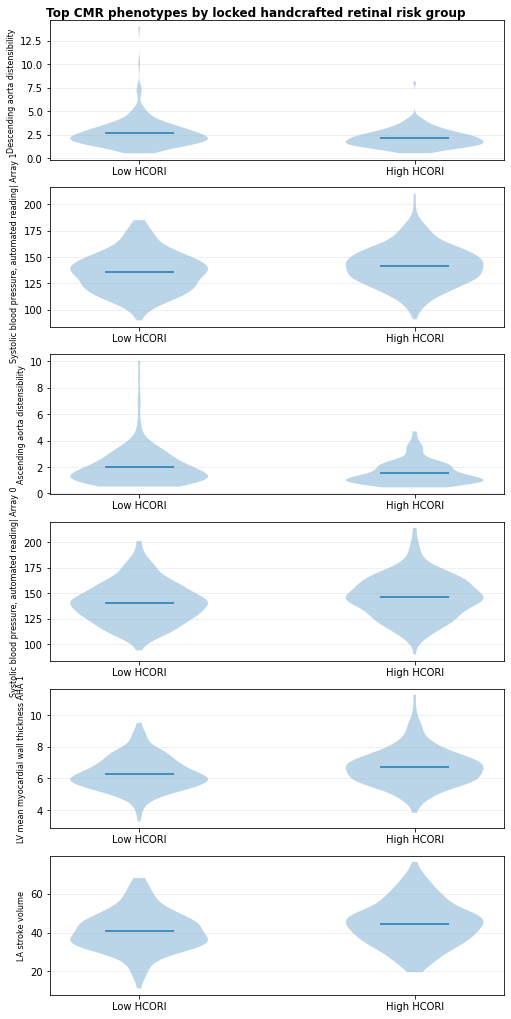

In [ ]:
# ============================================================
# H4 — Handcrafted retinal model (HCORI) association with curated CMR phenotypes
# ============================================================

# 1. Locate the active H4 CMR dataframe
candidate_h4_df_names = [
    "h4_df",
    "cmr_analysis_df",
    "cmr_merged",
    "merged_cmr",
    "cmr_df",
    "analysis_df",
]

H4_DF_NAME = None
for nm in candidate_h4_df_names:
    if nm in globals() and isinstance(globals()[nm], pd.DataFrame):
        if "eid" in globals()[nm].columns:
            H4_DF_NAME = nm
            break
        
h4 = globals()[H4_DF_NAME].copy()
h4["eid"] = _clean_id(h4["eid"])


# ------------------------------------------------------------
# 2. Load locked HCORI scores from H1
# ------------------------------------------------------------
# Preferred path:
#   1) If H1 already exported subject-level HCORI scores, load them.
#   2) Otherwise, load the locked H1 handcrafted model bundle and score H4 directly.
#
# Important:
#   - This does NOT retrain HCORI.
#   - It uses the locked H1 model bundle.
#   - H4 must contain the handcrafted retinal feature columns used by H1.

try:
    import joblib
except Exception:
    joblib = None


# -----------------------------
# 2A. Candidate H1 output roots
# -----------------------------
h1_candidate_roots = [
    H1_LOCKED_OUTDIR,
    BASE_OUTDIR,
    BASE_OUTDIR.parent / "H1_CORI_LOCKED_MODEL_v13",
    BASE_OUTDIR.parent / "H1_CroydonTrain_AllOtherTest_publication_v4",
    BASE_OUTDIR.parent / "H1_CORI_locked_model_final_v13",
    H1_HCORI_OUTDIR,
]


# -----------------------------
# 2B. First try subject-level H1 HCORI score CSV
# -----------------------------
risk_score_candidates = []
for root in h1_candidate_roots:
    risk_score_candidates.extend([
        root / "tables" / "H1_HCORI_risk_scores_all_sets.csv",
        root / "tables" / "HCORI_risk_scores_all_sets.csv",
        root / "tables" / "H1_handcrafted_HCORI_risk_scores_all_sets.csv",
        root / "H1_HCORI_risk_scores_all_sets.csv",
    ])

risk_score_path = None
for p in risk_score_candidates:
    if Path(p).exists():
        risk_score_path = Path(p)
        break


# -----------------------------
# 2C. If CSV exists, load it
# -----------------------------
if risk_score_path is not None:

    hcori_scores = pd.read_csv(risk_score_path, low_memory=False)

    if "eid" not in hcori_scores.columns:
        raise ValueError(f"HCORI risk-score file lacks eid column: {risk_score_path}")

    hcori_scores["eid"] = _clean_id(hcori_scores["eid"])

    # Standardize expected HCORI column names.
    rename_map = {}
    for c in hcori_scores.columns:
        cl = str(c).lower()
        if cl in ["hcori_score", "handcrafted_score", "hcori_risk_score", "risk_score", "score"]:
            rename_map[c] = "HCORI_score"
        elif cl in ["hcori_high_risk", "handcrafted_high_risk", "high_risk"]:
            rename_map[c] = "HCORI_high_risk"
        elif cl in ["hcori_risk_tertile", "handcrafted_risk_tertile", "risk_tertile"]:
            rename_map[c] = "HCORI_risk_tertile"

    hcori_scores = hcori_scores.rename(columns=rename_map)

    if "HCORI_score" not in hcori_scores.columns:
        raise ValueError(
            f"HCORI risk-score file found but no HCORI_score-like column detected.\n"
            f"File: {risk_score_path}\n"
            f"Columns available: {hcori_scores.columns.tolist()[:80]}"
        )

    hcori_source_used = str(risk_score_path)
    logger.log(f"Loaded HCORI subject-level risk scores from: {risk_score_path}")


# -----------------------------
# 2D. Otherwise, load locked H1 HCORI model bundle and score H4
# -----------------------------
else:

    model_bundle_candidates = []
    for root in h1_candidate_roots:
        model_bundle_candidates.extend([
            root / "models" / "HCORI_locked_handcrafted_model_bundle.pkl",
            root / "handcrafted_HCORI" / "models" / "HCORI_locked_handcrafted_model_bundle.pkl",
            root / "models" / "HCORI_model_bundle.pkl",
            root / "models" / "handcrafted_HCORI_model_bundle.pkl",
        ])

    model_bundle_path = None
    for p in model_bundle_candidates:
        if Path(p).exists():
            model_bundle_path = Path(p)
            break

    if model_bundle_path is None:
        raise FileNotFoundError(
            "Could not find either the H1 HCORI risk-score CSV or the locked HCORI model bundle.\n\n"
            "Expected either:\n"
            "  tables/H1_HCORI_risk_scores_all_sets.csv\n"
            "or:\n"
            f"  {H1_HCORI_BUNDLE}"
        )

    logger.log(f"HCORI risk-score CSV not found. Loading locked model bundle from: {model_bundle_path}")

    if joblib is not None:
        try:
            hcori_bundle = joblib.load(model_bundle_path)
        except Exception:
            with open(model_bundle_path, "rb") as f:
                hcori_bundle = pickle.load(f)
    else:
        with open(model_bundle_path, "rb") as f:
            hcori_bundle = pickle.load(f)

    # -----------------------------
    # Helper: inspect bundle safely
    # -----------------------------
    def _bundle_get(bundle, candidate_keys, default=None):
        if isinstance(bundle, dict):
            for k in candidate_keys:
                if k in bundle:
                    return bundle[k]
        return default

    # Try to find model/pipeline object
    hcori_model = _bundle_get(
        hcori_bundle,
        [
            "model",
            "pipeline",
            "estimator",
            "clf",
            "classifier",
            "regressor",
            "best_model",
            "final_model",
            "locked_model",
            "hcori_model",
            "HCORI_model",
        ],
        default=None,
    )

    # If the bundle itself is the model/pipeline
    if hcori_model is None and hasattr(hcori_bundle, "predict"):
        hcori_model = hcori_bundle

    if hcori_model is None:
        raise ValueError(
            "Loaded HCORI bundle, but could not find a model/pipeline object.\n"
            f"Bundle type: {type(hcori_bundle)}\n"
            f"Bundle keys: {list(hcori_bundle.keys()) if isinstance(hcori_bundle, dict) else 'not a dict'}"
        )

    # Try to find feature list
    hcori_feature_cols = _bundle_get(
        hcori_bundle,
        [
            "feature_cols",
            "features",
            "feature_names",
            "selected_features",
            "selected_feature_names",
            "handcrafted_features",
            "handcrafted_feature_cols",
            "model_features",
            "train_features",
            "x_cols",
            "X_cols",
            "columns",
        ],
        default=None,
    )

    # Fallback: sklearn objects often store feature_names_in_
    if hcori_feature_cols is None and hasattr(hcori_model, "feature_names_in_"):
        hcori_feature_cols = list(hcori_model.feature_names_in_)

    if hcori_feature_cols is None:
        raise ValueError(
            "Could not identify the handcrafted retinal feature columns used by the locked HCORI model.\n"
            "Open the bundle and check which key stores the feature names.\n\n"
            f"Bundle type: {type(hcori_bundle)}\n"
            f"Bundle keys: {list(hcori_bundle.keys()) if isinstance(hcori_bundle, dict) else 'not a dict'}"
        )

    hcori_feature_cols = list(hcori_feature_cols)

    # Build X for H4 using the locked H1 feature order
    missing_hcori_features = [c for c in hcori_feature_cols if c not in h4.columns]
    present_hcori_features = [c for c in hcori_feature_cols if c in h4.columns]

    logger.log(f"Locked HCORI feature columns expected: {len(hcori_feature_cols)}")
    logger.log(f"Locked HCORI feature columns present in H4: {len(present_hcori_features)}")
    logger.log(f"Locked HCORI feature columns missing in H4: {len(missing_hcori_features)}")

    if len(missing_hcori_features) > 0:
        logger.log("First missing HCORI features: " + ", ".join(missing_hcori_features[:25]))

    if len(present_hcori_features) == 0:
        raise ValueError(
            "None of the locked H1 handcrafted HCORI features are present in the H4 dataframe.\n"
            "This means H4 currently has CMR variables but not the retinal handcrafted features needed to score HCORI.\n"
            "You need to merge the H1 handcrafted retinal feature table into H4 by eid before this cell."
        )

    # Create X with all expected columns; missing columns become NaN.
    # This is safe only if the locked pipeline/model includes an imputer.
    X_h4_hcori = pd.DataFrame(index=h4.index)
    for c in hcori_feature_cols:
        if c in h4.columns:
            X_h4_hcori[c] = pd.to_numeric(h4[c], errors="coerce")
        else:
            X_h4_hcori[c] = np.nan

    # Optional separate preprocessing objects stored in bundle
    hcori_imputer = _bundle_get(hcori_bundle, ["imputer", "median_imputer", "feature_imputer"], default=None)
    hcori_scaler = _bundle_get(hcori_bundle, ["scaler", "standard_scaler", "feature_scaler"], default=None)
    hcori_preprocessor = _bundle_get(hcori_bundle, ["preprocessor", "preprocess", "transformer"], default=None)

    X_for_pred = X_h4_hcori.copy()

    # If model is not a full pipeline, apply separately saved transforms if present.
    try:
        if hcori_preprocessor is not None:
            X_for_pred = hcori_preprocessor.transform(X_for_pred)

        if hcori_imputer is not None:
            X_for_pred = hcori_imputer.transform(X_for_pred)

        if hcori_scaler is not None:
            X_for_pred = hcori_scaler.transform(X_for_pred)
    except Exception as e:
        raise RuntimeError(
            "Failed while applying preprocessing objects from the HCORI bundle.\n"
            f"Error: {e}"
        )

    # Generate locked HCORI score

    # ------------------------------------------------------------
    # Generate locked HCORI score
    # ------------------------------------------------------------
    try:
        # lifelines CoxPHFitter case
        if hasattr(hcori_model, "predict_partial_hazard"):
            # Cox partial hazard is the natural locked risk score.
            # Higher value = higher predicted hazard/risk.
            hcori_score = np.ravel(hcori_model.predict_partial_hazard(X_for_pred))

        elif hasattr(hcori_model, "predict_log_partial_hazard"):
            # Alternative Cox score. Higher value = higher predicted log hazard/risk.
            hcori_score = np.ravel(hcori_model.predict_log_partial_hazard(X_for_pred))

        # sklearn classifier case
        elif hasattr(hcori_model, "predict_proba"):
            proba = hcori_model.predict_proba(X_for_pred)
            if proba.ndim == 2 and proba.shape[1] >= 2:
                hcori_score = proba[:, 1]
            else:
                hcori_score = np.ravel(proba)

        # sklearn margin-based model case
        elif hasattr(hcori_model, "decision_function"):
            hcori_score = np.ravel(hcori_model.decision_function(X_for_pred))

        # generic sklearn regressor/classifier fallback
        elif hasattr(hcori_model, "predict"):
            hcori_score = np.ravel(hcori_model.predict(X_for_pred))

        else:
            raise ValueError(
                "HCORI model has no supported scoring method. "
                "Expected predict_partial_hazard, predict_log_partial_hazard, "
                "predict_proba, decision_function, or predict."
            )

    except Exception as e:
        raise RuntimeError(
            "Failed to generate HCORI scores from the locked H1 model bundle.\n"
            "The HCORI features are present, so this is now likely a model/preprocessing format issue.\n\n"
            f"Model type: {type(hcori_model)}\n"
            f"Number of expected features: {len(hcori_feature_cols)}\n"
            f"Number missing in H4: {len(missing_hcori_features)}\n"
            f"First missing features: {missing_hcori_features[:30]}\n"
            f"X_for_pred type: {type(X_for_pred)}\n"
            f"X_for_pred shape: {getattr(X_for_pred, 'shape', None)}\n"
            f"Original error: {e}"
        )

    hcori_scores = pd.DataFrame({
        "eid": h4["eid"].values,
        "HCORI_score": hcori_score,
    })

    # Try to recover locked threshold from bundle.
    hcori_threshold = _bundle_get(
        hcori_bundle,
        [
            "HCORI_threshold",
            "hcori_threshold",
            "threshold",
            "high_risk_threshold",
            "risk_threshold",
            "median_threshold",
            "train_median_score",
            "development_median_score",
        ],
        default=None,
    )

    # If no threshold was saved, use median score within current H4 cohort as descriptive split.
    # This is not retraining the score, but it is a descriptive dichotomization.
    if hcori_threshold is None or not np.isfinite(float(hcori_threshold)):
        hcori_threshold = float(pd.Series(hcori_score).median())
        threshold_source = "H4 median because no locked threshold found in bundle"
    else:
        hcori_threshold = float(hcori_threshold)
        threshold_source = "locked threshold from H1 bundle"

    hcori_scores["HCORI_high_risk"] = (
        pd.to_numeric(hcori_scores["HCORI_score"], errors="coerce") > hcori_threshold
    ).astype(int)

    q33 = pd.Series(hcori_score).quantile(1 / 3)
    q67 = pd.Series(hcori_score).quantile(2 / 3)

    hcori_scores["HCORI_risk_tertile"] = pd.cut(
        pd.to_numeric(hcori_scores["HCORI_score"], errors="coerce"),
        bins=[-np.inf, q33, q67, np.inf],
        labels=[1, 2, 3],
    ).astype("Int64")

    hcori_source_used = str(model_bundle_path)

    logger.log(f"Generated HCORI scores using locked H1 model bundle: {model_bundle_path}")
    logger.log(f"HCORI high-risk threshold used: {hcori_threshold:.6g} [{threshold_source}]")

    # Save generated scores so future H4 runs can use CSV directly.
    generated_score_path = TABLEDIR / "H4_generated_HCORI_scores_from_locked_H1_bundle.csv"
    hcori_scores.to_csv(generated_score_path, index=False)
    logger.log(f"Saved generated H4 HCORI scores to: {generated_score_path}")


# -----------------------------
# 2E. Final cleanup, derive missing high-risk/tertile if needed, merge into H4
# -----------------------------
hcori_scores["eid"] = _clean_id(hcori_scores["eid"])
hcori_scores["HCORI_score"] = pd.to_numeric(hcori_scores["HCORI_score"], errors="coerce")

# If high-risk/tertile not available, derive descriptively from available scores.
if "HCORI_high_risk" not in hcori_scores.columns:
    if "set" in hcori_scores.columns:
        dev_mask = hcori_scores["set"].astype(str).str.lower().str.contains(
            "dev|train|croydon|birmingham",
            na=False,
        )
        ref = hcori_scores.loc[dev_mask, "HCORI_score"].dropna()
        if len(ref) < 20:
            ref = hcori_scores["HCORI_score"].dropna()
    else:
        ref = hcori_scores["HCORI_score"].dropna()

    med = ref.median()
    hcori_scores["HCORI_high_risk"] = (
        pd.to_numeric(hcori_scores["HCORI_score"], errors="coerce") > med
    ).astype(int)

if "HCORI_risk_tertile" not in hcori_scores.columns:
    ref = hcori_scores["HCORI_score"].dropna()
    q33 = ref.quantile(1 / 3)
    q67 = ref.quantile(2 / 3)

    hcori_scores["HCORI_risk_tertile"] = pd.cut(
        pd.to_numeric(hcori_scores["HCORI_score"], errors="coerce"),
        bins=[-np.inf, q33, q67, np.inf],
        labels=[1, 2, 3],
    ).astype("Int64")

hcori_keep = ["eid", "HCORI_score", "HCORI_high_risk", "HCORI_risk_tertile"]
hcori_keep = [c for c in hcori_keep if c in hcori_scores.columns]

hcori_scores = (
    hcori_scores[hcori_keep]
    .drop_duplicates("eid", keep="first")
    .copy()
)

h4_hc = h4.merge(hcori_scores, on="eid", how="inner")

logger.log(f"HCORI source used: {hcori_source_used}")
logger.log(f"H4 rows before HCORI merge: {len(h4)}")
logger.log(f"H4 rows after HCORI merge:  {len(h4_hc)}")

if len(h4_hc) == 0:
    raise ValueError(
        "HCORI scores were loaded/generated, but merge with H4 produced 0 rows.\n"
        "Check whether eid formatting differs between H4 and HCORI outputs."
    )

pd.DataFrame([{
    "H4_dataframe_used": H4_DF_NAME,
    "HCORI_source_used": hcori_source_used,
    "H4_N_before_HCORI_merge": len(h4),
    "H4_N_after_HCORI_merge": len(h4_hc),
    "HCORI_score_nonmissing": int(h4_hc["HCORI_score"].notna().sum()),
    "HCORI_high_risk_nonmissing": int(h4_hc["HCORI_high_risk"].notna().sum()) if "HCORI_high_risk" in h4_hc.columns else 0,
}]).to_csv(TABLEDIR / "H4_HCORI_merge_QC.csv", index=False)

# ------------------------------------------------------------
# 3. Determine curated CMR columns
# ------------------------------------------------------------
if "selected_cmr_cols" in globals():
    cmr_raw_cols = list(selected_cmr_cols)
elif "cmr_raw_cols" in globals():
    cmr_raw_cols = list(cmr_raw_cols)
elif "SELECTED_CMR_COLS" in globals():
    cmr_raw_cols = list(SELECTED_CMR_COLS)
elif "curated_cmr_cols" in globals():
    cmr_raw_cols = list(curated_cmr_cols)
else:
    # Conservative fallback: numeric CMR-like columns, excluding IDs/outcomes/scores.
    exclude_words = [
        "eid", "time", "event", "score", "risk", "tertile", "visit", "date",
        "status", "label", "split", "image", "path", "filename",
        "CORI", "HCORI", "MACE"
    ]
    cmr_raw_cols = []
    for c in h4_hc.columns:
        cl = str(c).lower()
        if any(w.lower() in cl for w in exclude_words):
            continue
        x = pd.to_numeric(h4_hc[c], errors="coerce")
        if x.notna().sum() >= 30 and x.nunique(dropna=True) > 5:
            cmr_raw_cols.append(c)

cmr_raw_cols = [c for c in cmr_raw_cols if c in h4_hc.columns]

if len(cmr_raw_cols) == 0:
    raise ValueError("No curated CMR columns found for HCORI analysis.")

logger.log(f"Number of curated CMR variables for HCORI analysis: {len(cmr_raw_cols)}")


# ------------------------------------------------------------
# 4. CMR preprocessing: preserve raw columns, create winsorized z-score columns
# ------------------------------------------------------------
h4_hc, cmr_z_cols_hc, z_to_raw_hc, cmr_hc_preprocess_qc = preprocess_cmr_features_for_hcori(
    h4_hc,
    cmr_raw_cols,
    winsorize=True,
    lower_q=0.01,
    upper_q=0.99,
    min_nonmissing=30,
)

cmr_hc_preprocess_qc.to_csv(TABLEDIR / "H4_HCORI_CMR_preprocessing_QC.csv", index=False)
logger.df("HCORI CMR preprocessing QC", cmr_hc_preprocess_qc)

if len(cmr_z_cols_hc) == 0:
    raise ValueError("No CMR variables survived preprocessing for HCORI analysis.")


# ------------------------------------------------------------
# 5. HCORI score scaling and group QC
# ------------------------------------------------------------
h4_hc["HCORI_score"] = pd.to_numeric(h4_hc["HCORI_score"], errors="coerce")
hc_mu = h4_hc["HCORI_score"].mean()
hc_sd = h4_hc["HCORI_score"].std(ddof=0)
if not np.isfinite(hc_sd) or hc_sd == 0:
    hc_sd = 1.0

h4_hc["HCORI_z"] = (h4_hc["HCORI_score"] - hc_mu) / hc_sd
h4_hc["HCORI_high_risk"] = pd.to_numeric(h4_hc["HCORI_high_risk"], errors="coerce").astype("Int64")

hcori_group_qc = (
    h4_hc.dropna(subset=["HCORI_high_risk"])
    .groupby("HCORI_high_risk")
    .agg(
        N=("eid", "count"),
        HCORI_score_median=("HCORI_score", "median"),
        HCORI_score_min=("HCORI_score", "min"),
        HCORI_score_max=("HCORI_score", "max"),
    )
    .reset_index()
)

hcori_group_qc.to_csv(TABLEDIR / "H4_HCORI_group_counts.csv", index=False)
logger.df("HCORI group counts in H4 CMR cohort", hcori_group_qc)


# ------------------------------------------------------------
# 6. Correlation and high-vs-low HCORI group comparison
# ------------------------------------------------------------
rows = []

for z_col in cmr_z_cols_hc:
    raw_col = z_to_raw_hc[z_col]

    d = h4_hc[["HCORI_z", "HCORI_high_risk", z_col, raw_col]].copy()
    d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=["HCORI_z", z_col])

    if len(d) < 30:
        continue

    x = pd.to_numeric(d["HCORI_z"], errors="coerce")
    y = pd.to_numeric(d[z_col], errors="coerce")

    pr = pp = sr = sp = np.nan

    if pearsonr is not None:
        try:
            pr, pp = pearsonr(x, y)
        except Exception:
            pass

    if spearmanr is not None:
        try:
            sr, sp = spearmanr(x, y)
        except Exception:
            pass

    low = d.loc[d["HCORI_high_risk"].eq(0), z_col].dropna()
    high = d.loc[d["HCORI_high_risk"].eq(1), z_col].dropna()

    mean_low = low.mean() if len(low) else np.nan
    mean_high = high.mean() if len(high) else np.nan

    pooled = np.sqrt(
        ((len(high) - 1) * high.var(ddof=1) + (len(low) - 1) * low.var(ddof=1))
        / max(len(high) + len(low) - 2, 1)
    ) if len(high) > 1 and len(low) > 1 else np.nan

    cohen_d = (mean_high - mean_low) / pooled if np.isfinite(pooled) and pooled > 0 else np.nan

    welch_p = np.nan
    if ttest_ind is not None and len(high) >= 5 and len(low) >= 5:
        try:
            welch_p = ttest_ind(high, low, equal_var=False, nan_policy="omit").pvalue
        except Exception:
            pass

    rows.append({
        "CMR_feature": raw_col,
        "CMR_z_col": z_col,
        "N": len(d),
        "N_low_HCORI": len(low),
        "N_high_HCORI": len(high),
        "Pearson_r": pr,
        "Pearson_p": pp,
        "Spearman_r": sr,
        "Spearman_p": sp,
        "Mean_z_low_HCORI": mean_low,
        "Mean_z_high_HCORI": mean_high,
        "Cohen_d_high_minus_low": cohen_d,
        "Welch_p": welch_p,
    })

hcori_cmr_assoc = pd.DataFrame(rows)

if len(hcori_cmr_assoc):
    for pcol in ["Pearson_p", "Spearman_p", "Welch_p"]:
        if multipletests is not None and pcol in hcori_cmr_assoc.columns:
            mask = hcori_cmr_assoc[pcol].notna()
            if mask.sum() > 0:
                hcori_cmr_assoc.loc[mask, pcol.replace("_p", "_q")] = multipletests(
                    hcori_cmr_assoc.loc[mask, pcol],
                    method="fdr_bh",
                )[1]

    hcori_cmr_assoc = hcori_cmr_assoc.sort_values(
        ["Spearman_p", "Welch_p"],
        na_position="last",
    )

hcori_cmr_assoc.to_csv(TABLEDIR / "H4_HCORI_CMR_correlation_group_comparison.csv", index=False)
logger.df("HCORI-CMR association table", hcori_cmr_assoc)


# ------------------------------------------------------------
# 7. Adjusted linear regression:
#    standardized CMR phenotype ~ HCORI_z + covariates
# ------------------------------------------------------------
cmr_adjust_covars = choose_adjustment_covars_for_h4_hcori(h4_hc)
logger.log(f"H4 HCORI adjusted CMR covariates used: {cmr_adjust_covars}")

adj_rows = []

for z_col in cmr_z_cols_hc:
    raw_col = z_to_raw_hc[z_col]

    cols = [z_col, "HCORI_z"] + [c for c in cmr_adjust_covars if c in h4_hc.columns]
    d = h4_hc[cols].copy().replace([np.inf, -np.inf], np.nan)
    d = d.dropna(subset=[z_col, "HCORI_z"]).copy()

    if len(d) < 50:
        continue

    y = pd.to_numeric(d[z_col], errors="coerce")

    X = pd.DataFrame({
        "intercept": 1.0,
        "HCORI_z": pd.to_numeric(d["HCORI_z"], errors="coerce"),
    })

    for c in cmr_adjust_covars:
        if c not in d.columns:
            continue

        s = d[c]

        if s.dtype == object or str(s.dtype).startswith("string") or str(s.dtype) == "category":
            dum = pd.get_dummies(s.astype(str), prefix=_safe_name(c), drop_first=True, dtype=float)
            X = pd.concat([X.reset_index(drop=True), dum.reset_index(drop=True)], axis=1)
        else:
            z = pd.to_numeric(s, errors="coerce")
            if z.notna().sum() < 30 or z.nunique(dropna=True) <= 1:
                continue
            mu = z.mean()
            sd = z.std(ddof=0)
            if not np.isfinite(sd) or sd == 0:
                sd = 1.0
            X[c] = (z - mu) / sd

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    try:
        beta = np.linalg.lstsq(X.values, y.values, rcond=None)[0]
        yhat = X.values @ beta
        resid = y.values - yhat
        n, p = X.shape

        sigma2 = float((resid @ resid) / max(n - p, 1))
        covb = sigma2 * np.linalg.pinv(X.values.T @ X.values)
        se = np.sqrt(np.diag(covb))

        idx = list(X.columns).index("HCORI_z")
        b = float(beta[idx])
        s = float(se[idx])

        zstat = b / s if s and np.isfinite(s) else np.nan

        if "norm" in globals() and norm is not None and np.isfinite(zstat):
            pval = float(2 * (1 - norm.cdf(abs(zstat))))
        else:
            # fallback normal approximation using scipy if available
            try:
                from scipy.stats import norm as _norm
                pval = float(2 * (1 - _norm.cdf(abs(zstat))))
            except Exception:
                pval = np.nan

        adj_rows.append({
            "CMR_feature": raw_col,
            "CMR_z_col": z_col,
            "N": n,
            "n_predictors": p - 1,
            "beta_per_1SD_HCORI": b,
            "se": s,
            "ci_low": b - 1.96 * s,
            "ci_high": b + 1.96 * s,
            "p": pval,
            "p_fmt": _pformat(pval),
            "adjustment_covariates": ", ".join(cmr_adjust_covars),
        })

    except Exception as e:
        adj_rows.append({
            "CMR_feature": raw_col,
            "CMR_z_col": z_col,
            "N": len(d),
            "beta_per_1SD_HCORI": np.nan,
            "se": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "p": np.nan,
            "p_fmt": "NA",
            "adjustment_covariates": ", ".join(cmr_adjust_covars),
            "error": str(e)[:150],
        })

hcori_cmr_adj = pd.DataFrame(adj_rows)

if len(hcori_cmr_adj) and multipletests is not None:
    mask = hcori_cmr_adj["p"].notna()
    if mask.sum() > 0:
        hcori_cmr_adj.loc[mask, "q"] = multipletests(hcori_cmr_adj.loc[mask, "p"], method="fdr_bh")[1]
        hcori_cmr_adj["q_fmt"] = hcori_cmr_adj["q"].map(_pformat)

if len(hcori_cmr_adj):
    hcori_cmr_adj = hcori_cmr_adj.sort_values("p", na_position="last")

hcori_cmr_adj.to_csv(TABLEDIR / "H4_HCORI_adjusted_CMR_regressions.csv", index=False)
logger.df("HCORI adjusted CMR regressions", hcori_cmr_adj)


# ------------------------------------------------------------
# 8. Figures: violin grid, volcano, adjusted beta forest
# ------------------------------------------------------------

# 8A. Violin grid using raw CMR units for top associated phenotypes
if len(hcori_cmr_assoc):
    top_raw = (
        hcori_cmr_assoc
        .dropna(subset=["Welch_p"])
        .sort_values("Welch_p")
        .head(6)["CMR_feature"]
        .tolist()
    )
else:
    top_raw = []

if len(top_raw):
    fig, axes = plt.subplots(len(top_raw), 1, figsize=(7.2, 2.4 * len(top_raw)), squeeze=False)

    for ax, feat in zip(axes.ravel(), top_raw):
        d = h4_hc[[feat, "HCORI_high_risk"]].copy().replace([np.inf, -np.inf], np.nan).dropna()
        low = pd.to_numeric(d.loc[d["HCORI_high_risk"].eq(0), feat], errors="coerce").dropna().values
        high = pd.to_numeric(d.loc[d["HCORI_high_risk"].eq(1), feat], errors="coerce").dropna().values

        if len(low) == 0 or len(high) == 0:
            continue

        ax.violinplot([low, high], showmeans=True, showextrema=False)
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Low HCORI", "High HCORI"])
        ax.set_ylabel(feat, fontsize=8)
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle("Top CMR phenotypes by locked handcrafted retinal risk group", fontweight="bold")
    fig.tight_layout()
    _savefig(fig, FIGDIR / "H4_HCORI_CMR_top_violin_grid")
    plt.show()
else:
    logger.log("Skipping HCORI CMR violin grid: no top raw CMR features available.")


# 8B. Volcano plot for adjusted regressions
if len(hcori_cmr_adj):
    plot_df = hcori_cmr_adj.dropna(subset=["beta_per_1SD_HCORI", "p"]).copy()

    if len(plot_df):
        plot_df["neglog10p"] = -np.log10(plot_df["p"].clip(lower=1e-300))

        fig, ax = plt.subplots(figsize=(7.2, 5.4))
        ax.scatter(
            plot_df["beta_per_1SD_HCORI"],
            plot_df["neglog10p"],
            s=36,
            alpha=0.75,
        )

        # Label top 10 by p-value
        for _, r in plot_df.sort_values("p").head(10).iterrows():
            ax.text(
                r["beta_per_1SD_HCORI"],
                r["neglog10p"],
                _safe_name(r["CMR_feature"])[:35],
                fontsize=7,
                alpha=0.85,
            )

        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_xlabel("Adjusted beta: SD CMR phenotype per 1-SD higher HCORI")
        ax.set_ylabel("-log10(p)")
        ax.set_title("Locked HCORI association with curated CMR phenotypes", fontweight="bold")
        ax.grid(alpha=0.25)
        fig.tight_layout()
        _savefig(fig, FIGDIR / "H4_HCORI_CMR_adjusted_volcano")
        plt.show()


# 8C. Forest plot for top adjusted beta estimates
if len(hcori_cmr_adj):
    fp = hcori_cmr_adj.dropna(subset=["beta_per_1SD_HCORI", "ci_low", "ci_high"]).copy()
    fp = fp.sort_values("p", na_position="last").head(15).iloc[::-1].reset_index(drop=True)

    if len(fp):
        y = np.arange(len(fp))

        fig, ax = plt.subplots(figsize=(8.5, max(4.5, 0.38 * len(fp) + 1.5)))
        ax.errorbar(
            fp["beta_per_1SD_HCORI"],
            y,
            xerr=[
                fp["beta_per_1SD_HCORI"] - fp["ci_low"],
                fp["ci_high"] - fp["beta_per_1SD_HCORI"],
            ],
            fmt="o",
            capsize=3,
        )

        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_yticks(y)
        ax.set_yticklabels(fp["CMR_feature"], fontsize=8)
        ax.set_xlabel("Adjusted beta per 1-SD higher HCORI")
        ax.set_title("Top adjusted HCORI–CMR associations", fontweight="bold")
        ax.grid(axis="x", alpha=0.25)

        for i, r in fp.iterrows():
            ax.text(
                r["ci_high"] + 0.02,
                i,
                f"p={_pformat(r['p'])}",
                va="center",
                fontsize=7.5,
            )

        fig.tight_layout()
        _savefig(fig, FIGDIR / "H4_HCORI_CMR_adjusted_beta_forest")
        plt.show()


# ------------------------------------------------------------
# 9. Save final H4 HCORI analytic file and manifest
# ------------------------------------------------------------
h4_hc.to_csv(TABLEDIR / "H4_HCORI_CMR_analytic_dataset.csv", index=False)

manifest = {
    "analysis": "H4 locked handcrafted retinal model CMR association analysis",
    "H4_dataframe_used": H4_DF_NAME,
    "HCORI_risk_score_file": str(risk_score_path),
    "N_after_HCORI_merge": int(len(h4_hc)),
    "n_curated_CMR_raw_features": int(len(cmr_raw_cols)),
    "n_CMR_features_after_preprocessing": int(len(cmr_z_cols_hc)),
    "CMR_preprocessing": "numeric conversion, 1st/99th percentile winsorization, z-scoring for association testing; raw units preserved for violin plots",
    "HCORI_model_status": "locked H1 handcrafted retinal model; no H4 retraining",
    "adjustment_covariates": cmr_adjust_covars,
}

pd.Series(manifest).to_json(
    TABLEDIR / "H4_HCORI_CMR_analysis_manifest.json",
    indent=2,
)

logger.log("H4 HCORI CMR analysis complete.")

# End